# ML Study Tracker 1: Foundations and Workflow

Split from `ml_study_tracker-clauded.ipynb`.


# Table of Contents

- [Foundations](#foundations)
  - [Python for ML](#python-for-ml)
  - [NumPy](#numpy)
  - [Pandas](#pandas)
  - [Data Visualization](#data-visualization)
  - [Statistics for ML](#statistics-for-ml)
  - [Linear Algebra for ML](#linear-algebra-for-ml)
  - [Calculus and Optimization Basics](#calculus-and-optimization-basics)
- [Core Machine Learning Workflow](#core-machine-learning-workflow)
  - [ML Workflow](#ml-workflow)
  - [Data Cleaning](#data-cleaning)
  - [Exploratory Data Analysis](#exploratory-data-analysis)
  - [Feature Engineering](#feature-engineering)
  - [Train / Validation / Test Split](#train--validation--test-split)
  - [Regression](#regression)
  - [Classification](#classification)
  - [Clustering](#clustering)
  - [Dimensionality Reduction](#dimensionality-reduction)
  - [Model Evaluation](#model-evaluation)
  - [Cross Validation](#cross-validation)
  - [Hyperparameter Tuning](#hyperparameter-tuning)
  - [Pipelines](#pipelines)


In [1]:
# Common imports

try:
    import numpy as np
except ImportError:
    np = None

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
    from sklearn.metrics import (
        accuracy_score, precision_score, recall_score, f1_score,
        confusion_matrix, classification_report,
        mean_absolute_error, mean_squared_error, r2_score
    )
except ImportError:
    train_test_split = cross_val_score = GridSearchCV = None
    accuracy_score = precision_score = recall_score = f1_score = None
    confusion_matrix = classification_report = None
    mean_absolute_error = mean_squared_error = r2_score = None

# Add more imports as needed.


# Foundations

## Python for ML

### Study checklist
- [ ] Functions, classes, list/dict comprehensions
- [ ] File handling
- [ ] Virtual environments
- [ ] Jupyter notebooks
- [ ] Writing reusable helper functions
- [ ] Debugging and exception handling

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Functions, classes, list/dict comprehensions

**Approach:**
- Protects representation and debuggability: clean functions, classes, and comprehensions turn ad hoc scripts into reusable, testable units, which is what lets an ML codebase scale past a single notebook cell.
- For this checklist item: Write small, pure functions; use list/dict comprehensions for one-liners; group related behavior into classes only when state makes sense.
- Code walkthrough:
- The paired code cell focuses on **Functions, classes, list/dict comprehensions** within **Python for ML** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also turns text or documents into structured features so retrieval or NLP behavior can be inspected, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Python tutorial](https://docs.python.org/3/tutorial/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Python+for+ML+Functions%2C+classes%2C+list%2Fdict+comprehensions+machine+learning+theory)

**Trade-offs:**
- Compared to writing the same logic as loose, unstructured statements in a notebook cell, wrapping it in a function costs a little more upfront structure but is what makes the logic testable and reusable elsewhere.
- Comprehensions are concise and fast for simple transforms, but nesting them too deeply trades readability for terseness; fall back to an explicit loop or a named function once a comprehension needs more than one condition or transform.

**Practical software engineering use cases:**
- When to use it: Use small, named functions and comprehensions for any logic you'll call more than once or want to unit test.
- When not to use it: Don't wrap every three-line block in its own class for organization - classes add most value when you actually need to bundle state with behavior, not just group functions.


In [ ]:
# Python for ML - Functions, classes, list/dict comprehensions
def normalize(values):
    total = sum(values)
    return [value / total for value in values]

class FeatureConfig:
    def __init__(self, numeric, categorical):
        self.numeric = numeric
        self.categorical = categorical

raw_scores = {"alice": 8, "bob": 5, "carol": 7}
normalized_scores = {name: round(score, 3) for name, score in zip(raw_scores, normalize(list(raw_scores.values())))}
config = FeatureConfig(numeric=["age", "income"], categorical=["city"])
print(normalized_scores)
print(config.numeric, config.categorical)


### Checklist item: File handling

**Approach:**
- Protects data quality and reproducibility: correctly reading and writing files, including encoding, paths, and resource cleanup, is the first place a pipeline silently corrupts or loses data if done carelessly.
- For this checklist item: Use context managers (with open(...)) for safe file I/O; separate reading, parsing, and writing so errors are isolated.
- Code walkthrough:
- The paired code cell focuses on **File handling** within **Python for ML** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Python tutorial](https://docs.python.org/3/tutorial/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Python+for+ML+File+handling+machine+learning+theory)

**Trade-offs:**
- Compared to reading a file's contents with a bare open() call, a context manager costs one extra line but guarantees cleanup even when an exception occurs mid-read.
- Using a context manager costs nothing and guarantees the file is closed even on error; skipping it is a common source of resource leaks and partially-written files that only surface under load.

**Practical software engineering use cases:**
- When to use it: Use a context manager for every file open in a script or pipeline, without exception.
- When not to use it: Don't leave a file handle open across a long-running loop because it's convenient - closing and reopening as needed avoids holding a lock or leaking a handle if the process crashes mid-loop.


In [3]:
# Python for ML - File handling
import csv, io

# Write CSV in memory, then read it back
output = io.StringIO()
writer = csv.writer(output)
writer.writerow(["name", "score"])
writer.writerow(["alice", 0.92])
writer.writerow(["bob",   0.85])

output.seek(0)
reader = csv.DictReader(output)
rows = list(reader)
for row in rows:
    print(row["name"], float(row["score"]))

# In production: open("data.csv") as f: ...
# Use pathlib.Path for cross-platform paths.


alice 0.92
bob 0.85


### Checklist item: Virtual environments

**Approach:**
- Protects deployment reliability and reproducibility: isolating dependencies per project is what prevents works-on-my-machine failures caused by conflicting library versions across projects.
- For this checklist item: Isolate project dependencies with a venv so package versions don't conflict between projects.
- Code walkthrough:
- The paired code cell focuses on **Virtual environments** within **Python for ML** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- It also includes a fallback path so the concept remains runnable even when optional libraries are missing, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Python tutorial](https://docs.python.org/3/tutorial/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Python+for+ML+Virtual+environments+machine+learning+theory)

**Trade-offs:**
- Compared to installing packages globally, a virtual environment costs a one-time setup step but is what lets two projects on the same machine depend on different versions of the same library without conflict.
- Environment isolation adds setup overhead, such as creating, activating, and tracking requirements files, but the alternative, a shared global environment, silently breaks reproducibility the moment two projects need different versions of the same library.

**Practical software engineering use cases:**
- When to use it: Use a fresh virtual environment (or equivalent, like conda or a container) for every new ML project, before installing a single dependency.
- When not to use it: Don't share one global environment across multiple projects with different dependency needs - a library upgrade for one project can silently break another.


In [4]:
# Python for ML - Virtual environments
# Commands to run in your terminal (not inside a notebook cell):
#   python -m venv .venv
#   source .venv/bin/activate        # Linux / macOS
#   .venv\Scripts\activate          # Windows
#   pip install numpy pandas scikit-learn
#   pip freeze > requirements.txt

# Inside a script, verify the active interpreter and package versions:
import sys
print("Python executable:", sys.executable)

try:
    import numpy as np
    print("numpy version:", np.__version__)
except ImportError:
    print("numpy not installed in this environment â€” run: pip install numpy")


Python executable: c:\ProgramData\anaconda3\python.exe
numpy version: 1.26.4


### Checklist item: Jupyter notebooks

**Approach:**
- Protects reproducibility and debuggability: notebooks are great for interactive, incremental exploration, but their out-of-order execution model can silently produce results that don't match a fresh top-to-bottom run.
- For this checklist item: Use notebooks to mix code, markdown, and output; keep cells short and idempotent so you can re-run them safely.
- Code walkthrough:
- The paired code cell focuses on **Jupyter notebooks** within **Python for ML** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also creates a visual check so patterns, outliers, or distributions are easier to inspect, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Python tutorial](https://docs.python.org/3/tutorial/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Python+for+ML+Jupyter+notebooks+machine+learning+theory)

**Trade-offs:**
- Compared to a plain Python script, a notebook's ability to run cells out of order is what makes exploration fast - and exactly what makes its final state untrustworthy until you've run it top to bottom once.
- Notebooks are ideal for exploration and teaching but a poor fit for production code; always do a final restart-and-run-all before trusting or sharing results, and move stable logic into importable modules and functions.

**Practical software engineering use cases:**
- When to use it: Use a notebook for interactive exploration, plotting, and explaining a result step by step.
- When not to use it: Don't leave core pipeline logic living only in a notebook - move it into importable functions/modules once it needs to run reliably outside manual, cell-by-cell execution.


In [5]:
# Python for ML - Jupyter notebooks
# Key shortcuts: Shift+Enter runs a cell; Esc+M converts to markdown; Esc+Y to code.
# Useful magic commands (paste into a real notebook cell to run):
#   %timeit [x**2 for x in range(10_000)]  -- benchmark a line
#   %matplotlib inline                       -- render plots inside the notebook
#   %%time                                   -- time the entire cell

# Demonstrate cell-level output:
data = {"feature": [1, 2, 3], "label": [0, 1, 0]}
for i, (f, l) in enumerate(zip(data["feature"], data["label"])):
    print(f"row {i}: feature={f}, label={l}")

print("\nTip: restart kernel + run all before sharing â€” confirms reproducibility.")


row 0: feature=1, label=0
row 1: feature=2, label=1
row 2: feature=3, label=0

Tip: restart kernel + run all before sharing â€” confirms reproducibility.


### Checklist item: Writing reusable helper functions

**Approach:**
- Protects representation and maintainability: extracting repeated logic into named, tested functions is what prevents subtle inconsistencies when the same transformation is applied in multiple places, such as training vs. serving.
- For this checklist item: Extract repeated logic into named functions with clear parameters and return values so they can be unit-tested and reused across scripts.
- Code walkthrough:
- The paired code cell focuses on **Writing reusable helper functions** within **Python for ML** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also turns text or documents into structured features so retrieval or NLP behavior can be inspected, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Python tutorial](https://docs.python.org/3/tutorial/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Python+for+ML+Writing+reusable+helper+functions+machine+learning+theory)

**Trade-offs:**
- Compared to duplicating a snippet of logic in two places, extracting it into a helper costs a small refactor now but means a future fix only needs to happen in one place.
- Over-abstracting too early, adding a helper function for logic used only once, adds indirection without benefit; extract a helper once you see the same logic duplicated a second or third time, not preemptively.

**Practical software engineering use cases:**
- When to use it: Use a helper function once you notice the same logic copy-pasted a second time across your codebase.
- When not to use it: Don't extract a helper for logic that's only used once and unlikely to be reused - that's speculative abstraction that adds indirection without a real benefit yet.


In [ ]:
# Python for ML - Writing reusable helper functions
def split_features_and_target(rows, target_column):
    features = []
    target = []
    for row in rows:
        features.append({key: value for key, value in row.items() if key != target_column})
        target.append(row[target_column])
    return features, target

rows = [
    {"age": 25, "city": "Pune", "churned": 0},
    {"age": 41, "city": "Delhi", "churned": 1},
]
X, y = split_features_and_target(rows, "churned")
print("features:", X)
print("target:", y)


### Checklist item: Debugging and exception handling

**Approach:**
- Protects deployment reliability and data quality: catching and handling errors deliberately, rather than letting a pipeline crash opaquely or silently swallow bad data, is what makes failures diagnosable instead of mysterious.
- For this checklist item: Wrap I/O and parsing in try/except; return None or a sentinel on failure so the pipeline can skip bad rows instead of crashing.
- Code walkthrough:
- The paired code cell focuses on **Debugging and exception handling** within **Python for ML** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Python tutorial](https://docs.python.org/3/tutorial/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Python+for+ML+Debugging+and+exception+handling+machine+learning+theory)

**Trade-offs:**
- Compared to letting an unhandled exception crash the whole pipeline, catching a specific expected exception costs a few extra lines but lets the pipeline recover or fail gracefully at exactly the point you anticipated trouble.
- Catching exceptions too broadly with a bare except hides real bugs and can mask data quality issues as if they never happened; catch specific exceptions you expect and let unexpected ones propagate with a clear traceback.

**Practical software engineering use cases:**
- When to use it: Use targeted except blocks, naming the specific exception type, around operations you know can fail in an expected way, like a network call or a file read.
- When not to use it: Don't use a bare except to silence an error you don't understand - that hides the real bug instead of fixing it, and it can just as easily swallow a genuine data-quality problem.


In [7]:
# Python for ML - Debugging and exception handling
def parse_score(value):
    """Convert raw input to float; return None on failure."""
    try:
        return float(value)
    except (ValueError, TypeError):
        return None

raw_inputs = ["0.92", "n/a", None, "0.85", ""]
scores = []
for raw in raw_inputs:
    parsed = parse_score(raw)
    if parsed is None:
        print(f"  WARNING: could not parse {raw!r}, skipping")
    else:
        scores.append(parsed)

print("valid scores:", scores)
print("mean:", round(sum(scores) / len(scores), 4))


valid scores: [0.92, 0.85]
mean: 0.885


In [8]:
# Practice: Python for ML

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## NumPy

### Study checklist
- [ ] Arrays and vectorization
- [ ] Broadcasting
- [ ] Indexing and slicing
- [ ] Matrix operations
- [ ] Random number generation
- [ ] Performance compared to Python loops

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Arrays and vectorization

**Approach:**
- Protects computational efficiency and correctness: NumPy arrays store homogeneous data in contiguous memory, which is what makes vectorized operations dramatically faster than equivalent Python loops.
- For this checklist item: Replace Python loops with NumPy array operations to compute over millions of values without interpreter overhead.
- Code walkthrough:
- The paired code cell focuses on **Arrays and vectorization** within **NumPy** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=NumPy+Arrays+and+vectorization+machine+learning+theory)

**Trade-offs:**
- Compared to a Python list, a NumPy array gives up the ability to hold mixed types per element, but gains the contiguous memory layout that makes vectorized math dramatically faster.
- Vectorized code is fast but can be less immediately readable than an explicit loop for someone new to NumPy; the performance gain is usually well worth the small learning curve for anything beyond toy-sized data.

**Practical software engineering use cases:**
- When to use it: Use NumPy arrays and vectorized operations for any numeric computation over more than a handful of elements.
- When not to use it: Don't reach for NumPy for a small, one-off list of mixed-type records - plain Python or a dict is simpler and NumPy's benefit doesn't kick in at that scale.


In [9]:
# NumPy - Arrays and vectorization
try:
    import numpy as np, time

    n = 100_000
    py_list = list(range(n))
    np_arr  = np.arange(n, dtype=float)

    t0 = time.perf_counter()
    py_result = [x * 2 + 1 for x in py_list]
    loop_ms = (time.perf_counter() - t0) * 1000

    t1 = time.perf_counter()
    np_result = np_arr * 2 + 1
    vec_ms = (time.perf_counter() - t1) * 1000

    print(f"Python loop     : {loop_ms:.2f} ms")
    print(f"NumPy vectorized: {vec_ms:.2f} ms")
    print(f"Speedup         : ~{loop_ms / max(vec_ms, 0.001):.0f}x")
except ImportError:
    values = [1.0, 2.0, 3.0]
    result = [v * 2 + 1 for v in values]
    print("result:", result)


Python loop     : 8.83 ms
NumPy vectorized: 0.74 ms
Speedup         : ~12x


### Checklist item: Broadcasting

**Approach:**
- Protects correctness: broadcasting lets NumPy apply operations across arrays of different but compatible shapes without writing explicit loops, which is what makes vectorized code both concise and fast.
- For this checklist item: Exploit NumPy's broadcasting rules to apply operations across arrays of different shapes without writing loops.
- Code walkthrough:
- The paired code cell focuses on **Broadcasting** within **NumPy** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- It also includes a fallback path so the concept remains runnable even when optional libraries are missing, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=NumPy+Broadcasting+machine+learning+theory)

**Trade-offs:**
- Compared to writing an explicit loop to combine two arrays of different shapes, broadcasting lets you write a single vectorized expression - but that convenience means a shape mismatch is silently reinterpreted instead of raising an error.
- Broadcasting rules can silently produce a shape you didn't intend, such as broadcasting a row vector against a column vector into an unexpected matrix, rather than raising an error, so always sanity-check the resulting shape after an operation involving mismatched dimensions.

**Practical software engineering use cases:**
- When to use it: Use broadcasting deliberately when you want to apply a smaller array's values across every row or column of a larger one, like subtracting a mean vector from every row.
- When not to use it: Don't rely on broadcasting just working between two arrays without checking their shapes first - an unintended broadcast can produce a plausible-looking but wrong result instead of a crash.


In [10]:
# NumPy - Broadcasting
try:
    import numpy as np

    arr = np.array([1.0, 2.0, 3.0])
    print("arr + 10 (scalar broadcast):", arr + 10)

    # 2-D + 1-D: add a bias vector to every row
    matrix = np.array([[1, 2, 3],
                        [4, 5, 6]])
    bias = np.array([10, 20, 30])          # shape (3,) broadcast across rows
    print("matrix + bias:\n", matrix + bias)

    # Column broadcast: subtract per-row mean
    col_mean = matrix.mean(axis=1, keepdims=True)  # shape (2,1)
    print("row-centered:\n", matrix - col_mean)
except ImportError:
    matrix = [[1, 2, 3], [4, 5, 6]]
    bias   = [10, 20, 30]
    result = [[r + b for r, b in zip(row, bias)] for row in matrix]
    print("matrix + bias:", result)


arr + 10 (scalar broadcast): [11. 12. 13.]
matrix + bias:
 [[11 22 33]
 [14 25 36]]
row-centered:
 [[-1.  0.  1.]
 [-1.  0.  1.]]


### Checklist item: Indexing and slicing

**Approach:**
- Protects correctness: knowing how NumPy indexing and slicing returns views vs. copies is what prevents accidentally mutating original data through what you thought was an independent subset.
- For this checklist item: Use integer, slice, and boolean indexing to select subsets of arrays without copying data unnecessarily.
- Code walkthrough:
- The paired code cell focuses on **Indexing and slicing** within **NumPy** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- It also includes a fallback path so the concept remains runnable even when optional libraries are missing, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=NumPy+Indexing+and+slicing+machine+learning+theory)

**Trade-offs:**
- Compared to fancy or boolean indexing, which always returns a copy, basic slicing returns a view - faster and more memory-efficient, but meaning an in-place edit to the slice also edits the original array.
- Slices are views, fast and memory-efficient, while fancy or boolean indexing returns copies; modifying a slice in place can silently change the original array, so use an explicit copy whenever you need an independent subset.

**Practical software engineering use cases:**
- When to use it: Use basic slicing when you want a lightweight, memory-efficient view into an existing array for read-only inspection.
- When not to use it: Don't modify a basic slice in place when you need the original array left untouched - call .copy() explicitly first.


In [11]:
# NumPy - Indexing and slicing
try:
    import numpy as np

    arr = np.array([10, 20, 30, 40, 50])
    print("arr[1:4]  :", arr[1:4])
    print("arr[-1]   :", arr[-1])
    print("arr[::2]  :", arr[::2])

    mat = np.array([[1, 2, 3],
                    [4, 5, 6],
                    [7, 8, 9]])
    print("mat[0]    :", mat[0])          # first row
    print("mat[:, 1] :", mat[:, 1])       # second column
    print("mat[1:, 1:]:\n", mat[1:, 1:]) # bottom-right 2x2

    # Boolean indexing
    scores = np.array([0.5, 0.8, 0.3, 0.9, 0.6])
    print("scores > 0.7:", scores[scores > 0.7])
except ImportError:
    arr = [10, 20, 30, 40, 50]
    print("arr[1:4]:", arr[1:4])
    print("arr[::2]:", arr[::2])


arr[1:4]  : [20 30 40]
arr[-1]   : 50
arr[::2]  : [10 30 50]
mat[0]    : [1 2 3]
mat[:, 1] : [2 5 8]
mat[1:, 1:]:
 [[5 6]
 [8 9]]
scores > 0.7: [0.8 0.9]


### Checklist item: Matrix operations

**Approach:**
- Protects correctness: matrix operations underpin most ML math, from linear regression to neural network layers, so knowing the difference between element-wise and matrix multiplication prevents silent shape-compatible but mathematically wrong computations.
- For this checklist item: Use np.dot / @ for matrix multiplication (the core of linear layers and PCA); use np.linalg for decompositions.
- Code walkthrough:
- The paired code cell focuses on **Matrix operations** within **NumPy** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- It also includes a fallback path so the concept remains runnable even when optional libraries are missing, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=NumPy+Matrix+operations+machine+learning+theory)

**Trade-offs:**
- Compared to the * operator, which multiplies element-wise, the @ operator performs true matrix multiplication - visually similar code that computes a completely different result if you use the wrong one.
- Element-wise multiplication and matrix multiplication both run without error on compatible shapes but compute entirely different things, so a mixed-up operator is a silent correctness bug, not a crash; always verify results on a small known example.

**Practical software engineering use cases:**
- When to use it: Use @ or .dot() whenever you mean linear-algebra matrix multiplication, like a layer's weighted sum, and * only for genuine element-wise operations.
- When not to use it: Don't assume * does matrix multiplication because it's the multiplication operator - verify on a small example with known dimensions if you're ever unsure which one you need.


In [12]:
# NumPy - Matrix operations
try:
    import numpy as np

    A = np.array([[1, 2], [3, 4]])
    B = np.array([[5, 6], [7, 8]])

    print("A + B  (element-wise):\n", A + B)
    print("A @ B  (matrix multiply):\n", A @ B)
    print("A.T    (transpose):\n", A.T)
    print("det(A):", round(np.linalg.det(A), 4))
    print("inv(A):\n", np.linalg.inv(A).round(4))
except ImportError:
    A = [[1, 2], [3, 4]]
    B = [[5, 6], [7, 8]]
    C = [[sum(A[i][k]*B[k][j] for k in range(2)) for j in range(2)] for i in range(2)]
    print("A @ B:", C)


A + B  (element-wise):
 [[ 6  8]
 [10 12]]
A @ B  (matrix multiply):
 [[19 22]
 [43 50]]
A.T    (transpose):
 [[1 3]
 [2 4]]
det(A): -2.0
inv(A):
 [[-2.   1. ]
 [ 1.5 -0.5]]


### Checklist item: Random number generation

**Approach:**
- Protects reproducibility and evaluation integrity: setting and controlling a random seed is what makes stochastic operations, such as train/test splits, weight initialization, and sampling, reproducible across runs.
- For this checklist item: Use np.random.default_rng(seed) for reproducible random data â€” for synthetic examples, train/test shuffles, and data augmentation.
- Code walkthrough:
- The paired code cell focuses on **Random number generation** within **NumPy** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- It also includes a fallback path so the concept remains runnable even when optional libraries are missing, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=NumPy+Random+number+generation+machine+learning+theory)

**Trade-offs:**
- Compared to leaving randomness unseeded, fixing a seed costs nothing and buys exact reproducibility - but that same fixed seed can hide how sensitive your result actually is to randomness.
- A fixed seed makes results reproducible for debugging and comparison, but reporting a single seeded result can mask sensitivity to randomness; for real evaluation, run multiple seeds and report variance, not just one seed's outcome.

**Practical software engineering use cases:**
- When to use it: Use a fixed seed during development and debugging, so you can reproduce and compare results run to run.
- When not to use it: Don't report a single seeded result as your final evaluation number for something stochastic, like a train/test split or a model's initialization - run multiple seeds and report the spread.


In [13]:
# NumPy - Random number generation
try:
    import numpy as np

    rng = np.random.default_rng(seed=42)   # reproducible

    print("uniform [0,1):", rng.uniform(0, 1, size=5).round(3))
    print("integers 0-9 :", rng.integers(0, 10, size=5))
    print("normal N(0,1):", rng.standard_normal(size=5).round(3))

    arr = np.arange(10)
    rng.shuffle(arr)
    print("shuffled     :", arr)
except ImportError:
    import random
    random.seed(42)
    print("uniform:", [round(random.random(), 3) for _ in range(5)])
    print("ints   :", [random.randint(0, 9) for _ in range(5)])


uniform [0,1): [0.774 0.439 0.859 0.697 0.094]
integers 0-9 : [5 9 7 7 7]
normal N(0,1): [-0.017 -0.853  0.879  0.778  0.066]
shuffled     : [0 1 8 4 7 2 9 5 6 3]


### Checklist item: Performance compared to Python loops

**Approach:**
- Protects computational efficiency: understanding why vectorized NumPy beats pure Python loops, by avoiding per-element interpreter overhead and using contiguous memory with optimized C loops, tells you when it's worth rewriting slow code.
- For this checklist item: Measure the speedup of NumPy vectorization vs Python loops; the gap grows with array size and is key for training-time efficiency.
- Code walkthrough:
- The paired code cell focuses on **Performance compared to Python loops** within **NumPy** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NumPy quickstart](https://numpy.org/doc/stable/user/quickstart.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=NumPy+Performance+compared+to+Python+loops+machine+learning+theory)

**Trade-offs:**
- Compared to writing an explicit for-loop, a vectorized NumPy expression usually takes about the same effort to write but runs many times faster on large arrays - the loop's readability advantage mainly wins on small data or complex per-element branching.
- Vectorization gives the biggest wins on large arrays; for very small data or logic that doesn't vectorize cleanly, such as complex conditional branching per element, the rewrite effort may not be worth the marginal speedup.

**Practical software engineering use cases:**
- When to use it: Use vectorized NumPy operations by default for any numeric computation on arrays larger than a few hundred elements.
- When not to use it: Don't force a vectorized rewrite of logic with complex, data-dependent branching per element - a plain loop can end up clearer, and the performance difference may not matter at that scale.


In [14]:
# NumPy - Performance compared to Python loops
try:
    import numpy as np, time

    n = 500_000
    py_list = list(range(n))
    np_arr  = np.arange(n, dtype=float)

    t0 = time.perf_counter()
    _ = [x ** 2 for x in py_list]
    py_ms = (time.perf_counter() - t0) * 1000

    t1 = time.perf_counter()
    _ = np_arr ** 2
    np_ms = (time.perf_counter() - t1) * 1000

    print(f"Python loop     : {py_ms:.2f} ms")
    print(f"NumPy vectorized: {np_ms:.2f} ms")
    print(f"Speedup         : ~{py_ms / max(np_ms, 0.001):.0f}x")
    print("Why: NumPy ops run in compiled C; Python loops pay per-element interpreter overhead.")
except ImportError:
    import time
    t0 = time.perf_counter()
    _ = [x**2 for x in range(100_000)]
    ms = (time.perf_counter()-t0)*1000
    print(f"Python loop: {ms:.1f} ms (NumPy would be ~10-50x faster)")


Python loop     : 108.83 ms
NumPy vectorized: 8.57 ms
Speedup         : ~13x
Why: NumPy ops run in compiled C; Python loops pay per-element interpreter overhead.


In [15]:
# Practice: NumPy

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Pandas

### Study checklist
- [ ] Series and DataFrame basics
- [ ] Reading CSV/Excel/Parquet files
- [ ] Filtering and sorting
- [ ] GroupBy operations
- [ ] Merging and joining
- [ ] Missing value handling
- [ ] Date/time handling

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Series and DataFrame basics

**Approach:**
- Protects representation: Series and DataFrames give labeled, heterogeneous-column data structures, which is what makes tabular data manipulation, unlike raw NumPy arrays, intuitive and safe against column-order mix-ups.
- For this checklist item: Create a DataFrame from a list of dicts or a CSV; inspect shape, dtypes, and head() before any transformation.
- Code walkthrough:
- The paired code cell focuses on **Series and DataFrame basics** within **Pandas** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Pandas](https://www.kaggle.com/learn/pandas)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pandas+Series+and+DataFrame+basics+machine+learning+theory)

**Trade-offs:**
- Compared to a raw NumPy array, a DataFrame gives up some raw numeric speed but gains labeled columns and mixed dtypes per column - exactly the trade-off tabular data analysis usually wants.
- The convenience of labeled indexing and heterogeneous columns comes at a performance cost versus NumPy arrays for pure numeric computation, so drop to the underlying array for tight numeric loops if profiling shows Pandas overhead matters.

**Practical software engineering use cases:**
- When to use it: Use a DataFrame whenever your data has named, heterogeneous-type columns, like a table of mixed numeric and categorical fields.
- When not to use it: Don't use a DataFrame for a single homogeneous numeric array you're about to run through tight numeric loops - drop to the underlying NumPy array for that computation.


In [ ]:
# Pandas - Series and DataFrame basics
import pandas as pd

scores = pd.Series([82, 91, 77], index=["alice", "bob", "carol"], name="score")
df = pd.DataFrame({"user": scores.index, "score": scores.values, "passed": scores >= 80})
print(scores)
print(df)
print("columns:", list(df.columns))


### Checklist item: Reading CSV/Excel/Parquet files

**Approach:**
- Protects data quality: the file format and read options, such as dtype inference, encoding, and date parsing, determine whether your data loads correctly the first time or silently gets miscoerced, for example leading zeros dropped from ID columns.
- For this checklist item: Use pd.read_csv / pd.read_excel / pd.read_parquet with explicit dtypes where possible; check dtypes and missing counts immediately after loading.
- Code walkthrough:
- The paired code cell focuses on **Reading CSV/Excel/Parquet files** within **Pandas** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Pandas](https://www.kaggle.com/learn/pandas)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pandas+Reading+CSV%2FExcel%2FParquet+files+machine+learning+theory)

**Trade-offs:**
- Compared to Excel, which many non-technical stakeholders can open directly, CSV and Parquet involve different trade-offs of their own - Parquet keeps dtypes and compresses well but isn't human-readable without a tool.
- CSV is universal and human-readable but slow and loses type information unless specified, since everything reads back as text by default; Parquet preserves types and compresses well but isn't human-inspectable, so choose based on whether you need portability and inspection or performance.

**Practical software engineering use cases:**
- When to use it: Use Parquet for large or repeatedly-read datasets within your own pipeline, where you control both write and read ends.
- When not to use it: Don't default to CSV for a large dataset you'll load repeatedly - the type-inference cost and file size add up compared to a typed, compressed format like Parquet.


In [ ]:
# Pandas - Reading CSV/Excel/Parquet files
import pandas as pd
from io import StringIO

csv_text = """user,segment,value
a,free,10
b,paid,30
c,paid,20
"""
df = pd.read_csv(StringIO(csv_text))
print(df)
print("same pattern: pd.read_excel('file.xlsx') or pd.read_parquet('file.parquet')")


### Checklist item: Filtering and sorting

**Approach:**
- Protects data quality and correctness: boolean filtering and sorting are how you inspect and validate subsets of data, so getting the condition or sort key wrong silently analyzes the wrong rows.
- For this checklist item: Use df[mask] for row filtering and df.sort_values() for ordering; chain operations to keep transformation steps readable.
- Code walkthrough:
- The paired code cell focuses on **Filtering and sorting** within **Pandas** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Pandas](https://www.kaggle.com/learn/pandas)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pandas+Filtering+and+sorting+machine+learning+theory)

**Trade-offs:**
- Compared to a Python if/elif chain, Pandas' vectorized boolean filtering runs across the whole column at once - faster, but the & / | operators and required parentheses have different rules than Python's and/or.
- Chained boolean conditions need parentheses around each condition, unlike Python's and/or, and a wrong precedence silently produces a different filter rather than an error, so always sanity-check the resulting row count.

**Practical software engineering use cases:**
- When to use it: Use vectorized boolean filtering for any row-selection logic over a DataFrame rather than looping row by row.
- When not to use it: Don't iterate over DataFrame rows with .iterrows() to filter - it's dramatically slower than the equivalent vectorized boolean mask on anything but a tiny DataFrame.


In [ ]:
# Pandas - Filtering and sorting
import pandas as pd

df = pd.DataFrame({
    "user": ["a", "b", "c", "d"],
    "segment": ["free", "paid", "paid", "free"],
    "value": [10, 30, 20, 15],
})
paid_sorted = df[df["segment"] == "paid"].sort_values("value", ascending=False)
print(paid_sorted)


### Checklist item: GroupBy operations

**Approach:**
- Protects representation and correctness: groupby-aggregate is how you compute per-category statistics, so understanding the split-apply-combine model is what lets you predict what shape and index the result will have.
- For this checklist item: Use df.groupby(key).agg({'col': 'mean'}) to compute per-group statistics; reset_index() to flatten the result back to a plain DataFrame.
- Code walkthrough:
- The paired code cell focuses on **GroupBy operations** within **Pandas** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Pandas](https://www.kaggle.com/learn/pandas)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pandas+GroupBy+operations+machine+learning+theory)

**Trade-offs:**
- Compared to writing a manual loop that buckets rows by key and aggregates each bucket, groupby expresses the same split-apply-combine logic in one line - but that conciseness means a subtle bug, like dropped NaN groups, is easy to miss.
- Groupby is powerful and concise but can silently drop groups, since NaN keys are excluded by default, or produce a MultiIndex that surprises later code, so always inspect the result's shape and index after a new groupby operation.

**Practical software engineering use cases:**
- When to use it: Use groupby for any per-category aggregation, like average order value per customer segment.
- When not to use it: Don't assume groupby includes every unique value in your group key by default - check whether NaN keys or unexpected categories were silently dropped.


In [ ]:
# Pandas - GroupBy operations
import pandas as pd

df = pd.DataFrame({
    "segment": ["free", "paid", "paid", "free"],
    "value": [10, 30, 20, 15],
})
summary = df.groupby("segment")["value"].agg(["count", "mean", "sum"])
print(summary)


### Checklist item: Merging and joining

**Approach:**
- Protects data quality: an incorrect join key or join type, whether inner, left, or outer, is one of the most common silent sources of duplicated rows or dropped data in a pipeline.
- For this checklist item: Use pd.merge() with explicit how= and on= parameters; verify row counts before and after to detect unexpected fan-out or drop.
- Code walkthrough:
- The paired code cell focuses on **Merging and joining** within **Pandas** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Pandas](https://www.kaggle.com/learn/pandas)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pandas+Merging+and+joining+machine+learning+theory)

**Trade-offs:**
- Compared to a manual dictionary-based lookup join, Pandas' merge() handles many-to-many relationships and multiple join types in one call - powerful, but that same flexibility makes an unintended row-multiplying join easy to introduce by accident.
- An inner join silently drops unmatched rows while a left join keeps them with NaNs, so always check the row count before and after a merge to catch an unintended row-count change, a classic sign of a many-to-many join you didn't intend.

**Practical software engineering use cases:**
- When to use it: Use merge() with an explicit how= argument and validate= parameter to catch unexpected one-to-many or many-to-many relationships.
- When not to use it: Don't merge two DataFrames without checking the row count before and after - an unnoticed duplicate key on either side can silently multiply your row count.


In [ ]:
# Pandas - Merging and joining
import pandas as pd

users = pd.DataFrame({"user_id": [1, 2, 3], "segment": ["free", "paid", "paid"]})
orders = pd.DataFrame({"user_id": [2, 2, 3], "amount": [30, 15, 20]})
joined = orders.merge(users, on="user_id", how="left")
print(joined)


### Checklist item: Missing value handling

**Approach:**
- Protects data quality and evaluation integrity: how you handle missing values, whether dropping, imputing, or flagging, directly affects what the model learns to expect, and doing it inconsistently between train and serving is a common source of train/serve skew.
- For this checklist item: Detect missing values with .isna().sum(); decide per-column whether to drop rows, fill with mean/median, or use a sentinel value.
- Code walkthrough:
- The paired code cell focuses on **Missing value handling** within **Pandas** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Pandas](https://www.kaggle.com/learn/pandas)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pandas+Missing+value+handling+machine+learning+theory)

**Trade-offs:**
- Compared to leaving NaN values untouched and letting a downstream step error out, deciding how to handle them explicitly costs a design decision upfront but avoids a confusing failure much later in the pipeline.
- Dropping rows with missing values is simple but can bias the remaining data if missingness isn't random; imputation preserves sample size but can introduce artificial patterns, so the right choice depends on whether missingness itself is informative, which is worth checking, not assuming.

**Practical software engineering use cases:**
- When to use it: Use an explicit strategy (drop, impute, or flag) for missing values as a named step in your pipeline, not an afterthought.
- When not to use it: Don't silently drop rows with missing values without checking whether missingness correlates with your target - that can quietly bias your training data.


In [ ]:
# Pandas - Missing value handling
import pandas as pd

df = pd.DataFrame({"user": ["a", "b", "c"], "age": [25, None, 40], "city": ["Pune", None, "Delhi"]})
print("missing counts:")
print(df.isna().sum())
clean = df.assign(age=df["age"].fillna(df["age"].median()), city=df["city"].fillna("unknown"))
print(clean)


### Checklist item: Date/time handling

**Approach:**
- Protects data quality and representation: proper datetime parsing, timezone-aware and correctly formatted, is what prevents silent misalignment when joining time-based data or computing lag and rolling features.
- For this checklist item: Parse dates with pd.to_datetime(); extract .dt.dayofweek, .dt.month, .dt.hour as numeric features; handle timezone offsets explicitly.
- Code walkthrough:
- The paired code cell focuses on **Date/time handling** within **Pandas** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Pandas](https://www.kaggle.com/learn/pandas)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pandas+Date%2Ftime+handling+machine+learning+theory)

**Trade-offs:**
- Compared to storing timestamps as plain strings, converting to pandas' datetime type costs one parsing step but unlocks correct sorting, arithmetic, and timezone handling that string comparison can't give you.
- Naive, timezone-unaware datetimes are simpler to work with but silently misalign data collected across timezones or DST transitions; convert to a consistent timezone, often UTC, at ingestion rather than leaving it ambiguous.

**Practical software engineering use cases:**
- When to use it: Use pd.to_datetime() immediately on ingestion for any timestamp column, before any filtering or joining on it.
- When not to use it: Don't join or compare timestamp columns from different sources without confirming they're both in the same timezone - a naive mismatch can silently misalign your data.


In [ ]:
# Pandas - Date/time handling
import pandas as pd

df = pd.DataFrame({"date": ["2026-01-05", "2026-01-20", "2026-02-03"], "sales": [10, 15, 7]})
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M")
monthly = df.groupby("month")["sales"].sum()
print(df)
print(monthly)


In [23]:
# Practice: Pandas

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Data Visualization

### Study checklist
- [ ] Matplotlib basics
- [ ] Line, bar, histogram, scatter plots
- [ ] Correlation heatmaps
- [ ] Box plots and outlier visualization
- [ ] Distribution plots
- [ ] Visual storytelling for analysis

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Matplotlib basics

**Approach:**
- Protects evaluation integrity and debugging: a plot is often the fastest way to catch a data or model bug, such as wrong scale, unexpected outliers, or a mislabeled axis, that summary statistics alone would hide.
- For this checklist item: Create a Figure and Axes with plt.subplots(); use ax methods to set titles, labels, and limits â€” keeps code object-oriented.
- Code walkthrough:
- The paired code cell focuses on **Matplotlib basics** within **Data Visualization** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also creates a visual check so patterns, outliers, or distributions are easier to inspect, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Data Visualization](https://www.kaggle.com/learn/data-visualization)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Visualization+Matplotlib+basics+machine+learning+theory)

**Trade-offs:**
- Compared to a higher-level wrapper like Seaborn, raw Matplotlib requires more code for the same standard chart - the extra verbosity buys fine-grained control you don't usually need for a quick exploratory plot.
- Matplotlib gives full control over every plot element but requires more code than higher-level libraries for common chart types, so reach for a higher-level wrapper for standard charts and drop to raw Matplotlib only when you need fine-grained customization.

**Practical software engineering use cases:**
- When to use it: Use a higher-level library for standard chart types, and drop to raw Matplotlib specifically when you need to customize an element neither library exposes directly.
- When not to use it: Don't hand-build a common chart type entirely in raw Matplotlib primitives when a one-line call in a higher-level library produces the same result.


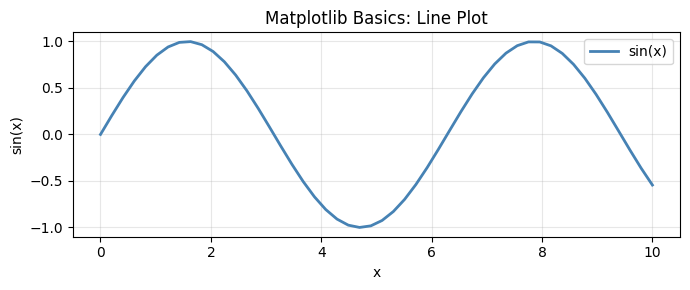

Key objects: Figure > Axes > Artist. Use ax.* methods for full control.


In [24]:
# Data Visualization - Matplotlib basics
try:
    import matplotlib.pyplot as plt, numpy as np

    x = np.linspace(0, 10, 50)
    y = np.sin(x)

    fig, ax = plt.subplots(figsize=(7, 3))
    ax.plot(x, y, color="steelblue", linewidth=2, label="sin(x)")
    ax.set_title("Matplotlib Basics: Line Plot")
    ax.set_xlabel("x"); ax.set_ylabel("sin(x)")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()
    print("Key objects: Figure > Axes > Artist. Use ax.* methods for full control.")
except ImportError:
    x = [0, 1, 2, 3, 4]
    y = [0.0, 0.84, 0.91, 0.14, -0.76]
    for xi, yi in zip(x, y):
        bar = "#" * int((yi + 1) * 10)
        print(f"x={xi}: {bar}")


### Checklist item: Line, bar, histogram, scatter plots

**Approach:**
- Protects representation: choosing the right chart type for the data's shape, whether trend over time, category comparison, distribution, or relationship between two variables, is what makes a plot informative rather than misleading.
- For this checklist item: Choose the plot type to match the data: line for trends, bar for categories, histogram for distributions, scatter for correlations.
- Code walkthrough:
- The paired code cell focuses on **Line, bar, histogram, scatter plots** within **Data Visualization** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also creates a visual check so patterns, outliers, or distributions are easier to inspect, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Data Visualization](https://www.kaggle.com/learn/data-visualization)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Visualization+Line%2C+bar%2C+histogram%2C+scatter+plots+machine+learning+theory)

**Trade-offs:**
- Compared to a table of numbers, any of these chart types trades exact precision for a shape a human can recognize at a glance - the specific chart type you pick determines which shape you actually see.
- The wrong chart type can obscure the very pattern you're trying to show, such as a bar chart for a continuous distribution or a line chart connecting unordered categories implying a trend that doesn't exist, so match the chart type to the question being asked, not habit.

**Practical software engineering use cases:**
- When to use it: Use a scatter plot for the relationship between two continuous variables, a bar chart for comparing discrete categories, and a histogram for a single variable's distribution.
- When not to use it: Don't use a line chart to connect unordered categories - a line implies a trend or continuity between adjacent points that doesn't exist for categories with no natural order.


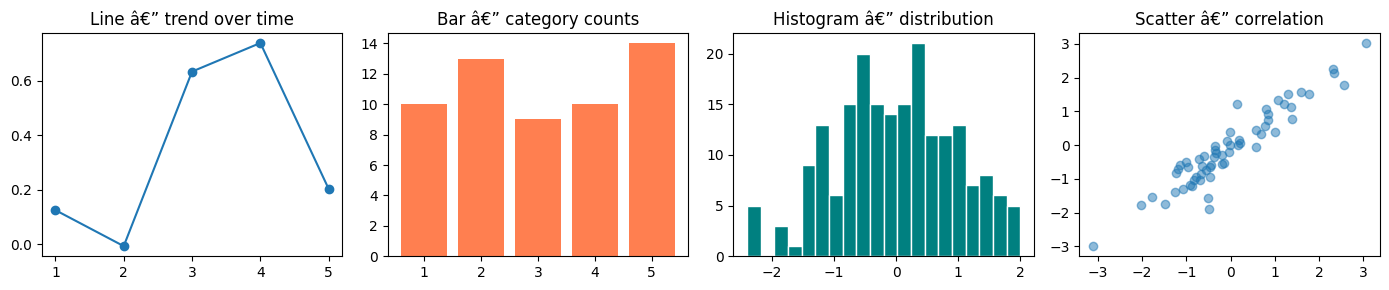

In [25]:
# Data Visualization - Line, bar, histogram, scatter plots
try:
    import matplotlib.pyplot as plt, numpy as np

    rng = np.random.default_rng(0)
    x   = np.arange(1, 6)
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))

    axes[0].plot(x, np.cumsum(rng.standard_normal(5)), marker="o")
    axes[0].set_title("Line â€” trend over time")

    axes[1].bar(x, rng.integers(3, 15, 5), color="coral")
    axes[1].set_title("Bar â€” category counts")

    axes[2].hist(rng.standard_normal(200), bins=20, color="teal", edgecolor="white")
    axes[2].set_title("Histogram â€” distribution")

    sx = rng.standard_normal(60)
    axes[3].scatter(sx, sx * 0.8 + rng.standard_normal(60) * 0.4, alpha=0.5)
    axes[3].set_title("Scatter â€” correlation")

    plt.tight_layout(); plt.show()
except ImportError:
    import random, random as r; r.seed(0)
    vals = [r.gauss(0, 1) for _ in range(40)]
    hist = {}
    for v in vals:
        b = int(v); hist[b] = hist.get(b, 0) + 1
    for k in sorted(hist): print(f"{k:+2d}: {'*'*hist[k]}")


### Checklist item: Correlation heatmaps

**Approach:**
- Protects evaluation integrity: a correlation heatmap surfaces multicollinearity and redundant features at a glance, which is useful before feeding features into a model that assumes independence, like linear regression.
- For this checklist item: Compute a correlation matrix and display it as a heatmap to quickly identify which feature pairs are linearly related.
- Code walkthrough:
- The paired code cell focuses on **Correlation heatmaps** within **Data Visualization** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also creates a visual check so patterns, outliers, or distributions are easier to inspect, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Data Visualization](https://www.kaggle.com/learn/data-visualization)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Visualization+Correlation+heatmaps+machine+learning+theory)

**Trade-offs:**
- Compared to reading a table of pairwise correlation numbers directly, a heatmap trades numeric precision for the ability to instantly spot clusters of highly correlated features by eye.
- Pearson correlation, the usual default, only captures linear relationships, so two features can show near-zero correlation while having a strong nonlinear relationship; don't treat a heatmap as proof of no relationship, only no linear relationship.

**Practical software engineering use cases:**
- When to use it: Use a correlation heatmap as an early step to spot multicollinearity before fitting a linear model.
- When not to use it: Don't use it as your only signal for which features are related - it only reveals linear relationships and will show near-zero correlation for a real but non-linear relationship.


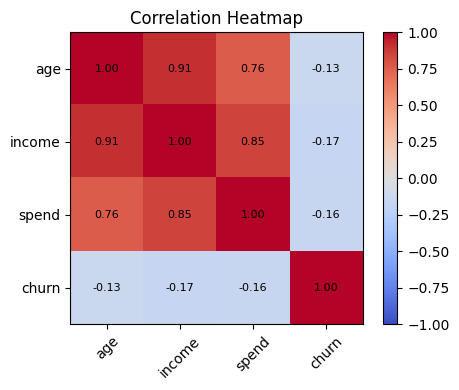

In [26]:
# Data Visualization - Correlation heatmaps
try:
    import matplotlib.pyplot as plt, numpy as np

    rng = np.random.default_rng(0)
    n   = 100
    age    = rng.integers(20, 60, n).astype(float)
    income = age * 1000 + rng.normal(0, 5000, n)
    spend  = income * 0.3 + rng.normal(0, 2000, n)
    churn  = -0.4 * income / income.max() + rng.normal(0, 0.3, n)

    data   = np.column_stack([age, income, spend, churn])
    labels = ["age", "income", "spend", "churn"]
    corr   = np.corrcoef(data.T)

    fig, ax = plt.subplots(figsize=(5, 4))
    im = ax.imshow(corr, vmin=-1, vmax=1, cmap="coolwarm")
    ax.set_xticks(range(4)); ax.set_xticklabels(labels, rotation=45)
    ax.set_yticks(range(4)); ax.set_yticklabels(labels)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{corr[i,j]:.2f}", ha="center", va="center", fontsize=8)
    plt.colorbar(im, ax=ax); ax.set_title("Correlation Heatmap")
    plt.tight_layout(); plt.show()
except ImportError:
    import statistics as s
    age=[25,35,45,55]; spend=[200,350,480,600]
    print("Pearson r(age,spend):", round(s.correlation(age,spend),3))


### Checklist item: Box plots and outlier visualization

**Approach:**
- Protects data quality: box plots make the spread, skew, and outliers of a distribution visible at a glance, which is often faster than scanning summary statistics for the same signal.
- For this checklist item: Box plots show median, IQR, and outliers (whiskers) in one view; compare distributions across groups side-by-side.
- Code walkthrough:
- The paired code cell focuses on **Box plots and outlier visualization** within **Data Visualization** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also creates a visual check so patterns, outliers, or distributions are easier to inspect, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Data Visualization](https://www.kaggle.com/learn/data-visualization)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Visualization+Box+plots+and+outlier+visualization+machine+learning+theory)

**Trade-offs:**
- Compared to a histogram, a box plot sacrifices the shape of the distribution's body for a compact summary of its spread and flagged outliers, which makes it easier to compare across many groups at once.
- The default IQR-based outlier whiskers are a heuristic, not a definition of true outliers; a point flagged by a box plot might be a legitimate rare event, so investigate flagged points before deciding to remove or cap them.

**Practical software engineering use cases:**
- When to use it: Use box plots when you want to compare a numeric variable's spread across several categories side by side, like order value by region.
- When not to use it: Don't treat every point a box plot flags as an outlier as automatically wrong or removable - investigate whether it's a data error or a legitimate rare event first.


C:\Users\Local User\AppData\Local\Temp\ipykernel_22820\725027082.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([a, b], labels=["Group A", "Group B (outliers)"],


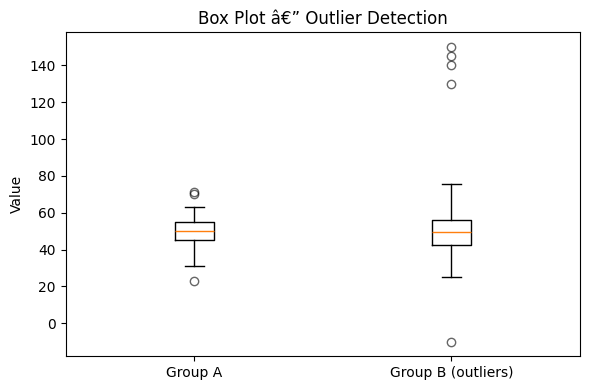

In [27]:
# Data Visualization - Box plots and outlier visualization
try:
    import matplotlib.pyplot as plt, numpy as np

    rng = np.random.default_rng(1)
    a = rng.normal(50, 10, 80)
    b = np.concatenate([rng.normal(50, 10, 75), [130, 145, -10, 150, 140]])

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.boxplot([a, b], labels=["Group A", "Group B (outliers)"],
               flierprops=dict(marker="o", color="red", alpha=0.6))
    ax.set_title("Box Plot â€” Outlier Detection"); ax.set_ylabel("Value")
    plt.tight_layout(); plt.show()
except ImportError:
    values = [10, 12, 11, 13, 14, 99, 10, 12, 11, 105]
    vs = sorted(values); n = len(vs)
    q1, q3 = vs[n//4], vs[3*n//4]; iqr = q3 - q1
    lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr
    print(f"Q1={q1} Q3={q3} IQR={iqr} bounds=[{lo},{hi}]")
    print("Outliers:", [v for v in values if v < lo or v > hi])


### Checklist item: Distribution plots

**Approach:**
- Protects data quality and representation: visualizing a feature's distribution, via histogram or KDE, reveals skew, multimodality, and scale issues that summary statistics like mean and standard deviation can mask.
- For this checklist item: Histogram (density=True) or KDE shows shape, skew, and modality â€” inspect before modeling to choose the right transform.
- Code walkthrough:
- The paired code cell focuses on **Distribution plots** within **Data Visualization** using a small, inspectable example.
- It creates a visual check so patterns, outliers, or distributions are easier to inspect; keep the toy input small so each intermediate value can be checked manually.
- It also uses array operations to show the mathematical operation directly and reproducibly, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Data Visualization](https://www.kaggle.com/learn/data-visualization)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Visualization+Distribution+plots+machine+learning+theory)

**Trade-offs:**
- Compared to a single summary statistic like the mean, a distribution plot trades a compact number for the full shape - revealing skew, multiple modes, or heavy tails that a mean alone would hide entirely.
- Histograms are simple but sensitive to bin width choice, since too few bins hides structure and too many shows noise as structure; KDE smooths this out but can oversmooth small or multimodal samples, so try more than one bin width or bandwidth before concluding a distribution is unimodal.

**Practical software engineering use cases:**
- When to use it: Use a histogram or KDE plot on any new numeric feature before deciding how to scale, transform, or bin it.
- When not to use it: Don't rely on a single default bin width or bandwidth when checking whether a distribution is unimodal - try a couple of settings, since an inappropriate choice can hide or fabricate structure.


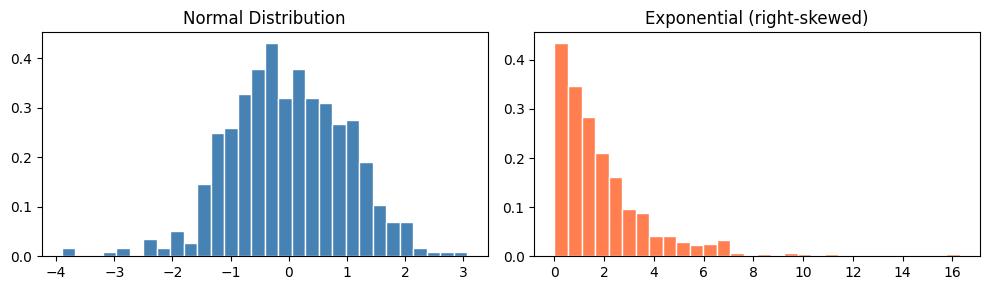

Shape reveals skew, modality, and tail risk before you choose a model.


In [28]:
# Data Visualization - Distribution plots
try:
    import matplotlib.pyplot as plt, numpy as np

    rng    = np.random.default_rng(0)
    normal = rng.normal(0, 1, 500)
    skewed = rng.exponential(scale=2, size=500)

    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    axes[0].hist(normal, bins=30, color="steelblue", edgecolor="white", density=True)
    axes[0].set_title("Normal Distribution")
    axes[1].hist(skewed, bins=30, color="coral",     edgecolor="white", density=True)
    axes[1].set_title("Exponential (right-skewed)")
    plt.tight_layout(); plt.show()
    print("Shape reveals skew, modality, and tail risk before you choose a model.")
except ImportError:
    import statistics, random; random.seed(0)
    vals = [random.gauss(0,1) for _ in range(100)]
    print("mean:", round(statistics.mean(vals),3),
          " stdev:", round(statistics.stdev(vals),3))


### Checklist item: Visual storytelling for analysis

**Approach:**
- Protects user value: a chart built for communication, with clear labels, appropriate scale, and minimal chart junk, is what lets a stakeholder correctly understand a finding without needing to interpret raw numbers themselves.
- For this checklist item: Title each chart with the insight (not just the axis label); arrange panels to tell a cause-and-effect story for stakeholders.
- Code walkthrough:
- The paired code cell focuses on **Visual storytelling for analysis** within **Data Visualization** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also creates a visual check so patterns, outliers, or distributions are easier to inspect, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Kaggle: Data Visualization](https://www.kaggle.com/learn/data-visualization)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Visualization+Visual+storytelling+for+analysis+machine+learning+theory)

**Trade-offs:**
- Compared to a chart built for your own exploration, one built to communicate a finding trades completeness (every caveat and edge case) for clarity (the one thing the audience needs to take away) - a genuinely different design goal.
- Simplifying a chart for a non-technical audience risks oversimplifying and misrepresenting nuance, for example truncated y-axes exaggerating differences, so be deliberate about what's being emphasized and disclose caveats rather than letting the visual overstate certainty.

**Practical software engineering use cases:**
- When to use it: Use a simplified, clearly labeled chart when presenting a finding to a non-technical stakeholder who needs to act on it.
- When not to use it: Don't simplify a chart so much that it visually overstates certainty, like a truncated y-axis exaggerating a small difference - disclose the caveat even in a simplified view.


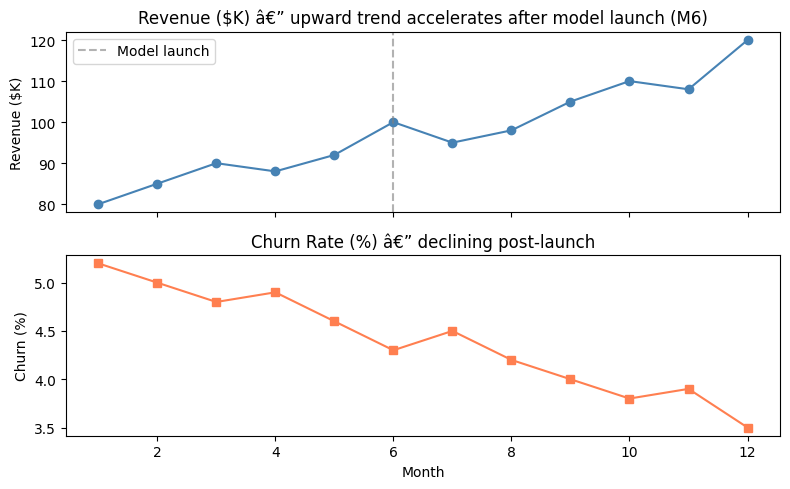

In [29]:
# Data Visualization - Visual storytelling for analysis
try:
    import matplotlib.pyplot as plt, numpy as np

    months  = np.arange(1, 13)
    revenue = np.array([80,85,90,88,92,100,95,98,105,110,108,120])
    churn   = np.array([5.2,5.0,4.8,4.9,4.6,4.3,4.5,4.2,4.0,3.8,3.9,3.5])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True)
    ax1.plot(months, revenue, marker="o", color="steelblue")
    ax1.axvline(6, color="gray", linestyle="--", alpha=0.6, label="Model launch")
    ax1.set_title("Revenue ($K) â€” upward trend accelerates after model launch (M6)")
    ax1.set_ylabel("Revenue ($K)"); ax1.legend()

    ax2.plot(months, churn, marker="s", color="coral")
    ax2.set_title("Churn Rate (%) â€” declining post-launch")
    ax2.set_ylabel("Churn (%)"); ax2.set_xlabel("Month")
    plt.tight_layout(); plt.show()
except ImportError:
    data = list(zip(range(1,7), [80,85,90,88,92,100]))
    for m, r in data: print(f"M{m}: {'#'*(r//5)} ({r}K)")
    print("Tip: chart title = the insight, not just the column name.")


In [30]:
# Practice: Data Visualization

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Statistics for ML

### Study checklist
- [ ] Mean, median, variance, standard deviation
- [ ] Probability basics
- [ ] Distributions
- [ ] Correlation and covariance
- [ ] Hypothesis testing basics
- [ ] Confidence intervals
- [ ] Bias and variance

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Mean, median, variance, standard deviation

**Approach:**
- Protects data quality and evaluation integrity: these are the first checks on any new dataset or model output, and mismatches between mean and median are an immediate signal of skew or outliers worth investigating.
- For this checklist item: Compute mean and variance on training data only; use them to detect skew (mean >> median) and to check feature scaling requirements.
- Code walkthrough:
- The paired code cell focuses on **Mean, median, variance, standard deviation** within **Statistics for ML** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Khan Academy: Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Statistics+for+ML+Mean%2C+median%2C+variance%2C+standard+deviation+machine+learning+theory)

**Trade-offs:**
- Compared to eyeballing a data sample, these four numbers cost almost nothing to compute but immediately flag skew or heavy tails when mean and median disagree.
- Mean and standard deviation are sensitive to outliers, while median and IQR are robust to them, so report both when a distribution might be skewed, since either alone can misrepresent a heavy-tailed feature.

**Practical software engineering use cases:**
- When to use it: Use this quick check as your very first step on any new numeric column, before any modeling.
- When not to use it: Don't rely on mean and standard deviation alone to describe a variable you haven't plotted - a distribution can have a normal-looking mean and std while being badly skewed or multimodal.


In [31]:
# Statistics for ML - Mean, median, variance, standard deviation
import statistics as stats

values = [12, 15, 15, 18, 30]
print("mean:", stats.mean(values))
print("median:", stats.median(values))
print("population variance:", round(stats.pvariance(values), 2))
print("population std:", round(stats.pstdev(values), 2))


mean: 18
median: 15
population variance: 39.6
population std: 6.29


### Checklist item: Probability basics

**Approach:**
- Protects model fit: probabilistic reasoning underlies nearly every ML model's output, such as a classifier's probability of a class or a Bayesian prior, so understanding it is what lets you correctly interpret what a model's output actually means.
- For this checklist item: Model uncertainty as probabilities (P(A), P(A|B)); use Bayes' theorem to update beliefs when new evidence arrives.
- Code walkthrough:
- The paired code cell focuses on **Probability basics** within **Statistics for ML** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Khan Academy: Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Statistics+for+ML+Probability+basics+machine+learning+theory)

**Trade-offs:**
- Compared to a model's raw predicted class label, its predicted probability costs nothing extra to obtain but carries much more information - if you trust its calibration.
- A model's predicted probability is only as trustworthy as its calibration; a well-fit model can still produce poorly calibrated probabilities, so don't treat raw model output as a true probability without checking.

**Practical software engineering use cases:**
- When to use it: Use predicted probabilities, not just hard labels, whenever you need to rank predictions by confidence or set a custom decision threshold.
- When not to use it: Don't treat an uncalibrated model's probability output as a literal, trustworthy likelihood without checking calibration first.


In [32]:
# Statistics for ML - Probability basics
outcomes = {"loss": -10, "break_even": 0, "win": 25}
probabilities = {"loss": 0.20, "break_even": 0.50, "win": 0.30}

expected_value = sum(outcomes[name] * probabilities[name] for name in outcomes)
prob_positive = probabilities["win"]
prob_not_loss = probabilities["break_even"] + probabilities["win"]

print("probabilities sum to:", sum(probabilities.values()))
print("P(positive outcome):", prob_positive)
print("P(not loss):", prob_not_loss)
print("expected value:", expected_value)


probabilities sum to: 1.0
P(positive outcome): 0.3
P(not loss): 0.8
expected value: 5.5


### Checklist item: Distributions

**Approach:**
- Protects model fit and representation: recognizing which distribution a variable roughly follows, such as normal, Poisson, or exponential, tells you which statistical tests, transforms, or model assumptions are appropriate for it.
- For this checklist item: Know Normal (symmetric, meanÂ±std), Binomial (count of successes), and Exponential (time-to-event) â€” each has different ML implications.
- Code walkthrough:
- The paired code cell focuses on **Distributions** within **Statistics for ML** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Khan Academy: Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Statistics+for+ML+Distributions+machine+learning+theory)

**Trade-offs:**
- Compared to assuming a feature is normally distributed by default, checking its actual shape costs one histogram but tells you which statistical tests and transforms are actually valid to use on it.
- Real data rarely matches a textbook distribution exactly, and a formal goodness-of-fit test can be overly strict on large samples, flagging trivial deviations as significant, so combine a visual check like a histogram or QQ-plot with domain judgment rather than relying on a single test's p-value.

**Practical software engineering use cases:**
- When to use it: Use a quick distribution check, like a histogram or QQ-plot, before applying any statistical test or transform that assumes a specific distribution.
- When not to use it: Don't rely on a formal goodness-of-fit test's p-value alone on a large sample - it can flag trivial, practically meaningless deviations as statistically significant.


In [33]:
# Statistics for ML - Distributions
import math

def normal_pdf(x, mean=0, std=1):
    z = (x - mean) / std
    return (1 / (std * math.sqrt(2 * math.pi))) * math.exp(-0.5 * z**2)

print("Normal N(0,1) PDF:")
for x in [0, 1, 2]:
    print(f"  x={x}: {normal_pdf(x):.4f}")

# Verify area â‰ˆ 1 via Riemann sum
area = sum(normal_pdf(x/100) * 0.01 for x in range(-500, 500))
print(f"Area under N(0,1) â‰ˆ {area:.4f}  (should be ~1.0)")

# Binomial: P(k successes in n trials)
def binomial(n, k, p):
    from math import comb
    return comb(n, k) * (p**k) * ((1-p)**(n-k))

print(f"\nBinomial P(k=3 | n=10, p=0.3) = {binomial(10,3,0.3):.4f}")
print("Normal â†’ continuous features; Binomial â†’ binary outcomes; Exponential â†’ wait times.")


Normal N(0,1) PDF:
  x=0: 0.3989
  x=1: 0.2420
  x=2: 0.0540
Area under N(0,1) â‰ˆ 1.0000  (should be ~1.0)

Binomial P(k=3 | n=10, p=0.3) = 0.2668
Normal â†’ continuous features; Binomial â†’ binary outcomes; Exponential â†’ wait times.


### Checklist item: Correlation and covariance

**Approach:**
- Protects model fit and evaluation integrity: these quantify how two variables move together, which is foundational for feature selection, multicollinearity checks, and understanding what a linear model can and can't capture.
- For this checklist item: Compute covariance to see whether two variables move together; normalize covariance into correlation so relationship strength is comparable across feature scales.
- Code walkthrough:
- The paired code cell focuses on **Correlation and covariance** within **Statistics for ML** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Khan Academy: Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Statistics+for+ML+Correlation+and+covariance+machine+learning+theory)

**Trade-offs:**
- Compared to covariance, correlation costs nothing extra to compute but is scale-invariant, making it directly comparable across different variable pairs in a way raw covariance isn't.
- Correlation measures linear association only and is scale-invariant while covariance is not, making covariance hard to compare across variable pairs, and high correlation never implies causation, so don't let a strong correlation drive a causal claim without a controlled experiment.

**Practical software engineering use cases:**
- When to use it: Use correlation for quick, comparable feature-feature and feature-target relationship checks during EDA.
- When not to use it: Don't use a strong correlation as evidence of a causal relationship - without a controlled experiment, correlation alone can't tell you that.


In [34]:
# Statistics for ML - Correlation and covariance
import math

ad_spend = [1, 2, 3, 4, 5]
sales = [2, 4, 5, 4, 6]

mean_x = sum(ad_spend) / len(ad_spend)
mean_y = sum(sales) / len(sales)
covariance = sum((x - mean_x) * (y - mean_y) for x, y in zip(ad_spend, sales)) / len(ad_spend)
std_x = math.sqrt(sum((x - mean_x) ** 2 for x in ad_spend) / len(ad_spend))
std_y = math.sqrt(sum((y - mean_y) ** 2 for y in sales) / len(sales))
correlation = covariance / (std_x * std_y)

print("covariance:", round(covariance, 3))
print("correlation:", round(correlation, 3))


covariance: 1.6
correlation: 0.853


### Checklist item: Hypothesis testing basics

**Approach:**
- Protects evaluation integrity: hypothesis testing gives a formal way to decide whether an observed difference, such as between two model versions or two groups, is likely real or could be explained by chance.
- For this checklist item: State the null and alternative hypotheses, choose a significance level, compute a test statistic or p-value, then reject or fail to reject the null while checking assumptions.
- Code walkthrough:
- The paired code cell focuses on **Hypothesis testing basics** within **Statistics for ML** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Khan Academy: Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Statistics+for+ML+Hypothesis+testing+basics+machine+learning+theory)

**Trade-offs:**
- Compared to just eyeballing whether two numbers look different, a hypothesis test costs some statistical setup but gives you a principled way to say whether an observed difference is likely more than chance.
- Statistical significance, a small p-value, doesn't imply practical significance, a meaningful effect size, especially with large samples where even trivial differences become significant, so always report effect size alongside the p-value.

**Practical software engineering use cases:**
- When to use it: Use a hypothesis test when comparing two model versions' metrics or two groups' behavior and you need to know if the difference is real, not noise.
- When not to use it: Don't treat statistical significance alone as proof a difference matters practically - a tiny, meaningless effect can still be significant with enough data.


In [35]:
# Statistics for ML - Hypothesis testing basics
from itertools import combinations

control = [0.71, 0.69, 0.74, 0.70]
treatment = [0.78, 0.76, 0.80, 0.77]
observed_diff = sum(treatment) / len(treatment) - sum(control) / len(control)

combined = control + treatment
n_treatment = len(treatment)
diffs = []
for idxs in combinations(range(len(combined)), n_treatment):
    idxs = set(idxs)
    pseudo_treatment = [v for i, v in enumerate(combined) if i in idxs]
    pseudo_control = [v for i, v in enumerate(combined) if i not in idxs]
    diffs.append(sum(pseudo_treatment) / n_treatment - sum(pseudo_control) / len(pseudo_control))

p_value = sum(abs(d) >= abs(observed_diff) for d in diffs) / len(diffs)
print("H0: treatment and control have the same mean")
print("observed mean difference:", round(observed_diff, 3))
print("permutation-test p-value:", round(p_value, 3))


H0: treatment and control have the same mean
observed mean difference: 0.068
permutation-test p-value: 0.029


### Checklist item: Confidence intervals

**Approach:**
- Protects evaluation integrity: a confidence interval communicates the uncertainty around an estimate, like a model's accuracy, which a single point estimate hides entirely.
- For this checklist item: Compute confidence intervals on val metrics to know if a 1-point improvement is real or sampling noise before declaring a winner.
- Code walkthrough:
- The paired code cell focuses on **Confidence intervals** within **Statistics for ML** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Khan Academy: Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Statistics+for+ML+Confidence+intervals+machine+learning+theory)

**Trade-offs:**
- Compared to a single point estimate, a confidence interval costs a bit more to compute and communicate but conveys the actual uncertainty behind that estimate.
- A narrower interval feels more precise but usually comes from more data or a lower confidence level, so don't cherry-pick a confidence level after seeing the result; decide it in advance based on how much uncertainty is acceptable for the decision.

**Practical software engineering use cases:**
- When to use it: Use a confidence interval any time you report a metric, like accuracy, that a decision will be based on.
- When not to use it: Don't pick your confidence level after seeing how wide or narrow the resulting interval looks - decide it in advance based on how much uncertainty the decision can tolerate.


In [36]:
# Statistics for ML - Confidence intervals
import math
import statistics as stats

sample = [0.71, 0.69, 0.74, 0.70, 0.72]
mean = stats.mean(sample)
std_error = stats.stdev(sample) / math.sqrt(len(sample))
ci_low = mean - 1.96 * std_error
ci_high = mean + 1.96 * std_error
print("sample mean:", round(mean, 3))
print("approx 95% CI:", (round(ci_low, 3), round(ci_high, 3)))


sample mean: 0.712
approx 95% CI: (0.695, 0.729)


### Checklist item: Bias and variance

**Approach:**
- Protects model fit and evaluation integrity: decomposing error into bias, systematic under-fitting, and variance, sensitivity to training data, is what tells you whether to add model complexity or add regularization and more data when a model underperforms.
- For this checklist item: Compare train and validation error to diagnose underfitting versus overfitting: high train error suggests high bias, while a large validation gap suggests high variance.
- Code walkthrough:
- The paired code cell focuses on **Bias and variance** within **Statistics for ML** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Khan Academy: Statistics and Probability](https://www.khanacademy.org/math/statistics-probability)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Statistics+for+ML+Bias+and+variance+machine+learning+theory)

**Trade-offs:**
- Compared to just looking at a single accuracy number, decomposing error into bias and variance costs comparing train vs. validation performance but tells you which direction, more complexity or more regularization, will actually help.
- Reducing bias with a more complex model typically increases variance and vice versa, so diagnose which one dominates, via the train vs. validation error gap, before choosing a fix; adding complexity to a high-variance model, or regularizing a high-bias model, both make things worse.

**Practical software engineering use cases:**
- When to use it: Use this diagnosis whenever a model's underperforming and you need to decide whether to add complexity or add regularization/data.
- When not to use it: Don't add model complexity to fix underperformance without first checking whether the problem is actually high variance rather than high bias - adding complexity to an already-overfitting model makes it worse.


In [37]:
# Statistics for ML - Bias and variance
models = {
    "too_simple": {"train_error": 0.32, "validation_error": 0.35},
    "balanced": {"train_error": 0.18, "validation_error": 0.20},
    "too_complex": {"train_error": 0.03, "validation_error": 0.28},
}
for name, scores in models.items():
    gap = scores["validation_error"] - scores["train_error"]
    diagnosis = "high bias" if scores["train_error"] > 0.25 else "high variance" if gap > 0.15 else "reasonable fit"
    print(name, scores, diagnosis)


too_simple {'train_error': 0.32, 'validation_error': 0.35} high bias
balanced {'train_error': 0.18, 'validation_error': 0.2} reasonable fit
too_complex {'train_error': 0.03, 'validation_error': 0.28} high variance


In [38]:
# Practice: Statistics for ML

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Linear Algebra for ML

### Study checklist
- [ ] Scalars, vectors, matrices
- [ ] Dot product
- [ ] Matrix multiplication
- [ ] Norms and distance
- [ ] Eigenvalues and eigenvectors concept
- [ ] Why linear algebra matters in ML

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Scalars, vectors, matrices

**Approach:**
- Protects representation: nearly all ML data and parameters are represented as vectors and matrices, so fluency with their shapes and operations is a prerequisite for reading model code or debugging shape errors.
- For this checklist item: A scalar is a single number (learning rate), a vector is one sample's features, a matrix is the full dataset â€” know which shape each operation expects.
- Code walkthrough:
- The paired code cell focuses on **Scalars, vectors, matrices** within **Linear Algebra for ML** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Mathematics for Machine Learning (book)](https://mml-book.github.io/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Linear+Algebra+for+ML+Scalars%2C+vectors%2C+matrices+machine+learning+theory)

**Trade-offs:**
- Compared to a plain Python list, a vector or matrix as a NumPy array costs nothing extra to create but comes with well-defined shape and algebraic operations that a list doesn't have.
- There's no real trade-off in the concept itself, but conflating a vector's shape, for example a 1-D array vs. a column matrix, is a very common and silent source of bugs in NumPy or framework code, so always check the shape explicitly rather than assuming.

**Practical software engineering use cases:**
- When to use it: Use explicit vector/matrix shapes and NumPy arrays whenever your data or parameters have a genuine linear-algebra structure, like a dataset's feature matrix.
- When not to use it: Don't treat a shape mismatch error as a random bug to work around with .reshape() until it runs - trace back why the shapes don't match; the fix is usually a real misunderstanding of the data's structure.


In [39]:
# Linear Algebra for ML - Scalars, vectors, matrices
try:
    import numpy as np

    lr = 0.01                                     # scalar
    print("Scalar (learning rate):", lr)

    features = np.array([1.5, 0.8, -0.3, 2.1])   # vector: one sample
    print("Vector shape:", features.shape, " norm:", round(np.linalg.norm(features),4))

    X = np.array([[1.5, 0.8],                     # matrix: dataset
                  [0.2, 1.3],
                  [-0.5, 0.9]])
    print("Matrix (3 samples x 2 features):\n", X)

    w = np.array([0.6, -0.4])                     # weight vector
    print("Predictions X@w:", (X @ w).round(4))
except ImportError:
    features = [1.5, 0.8, -0.3]
    weights  = [0.6, -0.4, 0.2]
    print("dot:", round(sum(f*w for f,w in zip(features,weights)), 4))


Scalar (learning rate): 0.01
Vector shape: (4,)  norm: 2.7185
Matrix (3 samples x 2 features):
 [[ 1.5  0.8]
 [ 0.2  1.3]
 [-0.5  0.9]]
Predictions X@w: [ 0.58 -0.4  -0.66]


### Checklist item: Dot product

**Approach:**
- Protects representation and model fit: the dot product is the core operation behind a single neuron's weighted sum and behind similarity and distance calculations, so it's the atomic operation nearly everything else in ML builds on.
- For this checklist item: The dot product measures the similarity between two vectors; it is the core computation inside every linear model forward pass.
- Code walkthrough:
- The paired code cell focuses on **Dot product** within **Linear Algebra for ML** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Mathematics for Machine Learning (book)](https://mml-book.github.io/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Linear+Algebra+for+ML+Dot+product+machine+learning+theory)

**Trade-offs:**
- Compared to Euclidean distance, the dot product costs the same to compute but measures a different thing, alignment of direction and magnitude, rather than absolute closeness - the right choice depends on what your problem actually cares about.
- The dot product only measures similarity meaningfully when vectors are on comparable scales or normalized; an unnormalized dot product can be dominated by vector magnitude rather than direction, which is why cosine similarity, a normalized dot product, is often preferred for comparing directions.

**Practical software engineering use cases:**
- When to use it: Use the dot product, or cosine similarity, its normalized form, when comparing the direction of two vectors, like two document embeddings.
- When not to use it: Don't use a raw, unnormalized dot product to compare similarity between vectors of very different magnitudes - normalize first or the magnitude will dominate the result.


In [40]:
import math
# Linear Algebra for ML - Dot product
vector_a = [1, 2, 3]
vector_b = [4, 5, 6]
dot = sum(a * b for a, b in zip(vector_a, vector_b))
norm_a = math.sqrt(sum(a * a for a in vector_a))
print("dot product:", dot)
print("norm:", round(norm_a, 3))


dot product: 32
norm: 3.742


### Checklist item: Matrix multiplication

**Approach:**
- Protects correctness: matrix multiplication is how a whole layer's worth of neurons compute their outputs in one operation, so getting dimension compatibility and multiplication order right is essential to avoid a silent shape-mismatch bug.
- For this checklist item: The forward pass of a linear layer is X @ W: (batch Ã— in_features) @ (in_features Ã— out_features) = (batch Ã— out_features).
- Code walkthrough:
- The paired code cell focuses on **Matrix multiplication** within **Linear Algebra for ML** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Mathematics for Machine Learning (book)](https://mml-book.github.io/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Linear+Algebra+for+ML+Matrix+multiplication+machine+learning+theory)

**Trade-offs:**
- Compared to element-wise multiplication, matrix multiplication costs more compute since each output entry sums over a whole row/column, but is what actually implements a linear transformation, like a neural network layer.
- Matrix multiplication is not commutative in general, and getting the order backward can still run successfully if shapes happen to be compatible, silently computing something different than intended, so verify against a small hand-computed example when in doubt.

**Practical software engineering use cases:**
- When to use it: Use matrix multiplication whenever you need to apply a linear transformation to every row of a dataset at once, like computing a layer's output for a whole batch.
- When not to use it: Don't assume swapping the order of A @ B and B @ A gives the same result - matrix multiplication isn't commutative, and getting the order backward can silently compute something else entirely.


In [41]:
# Linear Algebra for ML - Matrix multiplication
try:
    import numpy as np

    # Forward pass: X (2 samples, 3 features) @ W (3â†’2 weights)
    X = np.array([[1, 2, 3],
                  [4, 5, 6]])
    W = np.array([[0.1, 0.4],
                  [0.2, 0.5],
                  [0.3, 0.6]])
    out = X @ W
    print("X shape:", X.shape, " W shape:", W.shape, " out shape:", out.shape)
    print("X @ W (linear layer output):\n", out)
    print("Rule: (mÃ—n) @ (nÃ—p) = (mÃ—p) â€” inner dimensions must match.")
except ImportError:
    A = [[1,2],[3,4]]; B = [[0,1],[1,0]]
    C = [[sum(A[i][k]*B[k][j] for k in range(2)) for j in range(2)] for i in range(2)]
    print("A@B =", C)


X shape: (2, 3)  W shape: (3, 2)  out shape: (2, 2)
X @ W (linear layer output):
 [[1.4 3.2]
 [3.2 7.7]]
Rule: (mÃ—n) @ (nÃ—p) = (mÃ—p) â€” inner dimensions must match.


### Checklist item: Norms and distance

**Approach:**
- Protects representation and model fit: norms define what distance or magnitude means for a vector, which underlies regularization, KNN, clustering, and gradient magnitude monitoring.
- For this checklist item: L2 norm measures vector magnitude (e.g., weight decay); Euclidean distance is the L2 norm of the difference â€” used in KNN and K-Means.
- Code walkthrough:
- The paired code cell focuses on **Norms and distance** within **Linear Algebra for ML** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Mathematics for Machine Learning (book)](https://mml-book.github.io/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Linear+Algebra+for+ML+Norms+and+distance+machine+learning+theory)

**Trade-offs:**
- Compared to Manhattan distance, Euclidean distance costs the same to compute but is more sensitive to a single large difference in one dimension - the choice should follow from what similar means for your specific features.
- Euclidean distance is the common default but is sensitive to feature scale and outliers; Manhattan distance is more robust to outliers but less common in practice, so the choice should follow from what similar should mean for your specific features, not default habit.

**Practical software engineering use cases:**
- When to use it: Use Euclidean distance as the default for continuous, similarly-scaled features where overall closeness matters.
- When not to use it: Don't use Euclidean distance on features with wildly different scales without normalizing first - the largest-scale feature will dominate the distance regardless of its real importance.


In [42]:
import math
# Linear Algebra for ML - Norms and distance
vector_a = [1, 2, 3]
vector_b = [4, 5, 6]
dot = sum(a * b for a, b in zip(vector_a, vector_b))
norm_a = math.sqrt(sum(a * a for a in vector_a))
print("dot product:", dot)
print("norm:", round(norm_a, 3))


dot product: 32
norm: 3.742


### Checklist item: Eigenvalues and eigenvectors concept

**Approach:**
- Protects representation: eigenvectors identify directions a linear transformation only stretches, not rotates, and eigenvalues quantify that stretch, which is the mathematical basis for PCA's principal components.
- For this checklist item: Eigenvectors of the covariance matrix point in directions of maximum variance â€” PCA uses them to project data onto its most informative axes.
- Code walkthrough:
- The paired code cell focuses on **Eigenvalues and eigenvectors concept** within **Linear Algebra for ML** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also fits a small model or estimator and inspects its predictions on a controlled toy dataset, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Mathematics for Machine Learning (book)](https://mml-book.github.io/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Linear+Algebra+for+ML+Eigenvalues+and+eigenvectors+concept+machine+learning+theory)

**Trade-offs:**
- Compared to memorizing the algebraic definition, connecting eigenvectors to a concrete use like PCA costs more upfront study time but is what actually makes the concept usable rather than just a formula to recite.
- The concept is abstract and easy to memorize without real intuition; connecting it concretely to PCA, where eigenvectors of the covariance matrix are the principal components and eigenvalues are the variance explained, is what makes it useful rather than just a formula.

**Practical software engineering use cases:**
- When to use it: Use this understanding specifically when interpreting what PCA's components represent, or when a model's stability depends on a matrix's eigenvalues.
- When not to use it: Don't expect to need to compute eigenvalues by hand in practice - libraries handle the computation; the value is in understanding what the result means.


In [43]:
# Linear Algebra for ML - Eigenvalues and eigenvectors concept
try:
    import numpy as np

    X = np.array([[2.5,2.4],[0.5,0.7],[2.2,2.9],[1.9,2.2],[3.1,3.0]])
    Xc = X - X.mean(axis=0)
    cov = np.cov(Xc.T)
    print("Covariance matrix:\n", cov.round(4))

    eigenvalues, eigenvectors = np.linalg.eig(cov)
    idx = np.argsort(eigenvalues)[::-1]
    ev, evec = eigenvalues[idx], eigenvectors[:, idx]

    print("\nEigenvalues:", ev.round(4))
    print("Eigenvectors:\n", evec.round(4))
    print(f"\nPC1 explains {ev[0]/ev.sum()*100:.1f}% of variance â€” the first PCA axis.")
except ImportError:
    # 2x2 example: [[2,1],[1,2]] has eigenvalues 3 and 1
    print("For A=[[2,1],[1,2]]: eigenvalues are 3 and 1.")
    print("  Î»=3 eigenvector: [1, 1]  (direction of max variance)")
    print("  Î»=1 eigenvector: [1,-1]  (orthogonal direction)")


Covariance matrix:
 [[0.938  0.8405]
 [0.8405 0.853 ]]

Eigenvalues: [1.7371 0.0539]
Eigenvectors:
 [[ 0.7247 -0.689 ]
 [ 0.689   0.7247]]

PC1 explains 97.0% of variance â€” the first PCA axis.


### Checklist item: Why linear algebra matters in ML

**Approach:**
- Protects deployment reliability and debugging: recognizing that nearly every ML operation, from the forward pass to gradient computation to similarity search, is expressed as vector and matrix operations is what lets you read framework internals and debug shape or performance issues instead of treating them as black boxes.
- For this checklist item: Weight matrices, gradient vectors, and covariance matrices are all linear-algebra objects; operations on them are why NumPy/BLAS is critical for ML speed.
- Code walkthrough:
- The paired code cell focuses on **Why linear algebra matters in ML** within **Linear Algebra for ML** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Mathematics for Machine Learning (book)](https://mml-book.github.io/)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Linear+Algebra+for+ML+Why+linear+algebra+matters+in+ML+machine+learning+theory)

**Trade-offs:**
- Compared to treating an ML framework as a total black box, understanding the underlying linear algebra costs some upfront study but is what lets you actually debug a shape error or a slow operation instead of guessing.
- You don't need to derive every algorithm from first principles to use ML libraries effectively, but skipping linear algebra entirely means shape errors, performance issues, and some hyperparameter choices, like PCA's number of components, will feel like unexplainable magic rather than debuggable math.

**Practical software engineering use cases:**
- When to use it: Use this foundation specifically when debugging a shape mismatch, an unexpectedly slow operation, or a confusing hyperparameter like PCA's component count.
- When not to use it: Don't feel you need to re-derive every algorithm from its linear algebra before using an ML library productively - day-to-day usage doesn't require that depth, only debugging does.


In [44]:
import math
# Linear Algebra for ML - Why linear algebra matters in ML
vector_a = [1, 2, 3]
vector_b = [4, 5, 6]
dot = sum(a * b for a, b in zip(vector_a, vector_b))
norm_a = math.sqrt(sum(a * a for a in vector_a))
print("dot product:", dot)
print("norm:", round(norm_a, 3))


dot product: 32
norm: 3.742


In [45]:
# Practice: Linear Algebra for ML

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Calculus and Optimization Basics

### Study checklist
- [ ] Derivative intuition
- [ ] Gradient
- [ ] Loss function
- [ ] Gradient descent
- [ ] Learning rate
- [ ] Local vs global minima

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Derivative intuition

**Approach:**
- Protects trainability: a derivative measures how a function's output changes with a small change in input, which is the basic quantity that tells an optimizer which direction reduces the loss.
- For this checklist item: Estimate how the loss changes when a single weight moves slightly; the derivative is the local slope that tells whether increasing the weight raises or lowers loss.
- Code walkthrough:
- The paired code cell focuses on **Derivative intuition** within **Calculus and Optimization Basics** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Gradient Descent](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Calculus+and+Optimization+Basics+Derivative+intuition+machine+learning+theory)

**Trade-offs:**
- Compared to evaluating a function at two nearby points and comparing outputs by hand, a derivative gives the exact instantaneous rate of change - the same intuition, but precise and usable by an optimizer.
- Understanding derivatives conceptually is essential for debugging training, for example recognizing a vanishing gradient, but computing them by hand is only practical for small toy functions; real models rely on automatic differentiation, not manual calculus.

**Practical software engineering use cases:**
- When to use it: Use derivative intuition to understand why training might stall (near-zero gradient) or explode (very large gradient).
- When not to use it: Don't attempt to compute derivatives by hand for any real model's loss function - rely on the framework's automatic differentiation entirely.


In [ ]:
# Calculus and Optimization Basics - Derivative intuition
def loss(weight):
    return (weight - 3) ** 2

for weight in [0, 2.5, 3.0, 4.0]:
    epsilon = 0.001
    numerical_slope = (loss(weight + epsilon) - loss(weight)) / epsilon
    exact_derivative = 2 * (weight - 3)
    print(f"w={weight:>3}: numerical_slope={numerical_slope:.3f}, derivative={exact_derivative:.3f}")


### Checklist item: Gradient

**Approach:**
- Protects trainability: the gradient generalizes the derivative to multiple parameters, giving the direction of steepest increase of the loss, so negating it is literally what gradient descent descends along.
- For this checklist item: For multiple parameters, compute one partial derivative per parameter; the gradient vector points in the steepest direction of loss increase.
- Code walkthrough:
- The paired code cell focuses on **Gradient** within **Calculus and Optimization Basics** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Gradient Descent](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Calculus+and+Optimization+Basics+Gradient+machine+learning+theory)

**Trade-offs:**
- Compared to a single-variable derivative, the gradient generalizes to many parameters at once - the same which-direction-reduces-the-loss question, just answered simultaneously for every weight in the model.
- The gradient only gives a local direction, not a global one; following it reliably improves the loss for a small step but says nothing about the shape of the loss surface further away, which is why step size, the learning rate, matters so much.

**Practical software engineering use cases:**
- When to use it: Use gradient-based reasoning to understand why an optimizer moves parameters the way it does at each step.
- When not to use it: Don't expect the gradient at a single point to tell you anything about the loss surface far away from that point - it's a strictly local signal.


In [ ]:
# Calculus and Optimization Basics - Gradient
points = [(1, 2), (2, 4), (3, 6)]
w, b = 0.5, 0.0

errors = [(w * x + b) - y for x, y in points]
grad_w = sum(2 * error * x for error, (x, _) in zip(errors, points)) / len(points)
grad_b = sum(2 * error for error in errors) / len(points)

print("gradient vector:", {"d_loss/d_w": round(grad_w, 3), "d_loss/d_b": round(grad_b, 3)})
print("move opposite the gradient to reduce loss")


### Checklist item: Loss function

**Approach:**
- Protects evaluation integrity and model fit: the loss function is literally the objective the optimizer minimizes, so choosing the wrong one for the task, such as MSE for a classification problem, optimizes for the wrong outcome even with a perfect model architecture.
- For this checklist item: Define a scalar objective that measures prediction error, then compare candidate parameters by which one produces lower loss.
- Code walkthrough:
- The paired code cell focuses on **Loss function** within **Calculus and Optimization Basics** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Gradient Descent](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Calculus+and+Optimization+Basics+Loss+function+machine+learning+theory)

**Trade-offs:**
- Compared to picking an evaluation metric, picking a loss function has an extra constraint: it must be differentiable for gradient-based training to work, which a business metric like revenue often isn't directly.
- The loss used for training and the metric used to judge success don't need to match, since loss needs to be differentiable while business metrics often aren't, but if they diverge too much, you risk optimizing a proxy that stops tracking what you actually care about.

**Practical software engineering use cases:**
- When to use it: Use a standard differentiable loss, like cross-entropy or MSE, that's a reasonable proxy for your real objective, and reserve the true business metric for evaluation.
- When not to use it: Don't assume optimizing the loss automatically optimizes the metric you actually care about - check periodically that the two are still moving together as training progresses.


In [ ]:
# Calculus and Optimization Basics - Loss function
actual = [3, 5, 7]
candidate_predictions = {
    "model_a": [2, 5, 8],
    "model_b": [3, 4, 6],
    "model_c": [3, 5, 7],
}

def mse(predicted, actual):
    return sum((p - a) ** 2 for p, a in zip(predicted, actual)) / len(actual)

for name, predicted in candidate_predictions.items():
    print(name, "MSE=", round(mse(predicted, actual), 3))


### Checklist item: Gradient descent

**Approach:**
- Protects trainability: gradient descent is the core algorithm behind training almost every ML model with continuous parameters, iteratively nudging parameters in the direction that reduces loss.
- For this checklist item: Repeatedly compute the gradient and move parameters in the opposite direction so the loss decreases step by step.
- Code walkthrough:
- The paired code cell focuses on **Gradient descent** within **Calculus and Optimization Basics** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Gradient Descent](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Calculus+and+Optimization+Basics+Gradient+descent+machine+learning+theory)

**Trade-offs:**
- Compared to a closed-form solution, like plain linear regression's normal equation, gradient descent costs an iterative process but is what makes training feasible for models with no closed-form solution, like neural networks.
- Batch gradient descent, using the full dataset per step, gives a stable but slow update; stochastic or mini-batch variants update faster and can escape shallow local minima due to noise, but that same noise makes convergence less smooth, so the practical default of mini-batch balances the two.

**Practical software engineering use cases:**
- When to use it: Use mini-batch gradient descent as the practical default for training any model without a closed-form solution.
- When not to use it: Don't use full-batch gradient descent on a large dataset expecting fast iteration - each step requires a full pass over the data, which doesn't scale the way mini-batches do.


In [ ]:
# Calculus and Optimization Basics - Gradient descent
def loss(weight):
    return (weight - 3) ** 2

weight = 0.0
learning_rate = 0.2
for step in range(6):
    gradient = 2 * (weight - 3)
    print(f"step={step} weight={weight:.3f} loss={loss(weight):.3f} gradient={gradient:.3f}")
    weight -= learning_rate * gradient


### Checklist item: Learning rate

**Approach:**
- Protects trainability: the learning rate scales how big a step gradient descent takes, and it is often the single hyperparameter most responsible for whether training converges at all.
- For this checklist item: Compare step sizes: too small learns slowly, a good rate converges quickly, and too large can overshoot or diverge.
- Code walkthrough:
- The paired code cell focuses on **Learning rate** within **Calculus and Optimization Basics** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Gradient Descent](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Calculus+and+Optimization+Basics+Learning+rate+machine+learning+theory)

**Trade-offs:**
- Compared to leaving an optimizer's other settings at their defaults, the learning rate is the one hyperparameter most likely to single-handedly determine whether training converges at all.
- Too high a learning rate causes the loss to diverge or oscillate; too low makes training impractically slow and prone to getting stuck, so use a learning rate schedule or an adaptive optimizer like Adam rather than guessing a single fixed value.

**Practical software engineering use cases:**
- When to use it: Use a learning rate schedule or an adaptive optimizer like Adam rather than guessing a single fixed value from scratch.
- When not to use it: Don't leave a manually-chosen learning rate unchanged across very different model sizes or datasets - what works for one setup can cause divergence or painfully slow convergence on another.


In [ ]:
# Calculus and Optimization Basics - Learning rate
def loss(weight):
    return (weight - 3) ** 2

for learning_rate in [0.05, 0.2, 1.1]:
    weight = 0.0
    losses = []
    for _ in range(5):
        gradient = 2 * (weight - 3)
        weight -= learning_rate * gradient
        losses.append(round(loss(weight), 3))
    print(f"lr={learning_rate}: final_weight={weight:.3f}, losses={losses}")


### Checklist item: Local vs global minima

**Approach:**
- Protects evaluation integrity: knowing that gradient descent only guarantees convergence to a minimum, not necessarily the global one, is what tells you not to over-trust a single training run's final loss as the best possible.
- For this checklist item: On non-convex losses, different starting points can converge to different minima; inspect final losses to distinguish local from global solutions.
- Code walkthrough:
- The paired code cell focuses on **Local vs global minima** within **Calculus and Optimization Basics** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Gradient Descent](https://developers.google.com/machine-learning/crash-course/linear-regression/gradient-descent)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Calculus+and+Optimization+Basics+Local+vs+global+minima+machine+learning+theory)

**Trade-offs:**
- Compared to a simple convex loss surface, like plain linear regression's, a deep network's loss surface has many local minima and saddle points - a genuinely different optimization landscape that the same intuitions don't transfer to cleanly.
- In high-dimensional deep learning, poor local minima are less of a practical problem than saddle points and flat regions turn out to be; techniques like momentum, restarts with different initializations, and appropriate learning rates address this better than trying to avoid local minima directly.

**Practical software engineering use cases:**
- When to use it: Use this awareness specifically when a training run converges to a disappointing loss - consider re-running with a different initialization or momentum rather than assuming the model has hit its true ceiling.
- When not to use it: Don't assume a single training run's final loss represents the best the model could ever achieve - different initializations or optimizer settings can converge to meaningfully different results.


In [ ]:
# Calculus and Optimization Basics - Local vs global minima
def loss(weight):
    return (weight ** 2 - 1) ** 2 + 0.2 * weight

def gradient(weight):
    return 4 * weight * (weight ** 2 - 1) + 0.2

for start in [-1.5, 0.2, 1.5]:
    weight = start
    for _ in range(40):
        weight -= 0.05 * gradient(weight)
    print(f"start={start:>4}: final_weight={weight:.3f}, final_loss={loss(weight):.3f}")


In [52]:
# Practice: Calculus and Optimization Basics

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



# Core Machine Learning Workflow

## ML Workflow

### Study checklist
- [ ] Define business / prediction problem
- [ ] Identify target variable
- [ ] Collect and inspect data
- [ ] Split data correctly
- [ ] Train baseline model
- [ ] Evaluate model
- [ ] Improve and iterate
- [ ] Document results

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Define business / prediction problem

**Approach:**
- Protects user value: translating a business goal into a specific, measurable prediction task is what determines everything downstream, since the wrong problem framing means even a perfect model won't be useful.
- For this checklist item: Frame the prediction task as a decision: who decides what, when, using the model output â€” before touching any data.
- Code walkthrough:
- The paired code cell focuses on **Define business / prediction problem** within **ML Workflow** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Define+business+%2F+prediction+problem+machine+learning+theory)

**Trade-offs:**
- Compared to jumping straight into modeling, spending time upfront to define the exact decision the prediction will drive costs a planning conversation but prevents building a technically impressive model nobody can actually use.
- A precisely scoped problem is easier to model and evaluate but risks being too narrow to matter to the business; a broad problem matters more but is harder to define success for, so resolve this by writing down the specific decision the prediction will drive before starting to model.

**Practical software engineering use cases:**
- When to use it: Use this step before writing a single line of data-loading code, on every new ML project.
- When not to use it: Don't skip straight to let's-predict-X without confirming who will act on that prediction and how - a model with no clear consumer is wasted effort regardless of accuracy.


In [53]:
# ML Workflow - Define business / prediction problem
problem = {
    "business_question": "Which customers are likely to churn in the next 30 days?",
    "prediction_task":   "binary classification",
    "positive_class":    "will churn",
    "prediction_horizon":"30 days ahead of inference date",
    "decision_use_case": "trigger retention offer if P(churn) > 0.60",
    "success_criteria":  "recall >= 70% at < 20% false positive rate",
}
for k, v in problem.items():
    print(f"{k:25s}: {v}")
print("\nKey discipline: define the decision BEFORE choosing an algorithm or metric.")


business_question        : Which customers are likely to churn in the next 30 days?
prediction_task          : binary classification
positive_class           : will churn
prediction_horizon       : 30 days ahead of inference date
decision_use_case        : trigger retention offer if P(churn) > 0.60
success_criteria         : recall >= 70% at < 20% false positive rate

Key discipline: define the decision BEFORE choosing an algorithm or metric.


### Checklist item: Identify target variable

**Approach:**
- Protects data quality and evaluation integrity: the target variable operationalizes the business problem into something a model can be trained and scored against, so a poorly chosen target, a proxy that doesn't match the real goal, silently optimizes the wrong thing.
- For this checklist item: Identify the column the model must predict; check its type, class balance, and whether it can be observed at training time without leakage.
- Code walkthrough:
- The paired code cell focuses on **Identify target variable** within **ML Workflow** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Identify+target+variable+machine+learning+theory)

**Trade-offs:**
- Compared to using an available but generic label, choosing or engineering a specific proxy target costs extra thought but ensures you're optimizing for something that actually reflects the business outcome you care about.
- The ideal target is often unmeasured or delayed, such as long-term customer value, so real projects use a proxy target, like 30-day retention; the trade-off is between a target you can actually measure now and one that truly represents the business outcome you care about.

**Practical software engineering use cases:**
- When to use it: Use a clearly defined proxy target when the true outcome you care about is delayed or unmeasured, like using 30-day retention to stand in for long-term customer value.
- When not to use it: Don't default to whatever target column happens to already exist in your data without checking it actually represents the outcome you want to predict.


In [54]:
# ML Workflow - Identify target variable
records = [
    {"user_id": 1, "days_since_login": 45, "plan": "free",  "cancelled": 1},
    {"user_id": 2, "days_since_login":  2, "plan": "paid",  "cancelled": 0},
    {"user_id": 3, "days_since_login": 30, "plan": "free",  "cancelled": 1},
    {"user_id": 4, "days_since_login":  5, "plan": "paid",  "cancelled": 0},
    {"user_id": 5, "days_since_login": 60, "plan": "free",  "cancelled": 1},
]
target_col  = "cancelled"
feature_cols = [k for k in records[0] if k not in ("user_id", target_col)]
labels = [r[target_col] for r in records]
pos = sum(labels)
print("Target         :", target_col)
print("Features       :", feature_cols)
print(f"Class balance  : {pos} pos / {len(labels)-pos} neg")
print(f"Majority-class baseline: {max(pos, len(labels)-pos)/len(labels):.0%}")


Target         : cancelled
Features       : ['days_since_login', 'plan']
Class balance  : 3 pos / 2 neg
Majority-class baseline: 60%


### Checklist item: Collect and inspect data

**Approach:**
- Protects data quality: inspecting data before modeling, covering schema, ranges, missingness, and class balance, is what catches collection bugs and unusable data before wasted modeling effort, not after.
- For this checklist item: Load a sample, print shape and dtypes, count missing values, and look at a few rows before writing any feature code.
- Code walkthrough:
- The paired code cell focuses on **Collect and inspect data** within **ML Workflow** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Collect+and+inspect+data+machine+learning+theory)

**Trade-offs:**
- Compared to jumping straight to feature engineering, inspecting the raw data first costs some upfront time but catches collection bugs before they get baked into every downstream feature.
- Thorough inspection takes real time upfront and can feel like it delays real modeling work, but skipping it routinely costs far more time later debugging a model that's actually failing because of a data problem, not a modeling one.

**Practical software engineering use cases:**
- When to use it: Use a structured inspection pass (schema, ranges, missingness, class balance) on any new dataset before writing a single feature transform.
- When not to use it: Don't skip inspection because the data came from a trusted source - pipeline bugs and schema drift happen even in well-maintained systems.


In [55]:
# ML Workflow - Collect and inspect data
records = [
    {"age": 25, "income": 45000, "clicked": 1},
    {"age": 32, "income": None,  "clicked": 0},
    {"age": 19, "income": 22000, "clicked": 1},
    {"age": 45, "income": 80000, "clicked": 0},
    {"age": 28, "income": 51000, "clicked": 1},
]
print(f"Rows: {len(records)}  Cols: {list(records[0].keys())}")

for col in records[0]:
    n_miss = sum(1 for r in records if r[col] is None)
    print(f"  {col}: {n_miss} missing ({n_miss/len(records):.0%})")

for col in ("age", "income"):
    vals = [r[col] for r in records if r[col] is not None]
    print(f"\n{col}: min={min(vals)} max={max(vals)} mean={sum(vals)/len(vals):.0f}")

print("\nFirst 2 rows:"); [print(" ", r) for r in records[:2]]


Rows: 5  Cols: ['age', 'income', 'clicked']
  age: 0 missing (0%)
  income: 1 missing (20%)
  clicked: 0 missing (0%)

age: min=19 max=45 mean=30

income: min=22000 max=80000 mean=49500

First 2 rows:
  {'age': 25, 'income': 45000, 'clicked': 1}
  {'age': 32, 'income': None, 'clicked': 0}


[None, None]

### Checklist item: Split data correctly

**Approach:**
- Protects evaluation integrity: the way data is split, whether random, stratified, or time-based, determines whether your evaluation metric reflects how the model will actually perform in production or is silently optimistic due to leakage.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Split data correctly** within **ML Workflow** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Split+data+correctly+machine+learning+theory)

**Trade-offs:**
- Compared to choosing the split strategy after the model is already trained, deciding it upfront based on your data's actual dependency structure costs a moment of thought but prevents an entire evaluation from being invalid.
- A random split is simple and works for i.i.d. data, but for time series or grouped data, such as multiple rows per customer, it leaks future or related information into training, so always match the split strategy to the data's actual dependency structure.

**Practical software engineering use cases:**
- When to use it: Use a split strategy that matches your data's real structure - chronological for time series, grouped for repeated entities, random only for genuinely independent rows.
- When not to use it: Don't default to a random split without checking whether rows are actually independent - the wrong split silently produces an overly optimistic metric.


In [56]:
# ML Workflow - Split data correctly
rows = [
    {"id": 1, "month": "Jan", "target": 0},
    {"id": 2, "month": "Feb", "target": 1},
    {"id": 3, "month": "Mar", "target": 0},
    {"id": 4, "month": "Apr", "target": 1},
    {"id": 5, "month": "May", "target": 0},
]
train = rows[:3]
validation = rows[3:4]
test = rows[4:]
print("train ids:", [row["id"] for row in train])
print("validation ids:", [row["id"] for row in validation])
print("test ids:", [row["id"] for row in test])
print("fit preprocessing on train only, then apply it to validation/test")


train ids: [1, 2, 3]
validation ids: [4]
test ids: [5]
fit preprocessing on train only, then apply it to validation/test


### Checklist item: Train baseline model

**Approach:**
- Protects evaluation integrity: a simple baseline, such as majority class, mean prediction, or a basic linear model, establishes the floor any more complex model must clear, and without it you can't tell if added complexity is actually helping.
- For this checklist item: Build the simplest reasonable model first, measure it honestly, and only accept more complex models that beat it on the right validation metric.
- Code walkthrough:
- The paired code cell focuses on **Train baseline model** within **ML Workflow** using a small, inspectable example.
- It computes diagnostic metrics so you can compare model behavior against the goal of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Train+baseline+model+machine+learning+theory)

**Trade-offs:**
- Compared to jumping straight to a sophisticated model, a baseline costs a small amount of extra time upfront but establishes the floor any complex model needs to clear to justify its added complexity.
- Skipping the baseline to jump straight to a complex model saves a little time upfront, but risks investing significant tuning effort in a sophisticated model that turns out to barely beat always predicting the mean; a baseline is cheap insurance against wasted complexity.

**Practical software engineering use cases:**
- When to use it: Use a simple, fast baseline (majority class, mean prediction, or a plain linear model) as the very first model on every new problem.
- When not to use it: Don't skip the baseline because you already know a complex model will do better - that assumption is exactly what a baseline is meant to test.


In [57]:
# ML Workflow - Train baseline model
train_targets = [100, 120, 110, 130]
baseline_prediction = sum(train_targets) / len(train_targets)
validation_targets = [115, 125]
mae = sum(abs(baseline_prediction - y) for y in validation_targets) / len(validation_targets)
print("baseline prediction:", baseline_prediction)
print("validation MAE:", mae)


baseline prediction: 115.0
validation MAE: 5.0


### Checklist item: Evaluate model

**Approach:**
- Protects evaluation integrity: evaluating on truly held-out data with metrics matched to the business problem is what tells you whether the model is actually good, as opposed to just fitting the training data well.
- For this checklist item: Compute the metric that reflects the business cost of mistakes â€” then inspect per-class errors, not just aggregate accuracy.
- Code walkthrough:
- The paired code cell focuses on **Evaluate model** within **ML Workflow** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Evaluate+model+machine+learning+theory)

**Trade-offs:**
- Compared to reporting a single aggregate metric, a more thorough evaluation, using multiple metrics and subgroup analysis, costs more time to run but catches failures that a single number can hide.
- More rigorous evaluation, using multiple metrics, cross-validation, and subgroup analysis, takes more time and compute than a single train/test accuracy number, but a single aggregate metric can hide critical failures, such as poor performance on a minority subgroup, that only more thorough evaluation surfaces.

**Practical software engineering use cases:**
- When to use it: Use multiple metrics and at least a basic subgroup check on any model before it's promoted past experimentation.
- When not to use it: Don't rely on one aggregate metric like overall accuracy to declare a model good - a strong average can hide a model that fails badly on an important minority subgroup.


In [58]:
# ML Workflow - Evaluate model
actual    = [1, 0, 1, 1, 0, 0, 1, 0]
predicted = [1, 0, 0, 1, 0, 1, 1, 0]

tp = sum(a==1 and p==1 for a,p in zip(actual,predicted))
fp = sum(a==0 and p==1 for a,p in zip(actual,predicted))
fn = sum(a==1 and p==0 for a,p in zip(actual,predicted))
tn = sum(a==0 and p==0 for a,p in zip(actual,predicted))

accuracy  = (tp+tn)/len(actual)
precision = tp/(tp+fp) if (tp+fp)>0 else 0
recall    = tp/(tp+fn) if (tp+fn)>0 else 0
f1 = 2*precision*recall/(precision+recall) if (precision+recall)>0 else 0

print(f"TP={tp} FP={fp} FN={fn} TN={tn}")
print(f"Accuracy : {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1       : {f1:.2f}")


TP=3 FP=1 FN=1 TN=3
Accuracy : 0.75
Precision: 0.75
Recall   : 0.75
F1       : 0.75


### Checklist item: Improve and iterate

**Approach:**
- Protects model fit and process discipline: iterating based on evaluation results, not intuition, is what turns model development into a directed search rather than random trial and error.
- For this checklist item: After each iteration, record what changed, compare val metrics, and decide whether to change features, the model, or the threshold.
- Code walkthrough:
- The paired code cell focuses on **Improve and iterate** within **ML Workflow** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Improve+and+iterate+machine+learning+theory)

**Trade-offs:**
- Compared to a single training run, iterating based on evaluation feedback costs more overall time but turns model development into a directed search instead of a single guess.
- Rapid iteration, trying many ideas quickly, can find improvements fast but risks overfitting to the validation set if you evaluate against it too many times, so reserve a final untouched test set and track how many times you've peeked at validation results.

**Practical software engineering use cases:**
- When to use it: Use evaluation results to guide each next iteration, and keep a log of what you tried and why.
- When not to use it: Don't repeatedly tune against the same validation set without limit - that repeated peeking can itself cause the reported validation performance to overstate real generalization.


In [59]:
# ML Workflow - Improve and iterate
actual = [1, 0, 1, 1, 0, 0, 1, 0]

experiments = [
    ("v0: majority-class baseline",    [0,0,0,0,0,0,0,0]),
    ("v1: logistic regression",        [1,0,0,1,0,1,1,0]),
    ("v2: + inactivity feature",       [1,0,1,1,0,0,1,0]),
    ("v3: threshold tuned to 0.40",    [1,0,1,1,0,0,1,0]),
]

print(f"{'Model':<38}  {'Accuracy':>8}")
print("-" * 50)
for name, preds in experiments:
    acc = sum(a==p for a,p in zip(actual,preds))/len(actual)
    print(f"{name:<38}  {acc:>8.2f}")


Model                                   Accuracy
--------------------------------------------------
v0: majority-class baseline                 0.50
v1: logistic regression                     0.75
v2: + inactivity feature                    1.00
v3: threshold tuned to 0.40                 1.00


### Checklist item: Document results

**Approach:**
- Protects reproducibility and user value: documenting what was tried, what worked, what didn't, and why is what lets someone else, or future you, understand and trust the model's development history instead of treating it as a black box.
- For this checklist item: Store hyperparameters, metric values, feature list, and next steps in a structured dict so experiments are reproducible and comparable.
- Code walkthrough:
- The paired code cell focuses on **Document results** within **ML Workflow** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [Google: Introduction to ML Problem Framing](https://developers.google.com/machine-learning/problem-framing)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=ML+Workflow+Document+results+machine+learning+theory)

**Trade-offs:**
- Compared to moving straight on to the next experiment, writing down what you tried and why costs a few extra minutes but is what makes the project's history reconstructable later, by you or a teammate.
- Documentation takes time away from further modeling, but skipping it means knowledge about failed approaches and key decisions is lost the moment the person who tried them moves on, so write down negative results too, not just the final model's specs.

**Practical software engineering use cases:**
- When to use it: Use a running log or model card documenting what was tried, what worked, and why, for every non-trivial project.
- When not to use it: Don't document only the final, successful approach - the failed attempts and why they didn't work are often just as valuable for the next person, or future you.


In [60]:
# ML Workflow - Document results
results = {
    "model":          "LogisticRegression",
    "features":       ["age", "income", "days_since_login"],
    "train_accuracy": 0.84,
    "val_accuracy":   0.81,
    "test_accuracy":  0.80,
    "precision":      0.78,
    "recall":         0.74,
    "f1":             0.76,
    "notes":          "Threshold=0.45 improves recall; income has highest coefficient.",
    "next_steps":     "Try GradientBoosting; collect 2 more months for retraining.",
}
print("=" * 50)
print("EXPERIMENT RESULTS")
print("=" * 50)
for k, v in results.items():
    print(f"  {k:<20}: {v}")


EXPERIMENT RESULTS
  model               : LogisticRegression
  features            : ['age', 'income', 'days_since_login']
  train_accuracy      : 0.84
  val_accuracy        : 0.81
  test_accuracy       : 0.8
  precision           : 0.78
  recall              : 0.74
  f1                  : 0.76
  notes               : Threshold=0.45 improves recall; income has highest coefficient.
  next_steps          : Try GradientBoosting; collect 2 more months for retraining.


In [61]:
# Practice: ML Workflow

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Data Cleaning

### Study checklist
- [ ] Missing values
- [ ] Duplicate rows
- [ ] Incorrect data types
- [ ] Outliers
- [ ] Inconsistent categories
- [ ] Data leakage checks

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Missing values

**Approach:**
- Protects data quality: deciding how to handle missing values, whether dropping, imputing, or flagging, shapes what the model learns to expect, and doing it inconsistently between train and serving is a classic train/serve skew bug.
- For this checklist item: Detect missing values per column; choose imputation strategy (mean, median, forward-fill, model-based) based on missingness mechanism.
- Code walkthrough:
- The paired code cell focuses on **Missing values** within **Data Cleaning** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [pandas: Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Cleaning+Missing+values+machine+learning+theory)

**Trade-offs:**
- Compared to leaving missing values as-is and letting a downstream step error out, deciding a handling strategy upfront costs a design decision but keeps the failure from surfacing confusingly deep in a pipeline.
- Dropping rows is simple but can bias remaining data if missingness isn't random, for example high earners skipping an income field; imputation preserves sample size but can mask a signal if the missingness itself is informative, so check whether missingness correlates with the target before choosing.

**Practical software engineering use cases:**
- When to use it: Use an explicit, documented strategy for missing values as a named pipeline step, chosen based on whether the missingness itself carries signal.
- When not to use it: Don't fill every missing value with the same default, like 0, without checking whether that value could be confused with a legitimate observed value.


In [62]:
# Data Cleaning - Missing values
values = [10, None, 30, None, 50]
observed = [value for value in values if value is not None]
fill_value = sum(observed) / len(observed)
cleaned = [fill_value if value is None else value for value in values]
print("fill value:", fill_value)
print("cleaned:", cleaned)


fill value: 30.0
cleaned: [10, 30.0, 30, 30.0, 50]


### Checklist item: Duplicate rows

**Approach:**
- Protects data quality and evaluation integrity: duplicate rows can silently inflate a class's apparent frequency or, worse, place the same row in both train and test after a split, leaking information and inflating reported performance.
- For this checklist item: Detect duplicate rows using a set of tuples; decide whether to keep first, last, or drop all duplicates based on the data contract.
- Code walkthrough:
- The paired code cell focuses on **Duplicate rows** within **Data Cleaning** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [pandas: Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Cleaning+Duplicate+rows+machine+learning+theory)

**Trade-offs:**
- Compared to a straightforward exact-match deduplication, catching near-duplicates, like the same record with a typo fixed, costs more effort to detect but closes the same leakage risk that exact duplicates create.
- Deduplicating is usually safe and cheap, but duplicate isn't always exact; near-duplicates, such as the same customer with a corrected typo, can hide the same leakage risk as exact duplicates, so check for near-duplicates too, not just identical rows.

**Practical software engineering use cases:**
- When to use it: Use exact deduplication as a standard step early in any pipeline, and add near-duplicate detection specifically when you suspect manual data entry.
- When not to use it: Don't assume a dataset has no duplicates just because an exact-match check returns nothing - check for near-duplicates too if the data is manually entered.


In [63]:
# Data Cleaning - Duplicate rows
records = [
    {"user_id": 1, "event": "click", "ts": "2024-01-01"},
    {"user_id": 2, "event": "view",  "ts": "2024-01-01"},
    {"user_id": 1, "event": "click", "ts": "2024-01-01"},  # duplicate
    {"user_id": 3, "event": "click", "ts": "2024-01-02"},
    {"user_id": 2, "event": "view",  "ts": "2024-01-01"},  # duplicate
]
print(f"Before: {len(records)} rows")
seen, deduped = set(), []
for r in records:
    key = tuple(sorted(r.items()))
    if key not in seen:
        seen.add(key); deduped.append(r)
print(f"After : {len(deduped)} rows  ({len(records)-len(deduped)} removed)")
for r in deduped: print(" ", r)


Before: 5 rows
After : 3 rows  (2 removed)
  {'user_id': 1, 'event': 'click', 'ts': '2024-01-01'}
  {'user_id': 2, 'event': 'view', 'ts': '2024-01-01'}
  {'user_id': 3, 'event': 'click', 'ts': '2024-01-02'}


### Checklist item: Incorrect data types

**Approach:**
- Protects data quality: a numeric column silently read as text, or vice versa, breaks downstream computations or, worse, doesn't error and just silently produces wrong results, for example string-sorting 10 before 2.
- For this checklist item: Cast each column to its expected dtype; use None/NaN for unparseable values so downstream steps can handle them uniformly.
- Code walkthrough:
- The paired code cell focuses on **Incorrect data types** within **Data Cleaning** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [pandas: Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Cleaning+Incorrect+data+types+machine+learning+theory)

**Trade-offs:**
- Compared to letting pandas infer dtypes automatically, explicitly casting and validating them on ingestion costs a bit of upfront code but catches a silent type mismatch before it propagates.
- Explicitly casting and validating dtypes on ingestion costs a small amount of upfront code, but skipping it means a type mismatch can propagate silently through an entire pipeline before surfacing as a confusing downstream bug.

**Practical software engineering use cases:**
- When to use it: Use explicit dtype casting and validation immediately after loading any new dataset, especially one from an external or semi-structured source.
- When not to use it: Don't trust automatic dtype inference on a column with mixed formats, like IDs sometimes written with and without leading zeros - validate it explicitly instead.


In [64]:
# Data Cleaning - Incorrect data types
raw = [
    {"user_id": "1", "age": "28",  "score": "0.92", "active": "True"},
    {"user_id": "2", "age": "N/A", "score": "0.85", "active": "False"},
    {"user_id": "3", "age": "35",  "score": "N/A",  "active": "True"},
]

def coerce(r):
    return {
        "user_id": int(r["user_id"]),
        "age":     int(r["age"])       if r["age"]   != "N/A" else None,
        "score":   float(r["score"])   if r["score"] != "N/A" else None,
        "active":  r["active"] == "True",
    }

cleaned = [coerce(r) for r in raw]
for orig, clean in zip(raw, cleaned):
    print(f"  {orig}  â†’  {clean}")


  {'user_id': '1', 'age': '28', 'score': '0.92', 'active': 'True'}  â†’  {'user_id': 1, 'age': 28, 'score': 0.92, 'active': True}
  {'user_id': '2', 'age': 'N/A', 'score': '0.85', 'active': 'False'}  â†’  {'user_id': 2, 'age': None, 'score': 0.85, 'active': False}
  {'user_id': '3', 'age': '35', 'score': 'N/A', 'active': 'True'}  â†’  {'user_id': 3, 'age': 35, 'score': None, 'active': True}


### Checklist item: Outliers

**Approach:**
- Protects data quality and model fit: outliers can either be genuine rare events worth preserving or data errors worth fixing, so classifying which one you're looking at is a prerequisite to deciding what to do with them.
- For this checklist item: Use IQR fences and z-scores to flag outliers; decide per-column whether to cap (winsorize), remove, or keep them.
- Code walkthrough:
- The paired code cell focuses on **Outliers** within **Data Cleaning** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [pandas: Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Cleaning+Outliers+machine+learning+theory)

**Trade-offs:**
- Compared to a rule that automatically flags anything past a statistical threshold, deciding what to do with an outlier requires understanding whether it's a data error or a genuine rare event - a judgment call no fixed rule can make for you.
- Removing or capping outliers can stabilize models sensitive to extreme values, like linear regression, but can also discard the exact rare cases a fraud- or anomaly-detection model needs to learn from, so the right handling depends entirely on whether the outlier is signal or noise for your specific task.

**Practical software engineering use cases:**
- When to use it: Use outlier detection to flag candidates for review, then decide case by case whether to fix, cap, or keep each one based on the underlying cause.
- When not to use it: Don't automatically remove every statistical outlier without investigating - for a fraud or anomaly detection task, those exact points may be the signal you're trying to learn from.


In [65]:
# Data Cleaning - Outliers
import math

values = [50, 52, 48, 51, 53, 49, 200, 47, 55, 52, -30, 51]
sv = sorted(values); n = len(sv)
q1, q3 = sv[n//4], sv[3*n//4]; iqr = q3 - q1
lo, hi = q1 - 1.5*iqr, q3 + 1.5*iqr

outliers = [v for v in values if v < lo or v > hi]
clean    = [v for v in values if lo <= v <= hi]
print(f"IQR method  Q1={q1} Q3={q3} bounds=[{lo},{hi}]")
print(f"Outliers: {outliers}  ({len(outliers)} values)")
print(f"Clean   : {len(clean)} values remain")

mean = sum(values)/len(values)
std  = math.sqrt(sum((v-mean)**2 for v in values)/len(values))
z_out = [v for v in values if abs((v-mean)/std) > 2.5]
print(f"\nZ-score |z|>2.5: {z_out}")


IQR method  Q1=49 Q3=53 bounds=[43.0,59.0]
Outliers: [200, -30]  (2 values)
Clean   : 10 values remain

Z-score |z|>2.5: [200]


### Checklist item: Inconsistent categories

**Approach:**
- Protects data quality: inconsistent category labels, such as "NY", "New York", and "ny" all meaning the same thing, silently fragment what should be one category into several, diluting its signal and inflating cardinality.
- For this checklist item: Standardize category strings to a canonical set (lowercase, strip whitespace, map aliases) before encoding or grouping.
- Code walkthrough:
- The paired code cell focuses on **Inconsistent categories** within **Data Cleaning** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [pandas: Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Cleaning+Inconsistent+categories+machine+learning+theory)

**Trade-offs:**
- Compared to leaving raw category values as-is, standardizing them (case, whitespace, canonical spelling) costs building and maintaining a mapping but prevents the same real-world category from silently fragmenting into several different ones.
- Standardizing categories, whether case, whitespace, or canonical spelling, fixes this but requires either a maintained mapping table or fuzzy matching, both of which need periodic review as new raw values appear in production data over time.

**Practical software engineering use cases:**
- When to use it: Use a canonical mapping, or fuzzy matching, to standardize category values as a pipeline step, reviewed periodically as new raw values appear.
- When not to use it: Don't assume categorical values are already clean just because the column looks well-formed in a quick preview - check the full set of unique values for near-duplicates first.


In [66]:
# Data Cleaning - Inconsistent categories
records = [
    {"user":"a","plan":"FREE"},  {"user":"b","plan":"Paid"},
    {"user":"c","plan":"paid"},  {"user":"d","plan":"free"},
    {"user":"e","plan":"PAID"},  {"user":"f","plan":"Free"},
    {"user":"g","plan":"premium"},
]
print("Raw values:", sorted({r["plan"] for r in records}))

CANONICAL = {
    "free":"free","FREE":"free","Free":"free",
    "paid":"paid","Paid":"paid","PAID":"paid",
    "premium":"premium",
}
cleaned, unknown = [], []
for r in records:
    std = CANONICAL.get(r["plan"])
    if std is None: unknown.append(r["plan"]); std = "unknown"
    cleaned.append({**r, "plan": std})

print("After   :", sorted({r["plan"] for r in cleaned}))
if unknown: print("Unmapped:", unknown)


Raw values: ['FREE', 'Free', 'PAID', 'Paid', 'free', 'paid', 'premium']
After   : ['free', 'paid', 'premium']


### Checklist item: Data leakage checks

**Approach:**
- Protects evaluation integrity: leakage, information from outside the training data or from the future sneaking into features, is the single most common cause of a model that looks great in evaluation but fails in production.
- For this checklist item: Verify that no feature was computed after observing the target or using future information; check split boundaries explicitly.
- Code walkthrough:
- The paired code cell focuses on **Data leakage checks** within **Data Cleaning** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [pandas: Working with missing data](https://pandas.pydata.org/docs/user_guide/missing_data.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Data+Cleaning+Data+leakage+checks+machine+learning+theory)

**Trade-offs:**
- Compared to trusting that a feature is safe because it's in the training data, explicitly auditing each feature's availability at prediction time costs real review effort but is the only way to catch leakage before deployment instead of after.
- Rigorous leakage checks, auditing every feature's availability at prediction time and checking correlation with the target for suspiciously perfect features, take real review time, but the alternative is discovering the leakage only after deployment, when the cost of the mistake is much higher.

**Practical software engineering use cases:**
- When to use it: Use a leakage audit, checking each feature's real-world availability at prediction time and correlation with the target for suspiciously perfect features, before finalizing any feature set.
- When not to use it: Don't treat a suspiciously high validation score as good news without first checking for leakage - that's often the first sign something in the pipeline is wrong, not a sign of success.


In [67]:
# Data Cleaning - Data leakage checks
# Leakage: a feature derives from the target or future data â†’ inflates val scores.
records = [
    {"user":"a","refunds":0,"fraud_label":0,"flag_post_event":0},
    {"user":"b","refunds":3,"fraud_label":1,"flag_post_event":1},  # leaky
    {"user":"c","refunds":1,"fraud_label":0,"flag_post_event":0},
    {"user":"d","refunds":5,"fraud_label":1,"flag_post_event":1},  # leaky
]
target = "fraud_label"
for col in ("refunds","flag_post_event"):
    agree = sum(r[col]>0 and r[target]==1 for r in records)
    print(f"'{col}' aligns with target {agree}/{len(records)} rows")

print("\n'flag_post_event' is derived AFTER the fraud event â€” it's a leaky feature.")
print("Fix: only use features available at the moment the prediction would be made.")


'refunds' aligns with target 2/4 rows
'flag_post_event' aligns with target 2/4 rows

'flag_post_event' is derived AFTER the fraud event â€” it's a leaky feature.
Fix: only use features available at the moment the prediction would be made.


In [68]:
# Practice: Data Cleaning

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Exploratory Data Analysis

### Study checklist
- [ ] Target variable distribution
- [ ] Feature distributions
- [ ] Feature-target relationships
- [ ] Correlation analysis
- [ ] Outlier analysis
- [ ] Class imbalance checks

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Target variable distribution

**Approach:**
- Protects evaluation integrity: checking the target's distribution upfront, class balance for classification or skew and outliers for regression, determines which metrics and resampling strategies will even make sense later.
- For this checklist item: Plot or count the target's class distribution first; severe imbalance affects metric choice, threshold, and sampling strategy.
- Code walkthrough:
- The paired code cell focuses on **Target variable distribution** within **Exploratory Data Analysis** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NIST: Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Exploratory+Data+Analysis+Target+variable+distribution+machine+learning+theory)

**Trade-offs:**
- Compared to jumping straight to feature analysis, checking the target's distribution first costs one plot or value_counts() call but determines which metrics and resampling strategies will even make sense later.
- This check is quick and cheap, but skipping it is what leads teams to build a classifier, report high accuracy, and only later discover a 95/5 class split made accuracy meaningless from the start.

**Practical software engineering use cases:**
- When to use it: Use this as the very first check on any new classification or regression target, before any feature work.
- When not to use it: Don't assume a target is roughly balanced or roughly symmetric without checking - skipping this is how teams end up reporting a meaningless accuracy number.


In [69]:
# Exploratory Data Analysis - Target variable distribution
labels = [1,0,0,1,0,0,0,1,0,0,0,1,0,0,1]
pos = sum(labels); neg = len(labels)-pos
print(f"Total: {len(labels)}  Pos: {pos} ({pos/len(labels):.1%})  Neg: {neg} ({neg/len(labels):.1%})")

W = 30
print(f"Class 1: [{'#'*int(pos/len(labels)*W):<{W}}] {pos/len(labels):.1%}")
print(f"Class 0: [{'#'*int(neg/len(labels)*W):<{W}}] {neg/len(labels):.1%}")
if pos/len(labels) < 0.2:
    print("Imbalanced â€” prefer F1/PR-AUC over accuracy as primary metric.")


Total: 15  Pos: 5 (33.3%)  Neg: 10 (66.7%)
Class 1: [##########                    ] 33.3%
Class 0: [####################          ] 66.7%


### Checklist item: Feature distributions

**Approach:**
- Protects data quality and model fit: inspecting each feature's distribution reveals scale differences, skew, and unexpected values, like a 999 placeholder for missing data, before they silently distort a model.
- For this checklist item: Print min/max/mean/std per feature; check for skew (mean >> median) and unexpected ranges that suggest data quality issues.
- Code walkthrough:
- The paired code cell focuses on **Feature distributions** within **Exploratory Data Analysis** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NIST: Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Exploratory+Data+Analysis+Feature+distributions+machine+learning+theory)

**Trade-offs:**
- Compared to profiling every single feature exhaustively, prioritizing the ones you'll engineer heavily or that later show up as important costs less time and catches most of the value.
- Checking every feature individually doesn't scale well to hundreds of columns, so prioritize features you plan to engineer heavily or that show up as important later, rather than exhaustively profiling everything upfront.

**Practical software engineering use cases:**
- When to use it: Use distribution checks on features you plan to transform, scale, or engineer heavily, and on any that later show up as unexpectedly important.
- When not to use it: Don't skip distribution checks entirely on features feeding a scale-sensitive model like KNN or linear regression, even under time pressure - an unexpected placeholder value can silently distort the model.


In [70]:
# Exploratory Data Analysis - Feature distributions
import math
records = [
    {"age":25,"income":42000,"score":0.3},
    {"age":32,"income":55000,"score":0.7},
    {"age":19,"income":22000,"score":0.2},
    {"age":45,"income":80000,"score":0.8},
    {"age":28,"income":51000,"score":0.6},
    {"age":38,"income":73000,"score":0.5},
]
for col in ("age","income","score"):
    vals = [r[col] for r in records]
    mean = sum(vals)/len(vals)
    std  = math.sqrt(sum((v-mean)**2 for v in vals)/len(vals))
    print(f"{col:8s}: min={min(vals):>8}  max={max(vals):>8}  mean={mean:>8.1f}  std={std:>8.1f}")


age     : min=      19  max=      45  mean=    31.2  std=     8.5
income  : min=   22000  max=   80000  mean= 53833.3  std= 19213.0
score   : min=     0.2  max=     0.8  mean=     0.5  std=     0.2


### Checklist item: Feature-target relationships

**Approach:**
- Protects model fit: visualizing or measuring how each feature relates to the target is what tells you which features are likely to be predictive before you commit modeling effort to them.
- For this checklist item: Compare the mean (or median) of each feature split by target class; a large gap signals predictive signal worth engineering into the model.
- Code walkthrough:
- The paired code cell focuses on **Feature-target relationships** within **Exploratory Data Analysis** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NIST: Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Exploratory+Data+Analysis+Feature-target+relationships+machine+learning+theory)

**Trade-offs:**
- Compared to a simple bivariate plot, checking a feature-target relationship in combination with other features costs more setup but catches features whose value only shows up through interaction.
- A feature with no visible linear relationship to the target might still be predictive in combination with others or through a nonlinear pattern a simple bivariate plot won't show, so don't discard features based on a weak univariate relationship alone.

**Practical software engineering use cases:**
- When to use it: Use bivariate plots as a fast first screen, but don't discard a feature based on a weak univariate relationship alone before checking its importance in combination with others.
- When not to use it: Don't conclude a feature is useless from a flat-looking scatter plot against the target - it may still be predictive through a nonlinear pattern or interaction with another feature.


In [71]:
# Exploratory Data Analysis - Feature-target relationships
import statistics
records = [
    {"age":25,"income":42000,"churned":1},
    {"age":32,"income":55000,"churned":0},
    {"age":19,"income":22000,"churned":1},
    {"age":45,"income":80000,"churned":0},
    {"age":28,"income":51000,"churned":1},
    {"age":38,"income":73000,"churned":0},
    {"age":55,"income":90000,"churned":0},
    {"age":22,"income":31000,"churned":1},
]
target = "churned"
for feat in ("age","income"):
    yes = [r[feat] for r in records if r[target]==1]
    no  = [r[feat] for r in records if r[target]==0]
    diff = statistics.mean(yes) - statistics.mean(no)
    sig = "predictive signal" if abs(diff) > 5 else "weak signal"
    print(f"\n{feat}: churned mean={statistics.mean(yes):.1f}  not-churned mean={statistics.mean(no):.1f}  Î”={diff:+.1f} ({sig})")



age: churned mean=23.5  not-churned mean=42.5  Î”=-19.0 (predictive signal)

income: churned mean=36500.0  not-churned mean=74500.0  Î”=-38000.0 (predictive signal)


### Checklist item: Correlation analysis

**Approach:**
- Protects model fit and evaluation integrity: checking feature-feature correlation surfaces multicollinearity that destabilizes linear models' coefficients, and feature-target correlation gives an early read on predictive signal.
- For this checklist item: Compute pairwise Pearson/Spearman correlations between features and the target; high correlation suggests strong signal, high inter-feature correlation suggests redundancy.
- Code walkthrough:
- The paired code cell focuses on **Correlation analysis** within **Exploratory Data Analysis** using a small, inspectable example.
- It runs a minimal example focused on the mechanics of this checklist item; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [NIST: Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Exploratory+Data+Analysis+Correlation+analysis+machine+learning+theory)

**Trade-offs:**
- Compared to a full model fit, a correlation matrix costs almost nothing to compute and gives an early, if imperfect, read on which features might carry signal or duplicate each other.
- Correlation only captures linear relationships and says nothing about causation, so a feature with low correlation to the target isn't necessarily useless, since it may interact with other features, and a highly correlated feature isn't necessarily causally important.

**Practical software engineering use cases:**
- When to use it: Use correlation analysis early to spot multicollinearity among features and get a rough sense of feature-target relationships.
- When not to use it: Don't use correlation alone to decide a feature is unimportant and drop it - it can't detect a real but non-linear or interaction-based relationship with the target.


In [72]:
# Exploratory Data Analysis - Correlation analysis
import math

rows = [
    {"ad_spend": 1, "discount": 0, "sales": 2},
    {"ad_spend": 2, "discount": 1, "sales": 5},
    {"ad_spend": 3, "discount": 0, "sales": 5},
    {"ad_spend": 4, "discount": 1, "sales": 8},
]

def corr(xs, ys):
    mx, my = sum(xs) / len(xs), sum(ys) / len(ys)
    cov = sum((x - mx) * (y - my) for x, y in zip(xs, ys))
    sx = math.sqrt(sum((x - mx) ** 2 for x in xs))
    sy = math.sqrt(sum((y - my) ** 2 for y in ys))
    return cov / (sx * sy)

for feature in ["ad_spend", "discount"]:
    print(feature, "vs sales correlation=", round(corr([r[feature] for r in rows], [r["sales"] for r in rows]), 3))


ad_spend vs sales correlation= 0.949
discount vs sales correlation= 0.707


### Checklist item: Outlier analysis

**Approach:**
- Protects data quality and evaluation integrity: identifying outliers during EDA, rather than after modeling, lets you decide deliberately whether they're errors to fix or genuine signal to keep, before they silently affect model fit or scaling decisions.
- For this checklist item: Flag statistical outliers with IQR fences and z-scores; visualize them before deciding to remove, cap, or keep.
- Code walkthrough:
- The paired code cell focuses on **Outlier analysis** within **Exploratory Data Analysis** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NIST: Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Exploratory+Data+Analysis+Outlier+analysis+machine+learning+theory)

**Trade-offs:**
- Compared to fixing outliers immediately wherever found, flagging them for review during EDA costs a slightly slower process but lets you decide deliberately, per feature, whether an outlier is a data error or real signal.
- Flagging every statistical outlier for review doesn't scale to large datasets, so prioritize outliers in features the model relies on heavily, and treat an outlier as a signal to investigate the underlying data-generating cause, not an automatic reason to remove a row.

**Practical software engineering use cases:**
- When to use it: Use outlier analysis during EDA to prioritize investigation of extreme values in features the model will likely rely on heavily.
- When not to use it: Don't try to review every statistical outlier across a very wide dataset - prioritize outliers in your most important features rather than treating every flagged point equally.


In [73]:
# Exploratory Data Analysis - Outlier analysis
import math
records = [
    {"user":"a","dur":5},{"user":"b","dur":8},{"user":"c","dur":6},
    {"user":"d","dur":7},{"user":"e","dur":450},{"user":"f","dur":5},
    {"user":"g","dur":9},{"user":"h","dur":6},
]
vals = [r["dur"] for r in records]
mean = sum(vals)/len(vals)
std  = math.sqrt(sum((v-mean)**2 for v in vals)/len(vals))
sv = sorted(vals); n = len(sv)
q1, q3 = sv[n//4], sv[3*n//4]; iqr = q3-q1
lo, hi = q1-1.5*iqr, q3+1.5*iqr
print(f"mean={mean:.1f} std={std:.1f} IQR=[{q1},{q3}] bounds=[{lo},{hi}]")
for r in records:
    v=r["dur"]; z=abs((v-mean)/std)
    if z>2.5 or v<lo or v>hi:
        print(f"  OUTLIER: {r['user']}={v}  z={z:.1f} iqr={'flag' if v<lo or v>hi else 'ok'}")


mean=62.0 std=146.7 IQR=[6,9] bounds=[1.5,13.5]
  OUTLIER: e=450  z=2.6 iqr=flag


### Checklist item: Class imbalance checks

**Approach:**
- Protects evaluation integrity: checking class balance before choosing metrics and resampling strategy is what prevents shipping a classifier that looks accurate but never actually predicts the class that matters.
- For this checklist item: Count positive and negative class sizes; flag severe imbalance (<10%) so you choose the right metric and sampling strategy.
- Code walkthrough:
- The paired code cell focuses on **Class imbalance checks** within **Exploratory Data Analysis** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [NIST: Exploratory Data Analysis](https://www.itl.nist.gov/div898/handbook/eda/eda.htm)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Exploratory+Data+Analysis+Class+imbalance+checks+machine+learning+theory)

**Trade-offs:**
- Compared to discovering imbalance only after building and evaluating a model, checking it during EDA costs one value_counts() call and determines your entire metric and modeling strategy upfront.
- This check is nearly free to do early, but skipping it is what leads to picking accuracy as the headline metric on a dataset where the minority class, the one you actually care about, is rare enough to make accuracy meaningless.

**Practical software engineering use cases:**
- When to use it: Use this check immediately after loading any classification dataset, before picking an evaluation metric.
- When not to use it: Don't wait until after a model shows unexpectedly high accuracy to check class balance - check it first, so a misleading accuracy number never even gets reported.


In [74]:
# Exploratory Data Analysis - Class imbalance checks
from collections import Counter
labels = [0,0,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0]
counts = Counter(labels); total = len(labels)
print("Class counts:", dict(counts))
for cls, cnt in sorted(counts.items()):
    pct = cnt/total
    print(f"  Class {cls}: [{'#'*int(pct*40):<40}] {pct:.1%} ({cnt})")
pct_min = counts[1]/total
if pct_min < 0.10:
    print(f"SEVERE imbalance ({pct_min:.1%}) â€” use class weights or SMOTE.")
elif pct_min < 0.30:
    print(f"MODERATE imbalance ({pct_min:.1%}) â€” monitor recall, use stratified splits.")
else:
    print(f"Balanced ({pct_min:.1%}) â€” standard approach works.")


Class counts: {0: 17, 1: 3}
  Class 0: [##################################      ] 85.0% (17)
  Class 1: [######                                  ] 15.0% (3)
MODERATE imbalance (15.0%) â€” monitor recall, use stratified splits.


In [75]:
# Practice: Exploratory Data Analysis

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Feature Engineering

### Study checklist
- [ ] Scaling and normalization
- [ ] Encoding categorical variables
- [ ] Date/time features
- [ ] Text features
- [ ] Interaction features
- [ ] Binning
- [ ] Domain-specific features

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Scaling and normalization

**Approach:**
- Protects representation: scaling puts features on comparable numeric ranges, which is required for distance-based, gradient-based, and regularized models to treat features fairly rather than by raw unit size.
- For this checklist item: Fit the scaler on training data only; apply the same parameters to validation and test so no future statistics leak into training.
- Code walkthrough:
- The paired code cell focuses on **Scaling and normalization** within **Feature Engineering** using a small, inspectable example.
- It transforms raw numeric and categorical values into model-ready features; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Feature+Engineering+Scaling+and+normalization+machine+learning+theory)

**Trade-offs:**
- Compared to leaving raw features on their original scales, scaling costs one extra pipeline step but is required for any distance-based or gradient-based model to treat features fairly.
- Standardization, mean 0 and standard deviation 1, suits roughly normal data and models assuming Gaussian-like inputs; min-max scaling suits bounded ranges like pixel intensities but is sensitive to outliers stretching the range, so fit the scaler only on the training set to avoid leaking test statistics.

**Practical software engineering use cases:**
- When to use it: Use standardization or min-max scaling, fit on training data only, ahead of any distance-based, gradient-based, or regularized model.
- When not to use it: Don't scale features ahead of a tree-based model expecting an accuracy benefit - trees split on raw thresholds and are unaffected by monotonic scaling.


In [76]:
import math
# Feature Engineering - Scaling and normalization
values = [10, 20, 30]
mean = sum(values) / len(values)
variance = sum((v - mean) ** 2 for v in values) / len(values)
std = math.sqrt(variance)
scaled = [(v - mean) / std for v in values]
print([round(v, 3) for v in scaled])


[-1.225, 0.0, 1.225]


### Checklist item: Encoding categorical variables

**Approach:**
- Protects representation: categorical encoding converts non-numeric categories into a form models can use, and the encoding choice directly affects both model fit and interpretability.
- For this checklist item: Use one-hot for nominal categories (no order) and label encoding only for ordinal ones; target encoding leaks if not done properly.
- Code walkthrough:
- The paired code cell focuses on **Encoding categorical variables** within **Feature Engineering** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Feature+Engineering+Encoding+categorical+variables+machine+learning+theory)

**Trade-offs:**
- Compared to leaving a categorical column as raw text, encoding it costs a design decision, which encoding to use, but is required before most models can consume it at all.
- One-hot encoding avoids implying a false ordinal relationship but explodes dimensionality on high-cardinality categoricals; target or ordinal encoding stays compact but risks leaking target information if not computed strictly within the training fold.

**Practical software engineering use cases:**
- When to use it: Use one-hot encoding for low-cardinality categoricals with no natural order, and target or ordinal encoding, computed within the training fold only, for high-cardinality ones.
- When not to use it: Don't use ordinal encoding, assigning arbitrary integers, for a nominal category with no real order - that implies a false ranking the model will pick up on.


In [77]:
# Feature Engineering - Encoding categorical variables
records = [
    {"user":"a","plan":"free",   "churned":1},
    {"user":"b","plan":"basic",  "churned":0},
    {"user":"c","plan":"premium","churned":0},
    {"user":"d","plan":"free",   "churned":1},
    {"user":"e","plan":"basic",  "churned":1},
]
categories = sorted({r["plan"] for r in records})
print("One-hot (nominal):")
for r in records:
    ohe = {f"plan_{c}": int(r["plan"]==c) for c in categories}
    print(f"  {r['plan']:8s} â†’ {ohe}")

order = {"free":0,"basic":1,"premium":2}
print("\nLabel encoding (ordinal):")
for r in records:
    print(f"  {r['plan']:8s} â†’ {order[r['plan']]}")


One-hot (nominal):
  free     â†’ {'plan_basic': 0, 'plan_free': 1, 'plan_premium': 0}
  basic    â†’ {'plan_basic': 1, 'plan_free': 0, 'plan_premium': 0}
  premium  â†’ {'plan_basic': 0, 'plan_free': 0, 'plan_premium': 1}
  free     â†’ {'plan_basic': 0, 'plan_free': 1, 'plan_premium': 0}
  basic    â†’ {'plan_basic': 1, 'plan_free': 0, 'plan_premium': 0}

Label encoding (ordinal):
  free     â†’ 0
  basic    â†’ 1
  premium  â†’ 2
  free     â†’ 0
  basic    â†’ 1


### Checklist item: Date/time features

**Approach:**
- Protects representation: extracting components such as day of week, month, is-holiday, or time-since-event from a raw timestamp is what exposes the cyclical and seasonal patterns a raw datetime value hides from most models.
- For this checklist item: Extract year, month, day-of-week, hour, and time-since-event features from raw timestamps; these capture periodicity that raw epoch numbers cannot.
- Code walkthrough:
- The paired code cell focuses on **Date/time features** within **Feature Engineering** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Feature+Engineering+Date%2Ftime+features+machine+learning+theory)

**Trade-offs:**
- Compared to leaving a raw timestamp as a single feature, extracting components like day of week or month costs a preprocessing step but is what exposes seasonal and cyclical patterns to the model.
- Naive numeric encoding of cyclical features, such as month as 1 through 12, implies December and January are far apart when they're adjacent; cyclical encoding using sine and cosine transforms fixes this at the cost of doubling the feature count and losing direct interpretability.

**Practical software engineering use cases:**
- When to use it: Use extracted date/time components, and cyclical encoding for genuinely cyclical ones like month or hour, whenever seasonality is plausible.
- When not to use it: Don't feed a raw timestamp directly into a model expecting it to learn seasonality - most models have no built-in notion that December and January are adjacent.


In [78]:
# Feature Engineering - Date/time features
records = [
    {"user": "a", "segment": "free", "value": 10},
    {"user": "b", "segment": "paid", "value": 30},
    {"user": "c", "segment": "paid", "value": 20},
]
paid = [row for row in records if row["segment"] == "paid"]
by_segment = {}
for row in records:
    by_segment.setdefault(row["segment"], []).append(row["value"])
summary = {k: sum(v) / len(v) for k, v in by_segment.items()}
print(paid)
print(summary)


[{'user': 'b', 'segment': 'paid', 'value': 30}, {'user': 'c', 'segment': 'paid', 'value': 20}]
{'free': 10.0, 'paid': 25.0}


### Checklist item: Text features

**Approach:**
- Protects representation: turning raw text into numeric features, whether counts, TF-IDF, or embeddings, is what makes it usable by models that require numeric input, and the method chosen determines how much semantic meaning is preserved.
- For this checklist item: Tokenize and vectorize text (bag-of-words, TF-IDF) to convert unstructured string columns into numeric features a model can use.
- Code walkthrough:
- The paired code cell focuses on **Text features** within **Feature Engineering** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Feature+Engineering+Text+features+machine+learning+theory)

**Trade-offs:**
- Compared to embeddings, simple count or TF-IDF text features cost nothing to train and are fully interpretable - a real advantage when you don't yet know if semantic meaning matters for your task.
- Simple count or TF-IDF features are fast, interpretable, and require no extra training, but embeddings capture semantic similarity that count-based methods miss entirely, so the added complexity of embeddings is worth it exactly when word meaning, not just word presence, matters for the task.

**Practical software engineering use cases:**
- When to use it: Use TF-IDF or count-based text features as your first attempt on a new text feature, before reaching for embeddings.
- When not to use it: Don't jump straight to embeddings for a text feature where simple keyword presence is likely sufficient - you may add complexity without a real accuracy gain.


In [79]:
# Feature Engineering - Text features
documents = [
    "the cat sat on the mat",
    "the dog sat on the log",
    "the cat chased the dog",
]
vocab = sorted({w for doc in documents for w in doc.split()})
print("Vocabulary:", vocab)

def bow(doc, vocab):
    words = doc.split()
    return {w: words.count(w) for w in vocab if words.count(w) > 0}

print("\nBag-of-words (non-zero entries):")
for doc in documents:
    print(f"  {doc[:25]!r:28s} â†’ {bow(doc, vocab)}")


Vocabulary: ['cat', 'chased', 'dog', 'log', 'mat', 'on', 'sat', 'the']

Bag-of-words (non-zero entries):
  'the cat sat on the mat'     â†’ {'cat': 1, 'mat': 1, 'on': 1, 'sat': 1, 'the': 2}
  'the dog sat on the log'     â†’ {'dog': 1, 'log': 1, 'on': 1, 'sat': 1, 'the': 2}
  'the cat chased the dog'     â†’ {'cat': 1, 'chased': 1, 'dog': 1, 'the': 2}


### Checklist item: Interaction features

**Approach:**
- Protects model fit: explicitly creating interaction terms, such as one feature times another, lets a model that can't learn interactions on its own, like linear regression, capture combined effects that neither feature alone explains.
- For this checklist item: Multiply or divide pairs of features to let the model learn joint effects that neither feature captures alone.
- Code walkthrough:
- The paired code cell focuses on **Interaction features** within **Feature Engineering** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also uses tabular records to show how the data operation changes rows, columns, or summary values, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Feature+Engineering+Interaction+features+machine+learning+theory)

**Trade-offs:**
- Compared to letting a tree-based model discover feature interactions on its own, manually engineering interaction terms costs explicit effort but is necessary for a model like linear regression that can't find interactions itself.
- Interaction features can meaningfully improve a linear model's fit, but the number of possible pairwise interactions grows quadratically with feature count, so blindly generating all of them invites overfitting and multicollinearity; engineer interactions guided by domain hypotheses, not exhaustive search.

**Practical software engineering use cases:**
- When to use it: Use domain-hypothesis-driven interaction features specifically for linear models, which can't discover interactions on their own.
- When not to use it: Don't generate all pairwise interaction terms exhaustively on a dataset with many features - the combinatorial growth invites overfitting and multicollinearity faster than it adds real signal.


In [80]:
# Feature Engineering - Interaction features
records = [
    {"age":25,"income":30000},
    {"age":40,"income":80000},
    {"age":35,"income":50000},
    {"age":55,"income":120000},
]
print(f"{'age':>5}  {'income':>8}  {'age*income':>12}  {'income/age':>10}")
print("-" * 42)
for r in records:
    a, i = r["age"], r["income"]
    print(f"{a:>5}  {i:>8}  {a*i:>12}  {i/a:>10.1f}")
print("\nProducts capture joint effects; ratios normalize one feature by another.")


  age    income    age*income  income/age
------------------------------------------
   25     30000        750000      1200.0
   40     80000       3200000      2000.0
   35     50000       1750000      1428.6
   55    120000       6600000      2181.8

Products capture joint effects; ratios normalize one feature by another.


### Checklist item: Binning

**Approach:**
- Protects representation and model fit: converting a continuous feature into discrete bins can capture a nonlinear relationship with the target that a linear model would otherwise miss, and makes the feature more robust to outliers.
- For this checklist item: Convert continuous features into discrete bins to handle non-linear relationships and reduce sensitivity to outliers.
- Code walkthrough:
- The paired code cell focuses on **Binning** within **Feature Engineering** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Feature+Engineering+Binning+machine+learning+theory)

**Trade-offs:**
- Compared to feeding a continuous feature directly to a linear model, binning it costs some precision within each bin but exposes a nonlinear relationship the linear model couldn't otherwise capture.
- Binning discards precision within each bin and the boundary choice is somewhat arbitrary, and it can throw away real signal a model that natively handles nonlinearity, like a tree, wouldn't need discretized in the first place.

**Practical software engineering use cases:**
- When to use it: Use binning for a continuous feature with a known nonlinear relationship to the target, specifically when feeding a model, like linear regression, that can't model nonlinearity on its own.
- When not to use it: Don't bin a continuous feature before feeding it to a tree-based model - trees already find their own effective splits on the raw values, so binning first only throws away precision.


In [81]:
# Feature Engineering - Binning
ages = [17, 23, 31, 45, 52, 18, 67, 28, 39, 60, 24, 43]

def age_bracket(age):
    if age < 25:   return "18-24"
    elif age < 35: return "25-34"
    elif age < 50: return "35-49"
    else:          return "50+"

print("Custom age brackets:")
from collections import Counter
brackets = [age_bracket(a) for a in ages]
for b, cnt in sorted(Counter(brackets).items()):
    print(f"  {b}: {cnt} samples")

# Equal-width bins
lo, hi, n_bins = min(ages), max(ages), 3
width = (hi - lo) / n_bins
for a in ages:
    b = min(int((a - lo) / width), n_bins - 1)
    lo_b = round(lo + b * width); hi_b = round(lo_b + width)
    print(f"  age={a} â†’ bin {b+1} [{lo_b},{hi_b})")


Custom age brackets:
  18-24: 4 samples
  25-34: 2 samples
  35-49: 3 samples
  50+: 3 samples
  age=17 â†’ bin 1 [17,34)
  age=23 â†’ bin 1 [17,34)
  age=31 â†’ bin 1 [17,34)
  age=45 â†’ bin 2 [34,51)
  age=52 â†’ bin 3 [50,67)
  age=18 â†’ bin 1 [17,34)
  age=67 â†’ bin 3 [50,67)
  age=28 â†’ bin 1 [17,34)
  age=39 â†’ bin 2 [34,51)
  age=60 â†’ bin 3 [50,67)
  age=24 â†’ bin 1 [17,34)
  age=43 â†’ bin 2 [34,51)


### Checklist item: Domain-specific features

**Approach:**
- Protects model fit and user value: features engineered from domain knowledge, such as a churn risk score built from known business rules, often carry more predictive signal per feature than generic statistical transforms, because they encode expertise the model can't otherwise infer from raw data.
- For this checklist item: Encode domain knowledge as features (recency, frequency, monetary; ratios; time-based aggregates) that raw columns cannot express.
- Code walkthrough:
- The paired code cell focuses on **Domain-specific features** within **Feature Engineering** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Feature+Engineering+Domain-specific+features+machine+learning+theory)

**Trade-offs:**
- Compared to a generic statistical transform, a domain-specific feature costs real subject-matter-expert time to design but usually carries more predictive signal per feature than anything derived purely from the data's statistics.
- Domain-specific features usually require close collaboration with subject-matter experts and more engineering effort than generic transforms, and they can be more brittle to build correctly, but the payoff in predictive power and interpretability is often the highest of any feature engineering step.

**Practical software engineering use cases:**
- When to use it: Use domain-specific feature engineering when you have access to subject-matter expertise and generic transforms have plateaued.
- When not to use it: Don't skip domain-specific features in favor of purely automated feature generation when domain expertise is available - you're leaving the highest-leverage feature engineering on the table.


In [82]:
# Feature Engineering - Domain-specific features
from datetime import date
from collections import defaultdict

orders = [
    {"user":"a","date":"2024-01-20","amount":50},
    {"user":"a","date":"2024-02-05","amount":30},
    {"user":"a","date":"2024-02-20","amount":70},
    {"user":"b","date":"2023-12-01","amount":200},
    {"user":"b","date":"2024-01-15","amount":150},
]
snapshot = date(2024, 3, 1)

def parse(s):
    y,m,d = map(int, s.split("-")); return date(y,m,d)

by_user = defaultdict(list)
for o in orders: by_user[o["user"]].append(o)

print(f"{'user':>5}  {'recency':>7}  {'freq':>5}  {'monetary':>9}")
print("-" * 35)
for user, ords in sorted(by_user.items()):
    recency  = (snapshot - max(parse(o["date"]) for o in ords)).days
    freq     = len(ords)
    monetary = sum(o["amount"] for o in ords)
    print(f"{user:>5}  {recency:>7}  {freq:>5}  {monetary:>9}")


 user  recency   freq   monetary
-----------------------------------
    a       10      3        150
    b       46      2        350


In [83]:
# Practice: Feature Engineering

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Train / Validation / Test Split

### Study checklist
- [ ] Random split
- [ ] Stratified split
- [ ] Time-based split
- [ ] Avoiding leakage
- [ ] Validation vs test set

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Random split

**Approach:**
- Protects evaluation integrity: a random split is the default because it approximates independent, identically distributed test data, which is what most evaluation metrics assume when estimating real-world performance.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Random split** within **Train / Validation / Test Split** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Model selection and evaluation](https://scikit-learn.org/stable/model_selection.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Train+%2F+Validation+%2F+Test+Split+Random+split+machine+learning+theory)

**Trade-offs:**
- Compared to a chronological or grouped split, a random split costs nothing extra to set up but silently assumes your rows are truly independent - an assumption that doesn't hold for time series or repeated entities.
- Random splitting works well for i.i.d. data but is the wrong default for time series, which leaks the future into training, or grouped data like multiple rows per user, which leaks the same entity into both sets, so check for these structures before defaulting to a random split.

**Practical software engineering use cases:**
- When to use it: Use a random split for genuinely i.i.d. data with no time or grouping structure.
- When not to use it: Don't use a random split on time series or grouped data, like multiple rows per customer - it leaks future or related information into training and inflates your reported metric.


In [84]:
# Train / Validation / Test Split - Random split
import random
rows = list(range(10))
random.seed(7)
random.shuffle(rows)
train = rows[:6]
validation = rows[6:8]
test = rows[8:]
print("train:", train)
print("validation:", validation)
print("test:", test)


train: [8, 3, 1, 4, 7, 0]
validation: [9, 6]
test: [2, 5]


### Checklist item: Stratified split

**Approach:**
- Protects evaluation integrity: stratifying by the target, or another key variable, ensures train and test sets have similar class proportions, preventing a random split from accidentally putting almost all of a rare class in one partition.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Stratified split** within **Train / Validation / Test Split** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Model selection and evaluation](https://scikit-learn.org/stable/model_selection.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Train+%2F+Validation+%2F+Test+Split+Stratified+split+machine+learning+theory)

**Trade-offs:**
- Compared to a plain random split, a stratified split costs nothing extra to compute but guarantees each split has the same class proportions as the full dataset.
- Stratification is nearly free and strictly safer than plain random splitting for classification, but it only controls for the variable you stratify on; it won't protect against imbalance in other important subgroups you didn't think to stratify by.

**Practical software engineering use cases:**
- When to use it: Use a stratified split for any classification problem, especially with imbalanced classes.
- When not to use it: Don't assume stratifying on the target protects against imbalance in other important subgroups - it only balances the specific variable you stratified on.


In [85]:
# Train / Validation / Test Split - Stratified split
labels = [0, 0, 0, 0, 1, 1, 1, 1]
train, validation, test = [], [], []
for label in sorted(set(labels)):
    indexes = [i for i, y in enumerate(labels) if y == label]
    train += indexes[:2]
    validation += indexes[2:3]
    test += indexes[3:]
print("train class counts:", {y: sum(labels[i] == y for i in train) for y in set(labels)})
print("validation class counts:", {y: sum(labels[i] == y for i in validation) for y in set(labels)})
print("test class counts:", {y: sum(labels[i] == y for i in test) for y in set(labels)})


train class counts: {0: 2, 1: 2}
validation class counts: {0: 1, 1: 1}
test class counts: {0: 1, 1: 1}


### Checklist item: Time-based split

**Approach:**
- Protects evaluation integrity: for temporal data, splitting chronologically, training on the past and testing on the future, is what gives a realistic estimate of how the model will perform when deployed, since a random split would let it see the future during training.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Time-based split** within **Train / Validation / Test Split** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Model selection and evaluation](https://scikit-learn.org/stable/model_selection.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Train+%2F+Validation+%2F+Test+Split+Time-based+split+machine+learning+theory)

**Trade-offs:**
- Compared to a random split, a time-based split costs a noisier single-period estimate but is the only one that realistically reflects how the model will be evaluated once deployed on future data.
- A single time-based split gives one test period, which can be a noisier estimate than random k-fold CV; walk-forward validation with multiple time-based folds is more robust but not always feasible with limited historical data.

**Practical software engineering use cases:**
- When to use it: Use a time-based, or walk-forward, split for any dataset where the input-output relationship could plausibly change over time.
- When not to use it: Don't use a single time-based split as your only validation when you have enough historical data for walk-forward validation with multiple periods.


In [86]:
# Train / Validation / Test Split - Time-based split
rows = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug"]
train = rows[:5]
validation = rows[5:7]
test = rows[7:]
print("train:", train)
print("validation:", validation)
print("test:", test)


train: ['Jan', 'Feb', 'Mar', 'Apr', 'May']
validation: ['Jun', 'Jul']
test: ['Aug']


### Checklist item: Avoiding leakage

**Approach:**
- Protects evaluation integrity: leakage during splitting, such as fitting a scaler, imputer, or feature selector on the full dataset before splitting, silently inflates evaluation metrics because the model has effectively seen test-set statistics.
- For this checklist item: Fit all preprocessing (scaler, encoder, imputer) on training data only; transform val/test with the stored parameters â€” never fit on the combined set.
- Code walkthrough:
- The paired code cell focuses on **Avoiding leakage** within **Train / Validation / Test Split** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Model selection and evaluation](https://scikit-learn.org/stable/model_selection.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Train+%2F+Validation+%2F+Test+Split+Avoiding+leakage+machine+learning+theory)

**Trade-offs:**
- Compared to fitting preprocessing on the full dataset once before splitting, fitting each transform only inside the training fold costs more code structure, usually a Pipeline, but is what keeps your evaluation metric honest.
- The safe pattern is more code, fitting every transform inside a pipeline on the training fold only, but skipping this discipline is exactly what causes a model to look great in offline evaluation and then underperform in production.

**Practical software engineering use cases:**
- When to use it: Use a Pipeline that fits every preprocessing step (scaling, imputation, encoding) exclusively on the training fold, every time.
- When not to use it: Don't fit a scaler, imputer, or feature selector on the combined train+test data before splitting, even just to save a step - that's a leakage bug that inflates your reported performance.


In [87]:
# Train / Validation / Test Split - Avoiding leakage
rows = [
    {"user": "u1", "event": "signup", "target": 0},
    {"user": "u1", "event": "purchase", "target": 1},
    {"user": "u2", "event": "signup", "target": 0},
    {"user": "u2", "event": "purchase", "target": 1},
]
train_users = {"u1"}
train = [row for row in rows if row["user"] in train_users]
validation = [row for row in rows if row["user"] not in train_users]
print("train users:", sorted({row["user"] for row in train}))
print("validation users:", sorted({row["user"] for row in validation}))
print("same user in both splits:", bool({r["user"] for r in train} & {r["user"] for r in validation}))


train users: ['u1']
validation users: ['u2']
same user in both splits: False


### Checklist item: Validation vs test set

**Approach:**
- Protects evaluation integrity: keeping a validation set for tuning decisions and a separate, untouched test set for final reporting is what prevents the final performance estimate from being inflated by repeated tuning against the same data.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Validation vs test set** within **Train / Validation / Test Split** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Model selection and evaluation](https://scikit-learn.org/stable/model_selection.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Train+%2F+Validation+%2F+Test+Split+Validation+vs+test+set+machine+learning+theory)

**Trade-offs:**
- Compared to a two-way train/test split, a three-way train/validation/test split costs some training data but is what lets you tune freely without contaminating your final, reported metric.
- A three-way split uses less data for training than a two-way split, which hurts on small datasets; cross-validation on the train/validation portion, with the test set held out entirely until the very end, recovers some of that data efficiency.

**Practical software engineering use cases:**
- When to use it: Use a separate validation set for all tuning decisions, and touch the test set exactly once, at the very end, for final reporting.
- When not to use it: Don't tune hyperparameters or make model-selection decisions against your test set - once you do, it's no longer a valid measure of real generalization.


In [88]:
# Train / Validation / Test Split - Validation vs test set
validation_scores = {"depth=2": 0.78, "depth=4": 0.83, "depth=8": 0.80}
best_model = max(validation_scores, key=validation_scores.get)
test_score = 0.81
print("selected on validation:", best_model, validation_scores[best_model])
print("reported once on held-out test:", test_score)


selected on validation: depth=4 0.83
reported once on held-out test: 0.81


In [89]:
# Practice: Train / Validation / Test Split

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Regression

### Study checklist
- [ ] Understand regression as prediction of a continuous numeric target
- [ ] Know common regression metrics: MAE, MSE, RMSE, RÂ²
- [ ] Build a baseline before trying advanced models
- [ ] Check residuals and outliers
- [ ] Know when regression is inappropriate

### Notes
Write your understanding, assumptions, mistakes, and examples here.


In [90]:
# Practice: Regression problem framing

import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Toy data: years of experience -> salary
X = np.array([[1], [2], [3], [4], [5], [6]])
y = np.array([30000, 35000, 42000, 50000, 58000, 65000])

model = LinearRegression()
model.fit(X, y)
pred = model.predict(X)

print("Predictions:", pred.round(2))
print("MAE:", round(mean_absolute_error(y, pred), 2))
print("RMSE:", round(mean_squared_error(y, pred) ** 0.5, 2))
print("RÂ²:", round(r2_score(y, pred), 3))


Predictions: [28666.67 35866.67 43066.67 50266.67 57466.67 64666.67]
MAE: 733.33
RMSE: 829.99
RÂ²: 0.995


## Classification

### Study checklist
- [ ] Understand classification as prediction of a category/class
- [ ] Know binary vs multiclass classification
- [ ] Use confusion matrix, precision, recall, F1, ROC-AUC/PR-AUC
- [ ] Adjust decision thresholds when business cost requires it
- [ ] Check class imbalance before trusting accuracy

### Notes
Write your understanding, assumptions, mistakes, and examples here.


In [91]:
# Practice: Classification problem framing

import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Toy data: [monthly_spend, support_tickets] -> churned
X = np.array([[20, 0], [25, 1], [30, 1], [80, 4], [90, 5], [100, 6]])
y = np.array([0, 0, 0, 1, 1, 1])

model = LogisticRegression()
model.fit(X, y)
pred = model.predict(X)

print("Predictions:", pred)
print("Confusion matrix:\n", confusion_matrix(y, pred))
print("Accuracy:", accuracy_score(y, pred))
print("Precision:", precision_score(y, pred))
print("Recall:", recall_score(y, pred))
print("F1:", f1_score(y, pred))


Predictions: [0 0 0 1 1 1]
Confusion matrix:
 [[3 0]
 [0 3]]
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0


## Clustering

### Study checklist
- [ ] Understand clustering as unsupervised grouping
- [ ] Know that there may be no ground-truth labels
- [ ] Use scaling before distance-based clustering
- [ ] Use elbow method and silhouette score carefully
- [ ] Interpret clusters with business/domain context

### Notes
Write your understanding, assumptions, mistakes, and examples here.


In [92]:
# Practice: Clustering problem framing

import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Toy data: [annual_spend, visits]
X = np.array([
    [100, 2], [120, 3], [150, 4],
    [900, 20], [950, 22], [1000, 25]
])

X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

print("Cluster assignment:", clusters)
for point, cluster in zip(X, clusters):
    print(f"Customer {point.tolist()} -> cluster {cluster}")


Cluster assignment: [0 0 0 1 1 1]
Customer [100, 2] -> cluster 0
Customer [120, 3] -> cluster 0
Customer [150, 4] -> cluster 0
Customer [900, 20] -> cluster 1
Customer [950, 22] -> cluster 1
Customer [1000, 25] -> cluster 1


## Dimensionality Reduction

### Study checklist
- [ ] Understand dimensionality reduction as compressing features
- [ ] Know PCA as a variance-preserving linear method
- [ ] Scale data before PCA
- [ ] Use explained variance ratio to choose components
- [ ] Avoid treating PCA components as always easily interpretable

### Notes
Write your understanding, assumptions, mistakes, and examples here.


In [93]:
# Practice: Dimensionality reduction problem framing

import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = np.array([
    [2.5, 2.4, 1.2],
    [0.5, 0.7, 0.3],
    [2.2, 2.9, 1.4],
    [1.9, 2.2, 1.0],
    [3.1, 3.0, 1.6],
])

X_scaled = StandardScaler().fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Reduced shape:", X_pca.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_.round(3))
print("Transformed data:\n", X_pca.round(3))


Reduced shape: (5, 2)
Explained variance ratio: [0.977 0.021]
Transformed data:
 [[ 0.546  0.262]
 [-3.135  0.036]
 [ 0.958 -0.452]
 [-0.251 -0.054]
 [ 1.883  0.208]]


## Model Evaluation

### Study checklist
- [ ] Regression metrics: MAE, MSE, RMSE, RÂ²
- [ ] Classification metrics: accuracy, precision, recall, F1
- [ ] Confusion matrix
- [ ] ROC-AUC and PR-AUC
- [ ] Choosing metric based on business cost

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Regression metrics: MAE, MSE, RMSE, RÂ²

**Approach:**
- Protects evaluation integrity: each regression metric penalizes errors differently, MAE linearly and MSE/RMSE quadratically, so the choice of metric should match how much you want to penalize large errors specifically.
- For this checklist item: Choose the metric that matches the cost of errors: MAE is robust to outliers; RMSE penalizes large errors; RÂ² measures proportion of variance explained.
- Code walkthrough:
- The paired code cell focuses on **Regression metrics: MAE, MSE, RMSE, RÂ²** within **Model Evaluation** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Model+Evaluation+Regression+metrics%3A+MAE%2C+MSE%2C+RMSE%2C+R%C2%B2+machine+learning+theory)

**Trade-offs:**
- Compared to R-squared, which summarizes overall fit, MAE and RMSE report error in the target's own units - more directly interpretable to a non-technical stakeholder, at the cost of being less standardized across different problems.
- MSE and RMSE penalize large errors heavily, which is appropriate when big misses are especially costly, but that same sensitivity means a few outliers can dominate the metric; MAE is more robust to outliers but treats all error sizes proportionally, which can undersell the cost of rare large misses.

**Practical software engineering use cases:**
- When to use it: Use RMSE when large errors are especially costly, and MAE when you want a robust, easily-interpretable typical error size.
- When not to use it: Don't report R-squared alone to a stakeholder who needs to know the actual size of a typical prediction error - translate it into MAE or RMSE in the target's real units.


In [94]:
import math
# Model Evaluation - Regression metrics: MAE, MSE, RMSE, RÂ²
actual = [3.0, 5.0, 7.0]
predicted = [2.5, 5.5, 8.0]
errors = [p - a for p, a in zip(predicted, actual)]
mae = sum(abs(e) for e in errors) / len(errors)
mse = sum(e * e for e in errors) / len(errors)
rmse = math.sqrt(mse)
print({"MAE": round(mae, 3), "MSE": round(mse, 3), "RMSE": round(rmse, 3)})


{'MAE': 0.667, 'MSE': 0.5, 'RMSE': 0.707}


### Checklist item: Classification metrics: accuracy, precision, recall, F1

**Approach:**
- Protects evaluation integrity: accuracy alone can be misleading under class imbalance, so precision, recall, and F1 exist specifically to reveal how a model performs on the class that actually matters, not just overall correctness.
- For this checklist item: Accuracy is misleading under imbalance; precision and recall trade off and depend on threshold â€” report both, then choose F1 or the one that matches the business cost.
- Code walkthrough:
- The paired code cell focuses on **Classification metrics: accuracy, precision, recall, F1** within **Model Evaluation** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Model+Evaluation+Classification+metrics%3A+accuracy%2C+precision%2C+recall%2C+F1+machine+learning+theory)

**Trade-offs:**
- Compared to accuracy, which treats every class equally regardless of how rare it is, precision and recall specifically surface how the model performs on the class that actually matters.
- Precision and recall trade off against each other as the decision threshold moves, and F1 balances them into one number but can hide which of the two is actually failing, so report precision and recall separately, not just F1, when the cost of each error type differs.

**Practical software engineering use cases:**
- When to use it: Use precision and recall, not just accuracy, whenever classes are imbalanced or the cost of the two error types differs.
- When not to use it: Don't report accuracy alone as your headline metric on an imbalanced classification problem - it can look excellent while the model completely fails at the class you care about.


In [95]:
# Model Evaluation - Classification metrics: accuracy, precision, recall, F1
actual = [1, 0, 1, 1, 0]
predicted = [1, 0, 0, 1, 1]
tp = sum(a == 1 and p == 1 for a, p in zip(actual, predicted))
fp = sum(a == 0 and p == 1 for a, p in zip(actual, predicted))
fn = sum(a == 1 and p == 0 for a, p in zip(actual, predicted))
precision = tp / (tp + fp) if tp + fp else 0
recall = tp / (tp + fn) if tp + fn else 0
print({"precision": precision, "recall": recall})


{'precision': 0.6666666666666666, 'recall': 0.6666666666666666}


### Checklist item: Confusion matrix

**Approach:**
- Protects evaluation integrity: a confusion matrix shows exactly which classes a model confuses with which, information that a single aggregate metric like accuracy or F1 collapses away entirely.
- For this checklist item: Build a 2Ã—2 confusion matrix to see TP/FP/FN/TN; derive precision and recall from it to understand asymmetric error costs.
- Code walkthrough:
- The paired code cell focuses on **Confusion matrix** within **Model Evaluation** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Model+Evaluation+Confusion+matrix+machine+learning+theory)

**Trade-offs:**
- Compared to a single aggregate metric, a confusion matrix costs more space to present but shows exactly which classes get confused with which - information any single number collapses away.
- It's the most detailed view of classification errors but doesn't scale well to readability with many classes, since large matrices become hard to scan visually, so for many-class problems pair it with per-class metrics or focus on the largest off-diagonal confusions.

**Practical software engineering use cases:**
- When to use it: Use a confusion matrix to diagnose specific error patterns, especially for a small-to-moderate number of classes.
- When not to use it: Don't rely on a raw confusion matrix as your primary reporting tool for a problem with dozens of classes - it becomes too large to read at a glance; pair it with per-class metrics instead.


In [96]:
# Model Evaluation - Confusion matrix
actual    = [1,0,1,1,0,0,1,0,1,0]
predicted = [1,0,0,1,0,1,1,0,0,0]

tn = sum(a==0 and p==0 for a,p in zip(actual,predicted))
fp = sum(a==0 and p==1 for a,p in zip(actual,predicted))
fn = sum(a==1 and p==0 for a,p in zip(actual,predicted))
tp = sum(a==1 and p==1 for a,p in zip(actual,predicted))

print("Confusion Matrix (rows=actual, cols=predicted):")
print(f"          Pred 0  Pred 1")
print(f"Actual 0:    {tn:>3}     {fp:>3}   (TN={tn}, FP={fp})")
print(f"Actual 1:    {fn:>3}     {tp:>3}   (FN={fn}, TP={tp})")

prec = tp/(tp+fp) if (tp+fp)>0 else 0
rec  = tp/(tp+fn) if (tp+fn)>0 else 0
print(f"\nPrecision: {prec:.2f}  (of predicted pos, how many are real?)")
print(f"Recall   : {rec:.2f}  (of real pos, how many did we catch?)")


Confusion Matrix (rows=actual, cols=predicted):
          Pred 0  Pred 1
Actual 0:      4       1   (TN=4, FP=1)
Actual 1:      2       3   (FN=2, TP=3)

Precision: 0.75  (of predicted pos, how many are real?)
Recall   : 0.60  (of real pos, how many did we catch?)


### Checklist item: ROC-AUC and PR-AUC

**Approach:**
- Protects evaluation integrity: these threshold-independent metrics summarize a classifier's ranking ability across all possible decision thresholds, useful when the final operating threshold hasn't been chosen yet.
- For this checklist item: Plot the ROC curve to compare models threshold-free; use PR-AUC when the positive class is rare because ROC is optimistic on imbalanced data.
- Code walkthrough:
- The paired code cell focuses on **ROC-AUC and PR-AUC** within **Model Evaluation** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Model+Evaluation+ROC-AUC+and+PR-AUC+machine+learning+theory)

**Trade-offs:**
- Compared to a metric computed at a single fixed threshold, ROC-AUC and PR-AUC summarize performance across every possible threshold - useful when you haven't committed to an operating point yet.
- ROC-AUC can look deceptively high under severe class imbalance because it accounts for the large number of true negatives; PR-AUC is more sensitive to performance on the rare positive class, so use PR-AUC as the primary metric whenever the positive class is both rare and what you care about.

**Practical software engineering use cases:**
- When to use it: Use PR-AUC specifically when the positive class is rare and is the one you care about; use ROC-AUC when classes are closer to balanced.
- When not to use it: Don't use ROC-AUC as your headline metric under severe class imbalance - it can look deceptively high due to the sheer number of easy true negatives.


In [97]:
# Model Evaluation - ROC-AUC and PR-AUC
actual = [1, 0, 1, 1, 0, 0]
scores = [0.95, 0.80, 0.70, 0.40, 0.30, 0.10]

def auc(points):
    area = 0
    for (x1, y1), (x2, y2) in zip(points, points[1:]):
        area += (x2 - x1) * (y1 + y2) / 2
    return area

roc_points = [(0, 0)]
pr_points = []
thresholds = sorted(set(scores), reverse=True)
for threshold in thresholds:
    pred = [int(score >= threshold) for score in scores]
    tp = sum(a == 1 and p == 1 for a, p in zip(actual, pred))
    fp = sum(a == 0 and p == 1 for a, p in zip(actual, pred))
    fn = sum(a == 1 and p == 0 for a, p in zip(actual, pred))
    tn = sum(a == 0 and p == 0 for a, p in zip(actual, pred))
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    precision = tp / (tp + fp)
    recall = tpr
    roc_points.append((fpr, tpr))
    pr_points.append((recall, precision))
roc_points.append((1, 1))
roc_points = sorted(set(roc_points))
pr_points = sorted(pr_points)

print("ROC points:", roc_points)
print("PR points:", [(round(r, 2), round(p, 2)) for r, p in pr_points])
print("ROC-AUC:", round(auc(roc_points), 3))
print("PR-AUC:", round(auc(pr_points), 3))


ROC points: [(0, 0), (0.0, 0.3333333333333333), (0.3333333333333333, 0.3333333333333333), (0.3333333333333333, 0.6666666666666666), (0.3333333333333333, 1.0), (0.6666666666666666, 1.0), (1.0, 1.0)]
PR points: [(0.33, 0.5), (0.33, 1.0), (0.67, 0.67), (1.0, 0.5), (1.0, 0.6), (1.0, 0.75)]
ROC-AUC: 0.778
PR-AUC: 0.472


### Checklist item: Choosing metric based on business cost

**Approach:**
- Protects user value and deployment reliability: the right metric isn't a statistical question, it's a business question about which error type, false positive or false negative, is more costly in your specific application.
- For this checklist item: Translate error types into business cost (e.g., missed fraud vs false alarm cost ratio) and set the threshold to minimize expected cost, not just maximize accuracy.
- Code walkthrough:
- The paired code cell focuses on **Choosing metric based on business cost** within **Model Evaluation** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also computes diagnostic metrics so you can compare model behavior against the goal of this checklist item, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Metrics and scoring](https://scikit-learn.org/stable/modules/model_evaluation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Model+Evaluation+Choosing+metric+based+on+business+cost+machine+learning+theory)

**Trade-offs:**
- Compared to picking a statistically standard metric like F1, translating the real cost of each error type into your metric or threshold choice costs a conversation with stakeholders but ensures you're optimizing for what actually matters.
- Optimizing purely for a statistically elegant metric, like F1's harmonic mean, can be actively wrong for a business where one error type is far more costly than the other, so translate the real cost of each error type into the metric or threshold choice explicitly rather than defaulting to a generic metric.

**Practical software engineering use cases:**
- When to use it: Use an explicit cost-weighted metric or threshold whenever false positives and false negatives have meaningfully different real-world costs.
- When not to use it: Don't default to a generic metric like F1 or accuracy without checking whether it reflects your actual business cost asymmetry - a statistically elegant metric can still be the wrong one to optimize.


In [98]:
# Model Evaluation - Choosing metric based on business cost
actual = [1, 0, 1, 1, 0, 0]
scores = [0.95, 0.80, 0.70, 0.40, 0.30, 0.10]
cost_false_positive = 5
cost_false_negative = 25

for threshold in [0.3, 0.5, 0.7, 0.9]:
    pred = [int(score >= threshold) for score in scores]
    fp = sum(a == 0 and p == 1 for a, p in zip(actual, pred))
    fn = sum(a == 1 and p == 0 for a, p in zip(actual, pred))
    total_cost = fp * cost_false_positive + fn * cost_false_negative
    print(f"threshold={threshold:.1f} fp={fp} fn={fn} cost={total_cost}")


threshold=0.3 fp=2 fn=0 cost=10
threshold=0.5 fp=1 fn=1 cost=30
threshold=0.7 fp=1 fn=1 cost=30
threshold=0.9 fp=0 fn=2 cost=50


In [99]:
# Practice: Model Evaluation

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Cross Validation

### Study checklist
- [ ] K-fold CV
- [ ] Stratified K-fold
- [ ] Time series split
- [ ] When CV helps
- [ ] When CV can mislead

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: K-fold CV

**Approach:**
- Protects evaluation integrity: K-fold CV uses every data point for both training and validation, across different folds, giving a more stable performance estimate than a single train/test split, especially on smaller datasets.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **K-fold CV** within **Cross Validation** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Cross+Validation+K-fold+CV+machine+learning+theory)

**Trade-offs:**
- Compared to a single train/test split, K-fold CV costs K times the training compute but uses every row for both training and validation across different folds, giving a more stable estimate.
- More folds use more data per training run and reduce estimate variance, but cost proportionally more compute since the model is trained K times; 5 or 10 folds is a common practical balance between estimate stability and training cost.

**Practical software engineering use cases:**
- When to use it: Use K-fold CV, typically 5 or 10 folds, on small-to-medium datasets where a single split would give a noisy performance estimate.
- When not to use it: Don't run a full K-fold CV on a very large dataset where a single held-out split already gives a stable estimate - the extra compute may not be worth the marginal precision gain.


In [100]:
# Cross Validation - K-fold CV
rows = list(range(12))
k = 3
fold_size = len(rows) // k

for fold in range(k):
    start = fold * fold_size
    stop = start + fold_size
    validation = rows[start:stop]
    train = rows[:start] + rows[stop:]
    print(f"fold {fold + 1}: train={train} validation={validation}")


fold 1: train=[4, 5, 6, 7, 8, 9, 10, 11] validation=[0, 1, 2, 3]
fold 2: train=[0, 1, 2, 3, 8, 9, 10, 11] validation=[4, 5, 6, 7]
fold 3: train=[0, 1, 2, 3, 4, 5, 6, 7] validation=[8, 9, 10, 11]


### Checklist item: Stratified K-fold

**Approach:**
- Protects evaluation integrity: stratified K-fold preserves class proportions within every fold, preventing a fold from accidentally containing almost none of a rare class and producing a wildly unstable per-fold metric.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Stratified K-fold** within **Cross Validation** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Cross+Validation+Stratified+K-fold+machine+learning+theory)

**Trade-offs:**
- Compared to plain K-fold, stratified K-fold costs nothing extra to compute but guarantees each fold has the same class balance as the full dataset.
- It's strictly safer than plain K-fold for classification with any class imbalance and costs nothing extra to use, but like plain stratified splitting, it only balances the specific variable you stratify on, not other subgroups that might also matter.

**Practical software engineering use cases:**
- When to use it: Use stratified K-fold as the default for any classification problem with cross-validation, especially with any class imbalance.
- When not to use it: Don't assume stratified K-fold protects against imbalance in a different, non-target variable you care about - it only balances the variable you stratified on.


In [101]:
# Cross Validation - Stratified K-fold
labels = [0, 0, 0, 0, 1, 1, 1, 1]
k = 2
by_class = {}
for idx, label in enumerate(labels):
    by_class.setdefault(label, []).append(idx)

folds = [[] for _ in range(k)]
for label, indexes in by_class.items():
    for offset, idx in enumerate(indexes):
        folds[offset % k].append(idx)

for fold, validation in enumerate(folds, start=1):
    train = [idx for idx in range(len(labels)) if idx not in validation]
    val_counts = {label: sum(labels[i] == label for i in validation) for label in sorted(by_class)}
    print(f"fold {fold}: validation={sorted(validation)} class_counts={val_counts} train={train}")


fold 1: validation=[0, 2, 4, 6] class_counts={0: 2, 1: 2} train=[1, 3, 5, 7]
fold 2: validation=[1, 3, 5, 7] class_counts={0: 2, 1: 2} train=[0, 2, 4, 6]


### Checklist item: Time series split

**Approach:**
- Protects evaluation integrity: for temporal data, folds must respect chronological order, training on the past and validating on the future within each fold, or the estimate will be leakage-inflated and unrealistically optimistic.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Time series split** within **Cross Validation** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Cross+Validation+Time+series+split+machine+learning+theory)

**Trade-offs:**
- Compared to standard K-fold, which can shuffle data freely, a time series split costs fewer effective folds since shuffling would break chronological order, but is the only variant that gives a realistic estimate on temporal data.
- Time series splitting, using expanding or rolling windows, gives a realistic estimate but produces fewer effective folds and less training data per fold than standard K-fold, since it can't shuffle the data to create more varied splits.

**Practical software engineering use cases:**
- When to use it: Use a time series split, expanding or rolling window, for any cross-validation on chronologically ordered data.
- When not to use it: Don't use standard shuffled K-fold on time series data even to get more folds - it lets the model train on future data to predict the past, invalidating the whole evaluation.


In [102]:
# Cross Validation - Time series split
# Forward-chaining CV: validation is always after the training window.
rows = list(range(10))
for train_end in [4, 6, 8]:
    train = rows[:train_end]
    validation = rows[train_end:train_end + 2]
    print(f"train={train} validation={validation}")


train=[0, 1, 2, 3] validation=[4, 5]
train=[0, 1, 2, 3, 4, 5] validation=[6, 7]
train=[0, 1, 2, 3, 4, 5, 6, 7] validation=[8, 9]


### Checklist item: When CV helps

**Approach:**
- Protects evaluation integrity: CV helps most exactly when data is limited enough that a single train/test split would give a noisy, unstable performance estimate, or when comparing multiple models and hyperparameters fairly.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **When CV helps** within **Cross Validation** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Cross+Validation+When+CV+helps+machine+learning+theory)

**Trade-offs:**
- Compared to a single split, CV costs proportionally more training runs but earns back a meaningfully more stable estimate specifically when data is limited.
- The extra stability CV provides comes at the direct cost of training the model K times instead of once, so on very large datasets where a single split already gives a stable estimate, a full K-fold CV may not be worth the extra compute.

**Practical software engineering use cases:**
- When to use it: Use CV when you're comparing multiple models or hyperparameter settings and need a fair, low-variance basis for comparison.
- When not to use it: Don't insist on full CV for every experiment on a very large dataset where a single split is already stable - that compute might be better spent trying another idea.


In [103]:
# Cross Validation - When CV helps
fold_scores = {
    "holdout_once": [0.74],
    "5_fold_cv": [0.70, 0.78, 0.73, 0.76, 0.72],
}

for name, scores in fold_scores.items():
    mean_score = sum(scores) / len(scores)
    spread = max(scores) - min(scores) if len(scores) > 1 else 0
    print(f"{name}: mean={mean_score:.3f} fold_to_fold_spread={spread:.3f}")
print("CV helps estimate performance variance when data is limited or splits are noisy.")


holdout_once: mean=0.740 fold_to_fold_spread=0.000
5_fold_cv: mean=0.738 fold_to_fold_spread=0.080
CV helps estimate performance variance when data is limited or splits are noisy.


### Checklist item: When CV can mislead

**Approach:**
- Protects evaluation integrity: knowing CV's failure modes, such as leakage across folds from preprocessing done before splitting or folds that don't respect real data structure like time or grouping, is what prevents trusting a CV score that's actually inflated.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **When CV can mislead** within **Cross Validation** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Cross-validation](https://scikit-learn.org/stable/modules/cross_validation.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Cross+Validation+When+CV+can+mislead+machine+learning+theory)

**Trade-offs:**
- Compared to a CV score computed correctly with preprocessing nested inside each fold, a CV score computed with preprocessing done beforehand on the full dataset costs nothing different to compute but silently reports an inflated number.
- Fixing these failure modes, by nesting all preprocessing inside each fold and using grouped or time-aware CV, adds pipeline complexity and code, but reporting a leakage-inflated CV score as if it were reliable is a much more expensive mistake once it fails in production.

**Practical software engineering use cases:**
- When to use it: Use nested preprocessing, inside a Pipeline refit per fold, and grouped or time-aware CV whenever your data has a dependency structure or needs any fitted preprocessing step.
- When not to use it: Don't trust a suspiciously high CV score at face value without checking for leakage in how the folds were constructed.


In [104]:
# Cross Validation - When CV can mislead
rows = [
    {"user": "u1", "row": 1}, {"user": "u1", "row": 2},
    {"user": "u2", "row": 3}, {"user": "u2", "row": 4},
]
random_fold_users = ({rows[0]["user"], rows[2]["user"]}, {rows[1]["user"], rows[3]["user"]})
group_fold_users = ({"u1"}, {"u2"})
print("random CV leaks users across folds:", bool(random_fold_users[0] & random_fold_users[1]))
print("grouped CV leaks users across folds:", bool(group_fold_users[0] & group_fold_users[1]))


random CV leaks users across folds: True
grouped CV leaks users across folds: False


In [105]:
# Practice: Cross Validation

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Hyperparameter Tuning

### Study checklist
- [ ] Grid search
- [ ] Random search
- [ ] Bayesian optimization concept
- [ ] Validation strategy
- [ ] Avoiding overfitting during tuning

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Grid search

**Approach:**
- Protects model fit and evaluation integrity: grid search exhaustively evaluates every combination in a defined hyperparameter grid, guaranteeing you find the best combination within that grid, though not necessarily the true best overall.
- For this checklist item: Enumerate every combination in the grid; compute val score for each; pick the best â€” exhaustive but slow for large grids.
- Code walkthrough:
- The paired code cell focuses on **Grid search** within **Hyperparameter Tuning** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Tuning hyperparameters](https://scikit-learn.org/stable/modules/grid_search.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Hyperparameter+Tuning+Grid+search+machine+learning+theory)

**Trade-offs:**
- Compared to random search, grid search costs exponentially more evaluations as you add hyperparameters, but guarantees full coverage of the specific grid you define.
- It's simple and guaranteed to cover the grid you specify, but the number of combinations grows exponentially with the number of hyperparameters, making it impractical for more than a few at once; for larger search spaces, random or Bayesian search finds comparable results with far less compute.

**Practical software engineering use cases:**
- When to use it: Use grid search when you have very few hyperparameters, one or two, and want guaranteed coverage of a small, well-chosen set of values.
- When not to use it: Don't use grid search across more than a couple of hyperparameters simultaneously - the combinatorial cost grows too fast; switch to random or Bayesian search instead.


In [106]:
# Hyperparameter Tuning - Grid search
import random

def val_score(n_est, depth, seed=0):
    random.seed(n_est*7 + depth*3 + seed)
    base = 0.70 + 0.01*(depth-1) - 0.001*depth**2
    return round(base + random.uniform(-0.015, 0.015), 4)

param_grid = {"n_estimators":[50,100,200], "max_depth":[3,5,7]}

results = []
for n in param_grid["n_estimators"]:
    for d in param_grid["max_depth"]:
        results.append((val_score(n,d), n, d))
results.sort(reverse=True)

print(f"{'n_estimators':>14}  {'max_depth':>10}  {'val_score':>10}")
print("-" * 40)
for score, n, d in results:
    flag = " â† best" if (score,n,d)==results[0] else ""
    print(f"{n:>14}  {d:>10}  {score:>10.4f}{flag}")


  n_estimators   max_depth   val_score
----------------------------------------
           200           5      0.7255 â† best
            50           5      0.7203
           100           5      0.7154
           100           3      0.7120
            50           7      0.7053
           100           7      0.7006
            50           3      0.6988
           200           7      0.6978
           200           3      0.6971


### Checklist item: Random search

**Approach:**
- Protects model fit and computational efficiency: sampling hyperparameter combinations randomly rather than exhaustively covers a larger effective search space in the same compute budget, which matters because typically only a few hyperparameters actually drive most of the performance variation.
- For this checklist item: Sample hyperparameter combinations randomly instead of exhaustively; covers a larger search space per compute budget than grid search.
- Code walkthrough:
- The paired code cell focuses on **Random search** within **Hyperparameter Tuning** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Tuning hyperparameters](https://scikit-learn.org/stable/modules/grid_search.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Hyperparameter+Tuning+Random+search+machine+learning+theory)

**Trade-offs:**
- Compared to grid search, random search costs giving up guaranteed coverage of any specific grid, but for the same compute budget it explores a wider range of values across more hyperparameters.
- Random search isn't guaranteed to find the single best combination in a fixed budget the way grid search guarantees coverage of its smaller grid, but empirically it finds comparably good or better results for the same compute in high-dimensional hyperparameter spaces.

**Practical software engineering use cases:**
- When to use it: Use random search as your default over grid search once you're tuning more than two or three hyperparameters.
- When not to use it: Don't use random search when you specifically need to guarantee every combination in a small, deliberately chosen grid was tried - that's exactly what grid search is for.


In [107]:
# Hyperparameter Tuning - Random search
import random; random.seed(99)

def val_score(lr, depth, n_est, seed):
    random.seed(seed)
    base = 0.72 - abs(lr-0.05)*2 + 0.01*(depth-2) - 0.001*depth
    return round(base + random.uniform(-0.02, 0.02), 4)

results = []
for trial in range(12):
    lr    = random.choice([0.001,0.01,0.05,0.1,0.2])
    depth = random.randint(2, 10)
    n_est = random.choice([50,100,200,500])
    results.append((val_score(lr,depth,n_est,trial), lr, depth, n_est))

results.sort(reverse=True)
print(f"{'Score':>6}  {'lr':>6}  {'depth':>6}  {'n_est':>6}")
print("-" * 30)
for score, lr, d, n in results[:5]:
    print(f"{score:>6.4f}  {lr:>6}  {d:>6}  {n:>6}")
print(f"\nBest: lr={results[0][1]}, depth={results[0][2]}, n_est={results[0][3]}")


 Score      lr   depth   n_est
------------------------------
0.8017    0.05      10      50
0.7569    0.05       6     100
0.6858     0.1       8     100
0.6811    0.01       8      50
0.6791     0.1       9      50

Best: lr=0.05, depth=10, n_est=50


### Checklist item: Bayesian optimization concept

**Approach:**
- Protects computational efficiency: Bayesian optimization uses the results of previous trials to intelligently choose the next hyperparameter combination to try, converging on good regions faster than blind grid or random search.
- For this checklist item: Bayesian optimization builds a surrogate model of val score vs hyperparameters and samples next candidates where expected improvement is highest â€” more efficient than grid or random search.
- Code walkthrough:
- The paired code cell focuses on **Bayesian optimization concept** within **Hyperparameter Tuning** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also updates a parameter step by step so the optimization behavior is visible, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Tuning hyperparameters](https://scikit-learn.org/stable/modules/grid_search.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Hyperparameter+Tuning+Bayesian+optimization+concept+machine+learning+theory)

**Trade-offs:**
- Compared to random search, Bayesian optimization costs the overhead of fitting a surrogate model between trials, but needs fewer total trials to reach a comparably good result.
- It's more sample-efficient, needing fewer total trials to reach a good result, but the optimization process itself has overhead from fitting a surrogate model between trials, and it doesn't parallelize as naturally as grid or random search, which can evaluate many combinations simultaneously with no coordination needed.

**Practical software engineering use cases:**
- When to use it: Use Bayesian optimization when each training run is expensive enough that minimizing the total number of trials matters more than parallelizing them.
- When not to use it: Don't use Bayesian optimization when you can cheaply parallelize many trials at once - its sequential, trial-informed nature doesn't parallelize as naturally as grid or random search.


In [108]:
# Hyperparameter Tuning - Bayesian optimization concept
def loss(weight):
    return (weight - 3) ** 2

weight = 0.0
learning_rate = 0.2
for _ in range(5):
    gradient = 2 * (weight - 3)
    weight -= learning_rate * gradient
    print(round(weight, 3), round(loss(weight), 3))


1.2 3.24
1.92 1.166
2.352 0.42
2.611 0.151
2.767 0.054


### Checklist item: Validation strategy

**Approach:**
- Protects evaluation integrity: hyperparameter tuning must be validated on data separate from the final test set, or the reported final performance will be inflated by the tuning process having implicitly seen that data through repeated evaluation.
- For this checklist item: Decide what future production data will look like, then split so validation simulates that future rather than leaking information across rows.
- Code walkthrough:
- The paired code cell focuses on **Validation strategy** within **Hyperparameter Tuning** using a small, inspectable example.
- It builds separate train, validation, and test partitions so model tuning stays separate from final evaluation; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Tuning hyperparameters](https://scikit-learn.org/stable/modules/grid_search.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Hyperparameter+Tuning+Validation+strategy+machine+learning+theory)

**Trade-offs:**
- Compared to tuning against a single validation split, tuning via cross-validation costs multiplying training time by the number of folds but gives a more robust basis for choosing between close hyperparameter candidates.
- Using cross-validation for tuning gives a more robust selection than a single validation split but multiplies training cost by the number of folds; a single validation split is cheaper but a noisier basis for choosing between close hyperparameter candidates.

**Practical software engineering use cases:**
- When to use it: Use cross-validation for tuning decisions whenever training is cheap enough to afford the extra compute and the dataset is small enough that a single split would be noisy.
- When not to use it: Don't tune hyperparameters against the same data you'll use for final reporting - always keep a separate, untouched test set for that final number.


In [109]:
# Hyperparameter Tuning - Validation strategy
candidates = [
    {"max_depth": 2, "validation_auc": 0.78},
    {"max_depth": 4, "validation_auc": 0.84},
    {"max_depth": 8, "validation_auc": 0.79},
]
best = max(candidates, key=lambda row: row["validation_auc"])
print("all candidates:", candidates)
print("choose using validation only:", best)


all candidates: [{'max_depth': 2, 'validation_auc': 0.78}, {'max_depth': 4, 'validation_auc': 0.84}, {'max_depth': 8, 'validation_auc': 0.79}]
choose using validation only: {'max_depth': 4, 'validation_auc': 0.84}


### Checklist item: Avoiding overfitting during tuning

**Approach:**
- Protects evaluation integrity: searching over enough hyperparameter combinations against the same validation set can itself overfit to that validation set, even though no training data was directly used, simply by chance.
- For this checklist item: Never tune on the test set; keep it frozen until one final evaluation â€” every look at the test set is an implicit tuning step.
- Code walkthrough:
- The paired code cell focuses on **Avoiding overfitting during tuning** within **Hyperparameter Tuning** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Tuning hyperparameters](https://scikit-learn.org/stable/modules/grid_search.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Hyperparameter+Tuning+Avoiding+overfitting+during+tuning+machine+learning+theory)

**Trade-offs:**
- Compared to a single round of tuning against a validation set, nested cross-validation costs substantially more compute but guards against the validation set itself being overfit through repeated tuning attempts.
- Nested cross-validation, with an outer loop for unbiased evaluation and an inner loop for tuning, guards against this most rigorously but multiplies compute cost substantially; in practice, holding out a final untouched test set and limiting how many tuning iterations you evaluate against validation is a cheaper, commonly accepted compromise.

**Practical software engineering use cases:**
- When to use it: Use nested cross-validation when you have the compute budget and need a rigorously unbiased final performance estimate.
- When not to use it: Don't evaluate an unlimited number of tuning iterations against the same validation set expecting the result to stay unbiased - track how many times you've peeked, or use nested CV instead.


In [110]:
# Hyperparameter Tuning - Avoiding overfitting during tuning
import random; random.seed(0)

def scores(depth, seed):
    random.seed(seed)
    train = min(0.98, 0.72 + 0.03*depth)
    val   = max(0.60, 0.78 - 0.02*max(0, depth-5) + random.uniform(-0.01,0.01))
    return round(train,3), round(val,3)

print(f"{'depth':>6}  {'train':>6}  {'val':>6}  {'gap':>6}  {'overfit?':>9}")
print("-" * 40)
for d in range(2, 12):
    tr, va = scores(d, d*7)
    gap = tr-va
    flag = "YES" if gap > 0.12 else "no"
    print(f"{d:>6}  {tr:>6}  {va:>6}  {gap:>6.3f}  {flag:>9}")
print("\nChoose depth=5 (best val, small gap). Evaluate on test set ONCE after.")


 depth   train     val     gap   overfit?
----------------------------------------
     2    0.78   0.772   0.008         no
     3    0.81   0.773   0.037         no
     4    0.84   0.772   0.068         no
     5    0.87   0.781   0.089         no
     6     0.9   0.763   0.137        YES
     7    0.93   0.731   0.199        YES
     8    0.96   0.729   0.231        YES
     9    0.98   0.699   0.281        YES
    10    0.98   0.688   0.292        YES
    11    0.98   0.666   0.314        YES

Choose depth=5 (best val, small gap). Evaluate on test set ONCE after.


In [111]:
# Practice: Hyperparameter Tuning

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:



## Pipelines

### Study checklist
- [ ] Scikit-learn Pipeline
- [ ] ColumnTransformer
- [ ] Preprocessing + model workflow
- [ ] Reproducible experiments
- [ ] Saving trained pipelines

### Notes
Write your understanding, formulas, assumptions, mistakes, and examples here.


### Checklist item: Scikit-learn Pipeline

**Approach:**
- Protects evaluation integrity and reproducibility: wrapping preprocessing and modeling steps in a Pipeline ensures every transform is fit only on training data within each CV fold, which is what prevents the leakage that happens when preprocessing is done once on the full dataset before splitting.
- For this checklist item: Chain scaler â†’ model into one object; calling fit() on training data only ensures the scaler never sees validation/test statistics.
- Code walkthrough:
- The paired code cell focuses on **Scikit-learn Pipeline** within **Pipelines** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pipelines+Scikit-learn+Pipeline+machine+learning+theory)

**Trade-offs:**
- Compared to manually chaining preprocessing and model-fitting calls, a Pipeline costs a small amount of upfront structure but makes cross-validation, grid search, and deployment leakage-safe by construction.
- Pipelines add a small amount of upfront structure compared to manually chaining transforms, but that structure is exactly what makes cross-validation, grid search, and deployment leakage-safe and reproducible by construction rather than by manual discipline.

**Practical software engineering use cases:**
- When to use it: Use a Pipeline any time preprocessing and modeling need to travel together, especially before cross-validation or grid search.
- When not to use it: Don't manually chain preprocessing and fitting calls outside a Pipeline when you're about to cross-validate - it's easy to accidentally leak information across folds without the Pipeline's per-fold refitting.


In [112]:
# Pipelines - Scikit-learn Pipeline
# Simulated Pipeline: scaler then classifier â€” fit on train, transform val/test.
class MinMaxScaler:
    def fit(self, X):
        self.min_ = [min(col) for col in zip(*X)]
        self.rng_ = [max(col)-min(col) for col in zip(*X)]
        return self
    def transform(self, X):
        return [[(v-mn)/(rng if rng else 1) for v,mn,rng in zip(row,self.min_,self.rng_)] for row in X]

class DummyClassifier:
    def fit(self, X, y): self.w=[0.5,-0.3]; return self
    def predict(self, X): return [1 if sum(xi*wi for xi,wi in zip(row,self.w))>0 else 0 for row in X]

X_train=[[1,200],[2,400],[3,600],[4,800],[5,1000]]; y=[0,0,1,1,1]
X_test =[[2,350],[4,750]]

sc = MinMaxScaler().fit(X_train)
clf = DummyClassifier().fit(sc.transform(X_train), y)
print("Predictions:", clf.predict(sc.transform(X_test)))
print("Scaler min :", sc.min_)
print("Note: scaler was fit on X_train only â€” no test leakage.")


Predictions: [1, 1]
Scaler min : [1, 200]
Note: scaler was fit on X_train only â€” no test leakage.


### Checklist item: ColumnTransformer

**Approach:**
- Protects representation and reproducibility: ColumnTransformer applies different preprocessing to different feature types, such as scaling numeric columns and encoding categorical ones, within a single fitted object, keeping column-specific logic consistent between training and inference.
- For this checklist item: Apply different preprocessing steps to different column groups, such as scaling numeric features and one-hot encoding categorical features, then combine the transformed columns into one model-ready matrix.
- Code walkthrough:
- The paired code cell focuses on **ColumnTransformer** within **Pipelines** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also transforms raw numeric and categorical values into model-ready features, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pipelines+ColumnTransformer+machine+learning+theory)

**Trade-offs:**
- Compared to writing separate preprocessing code per column type and reassembling the result by hand, a ColumnTransformer costs explicit column-list configuration but guarantees the right transform is applied to the right columns every time.
- It requires explicitly specifying which columns get which transform, which is more setup than ad hoc per-column code, but that explicitness is what prevents a column being silently skipped or double-transformed when the pipeline is applied to new data later.

**Practical software engineering use cases:**
- When to use it: Use a ColumnTransformer whenever a dataset has both numeric and categorical columns needing different preprocessing.
- When not to use it: Don't hand-write per-column preprocessing logic outside a ColumnTransformer for a dataset that will be retrained or re-applied to new data - a column can be silently skipped or double-transformed later.


In [113]:
# Pipelines - ColumnTransformer
records = [
    {"age": 22, "income_k": 35, "plan": "free"},
    {"age": 35, "income_k": 82, "plan": "paid"},
    {"age": 58, "income_k": 120, "plan": "paid"},
]

try:
    import pandas as pd
    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder, StandardScaler

    df = pd.DataFrame(records)
    try:
        encoder = OneHotEncoder(sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(sparse=False)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), ["age", "income_k"]),
            ("cat", encoder, ["plan"]),
        ]
    )
    features = preprocessor.fit_transform(df)
    print(preprocessor.get_feature_names_out().tolist())
    print(features.round(3))
except ImportError:
    numeric_cols = ["age", "income_k"]
    categories = sorted({row["plan"] for row in records})
    means = {col: sum(row[col] for row in records) / len(records) for col in numeric_cols}
    stds = {
        col: (sum((row[col] - means[col]) ** 2 for row in records) / len(records)) ** 0.5
        for col in numeric_cols
    }
    feature_names = numeric_cols + [f"plan_{category}" for category in categories]
    features = []
    for row in records:
        scaled = [(row[col] - means[col]) / stds[col] for col in numeric_cols]
        encoded = [int(row["plan"] == category) for category in categories]
        features.append([round(value, 3) for value in scaled + encoded])
    print(feature_names)
    print(features)


['num__age', 'num__income_k', 'cat__plan_free', 'cat__plan_paid']
[[-1.097 -1.266  1.     0.   ]
 [-0.224  0.086  0.     1.   ]
 [ 1.321  1.179  0.     1.   ]]


### Checklist item: Preprocessing + model workflow

**Approach:**
- Protects deployment reliability: bundling preprocessing and the model into one fitted pipeline object is what guarantees the exact same transformations are applied at inference time as during training, closing off a major source of train/serve skew.
- For this checklist item: Chain all preprocessing steps and the model into one Pipeline object so fit(), transform(), and predict() happen on the correct split automatically.
- Code walkthrough:
- The paired code cell focuses on **Preprocessing + model workflow** within **Pipelines** using a small, inspectable example.
- It uses structured dictionaries or records to make the inputs and outputs explicit; keep the toy input small so each intermediate value can be checked manually.
- It also turns text or documents into structured features so retrieval or NLP behavior can be inspected, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pipelines+Preprocessing+%2B+model+workflow+machine+learning+theory)

**Trade-offs:**
- Compared to saving a model and its preprocessing steps separately, bundling them into one fitted pipeline object costs less flexibility to swap one piece in isolation but guarantees training and serving apply identical transformations.
- A bundled pipeline is easier to deploy correctly and version as one unit, but it can make it harder to swap or debug a single preprocessing step in isolation, so keep the pipeline's steps modular and named so individual pieces remain inspectable.

**Practical software engineering use cases:**
- When to use it: Use a bundled pipeline object as your standard deployment artifact whenever a model requires any preprocessing before inference.
- When not to use it: Don't deploy a model and its preprocessing logic as two separately-maintained pieces of code - the moment they drift out of sync, you get train/serve skew.


In [114]:
# Pipelines - Preprocessing + model workflow
text = "ML models learn from text"
tokens = [token.lower() for token in text.split()]
vocabulary = sorted(set(tokens))
bow = {word: tokens.count(word) for word in vocabulary}
print(tokens)
print(bow)


['ml', 'models', 'learn', 'from', 'text']
{'from': 1, 'learn': 1, 'ml': 1, 'models': 1, 'text': 1}


### Checklist item: Reproducible experiments

**Approach:**
- Protects reproducibility: capturing a pipeline's exact steps, hyperparameters, random seeds, and data version together is what makes an experiment's result something you or a teammate can regenerate later, not a one-time artifact.
- For this checklist item: Set random seeds (Python, NumPy, framework) at the start of every experiment so results can be reproduced exactly.
- Code walkthrough:
- The paired code cell focuses on **Reproducible experiments** within **Pipelines** using a small, inspectable example.
- It uses array operations to show the mathematical operation directly and reproducibly; keep the toy input small so each intermediate value can be checked manually.
- After running it, change one input value or parameter and observe which output changes; that is the fastest check that you understand the concept.

**Learn more:**
- Website: [scikit-learn: Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pipelines+Reproducible+experiments+machine+learning+theory)

**Trade-offs:**
- Compared to an ad hoc experiment run without logging, capturing seeds, configs, and data versions together costs a bit of process discipline but is what makes any promising result actually reproducible later.
- Enforcing reproducibility, with fixed seeds, logged configs, and versioned data, adds process overhead to every experiment, but skipping it means a promising result may become unreproducible the moment the environment or data changes, at exactly the point when you need to confirm it before shipping.

**Practical software engineering use cases:**
- When to use it: Use consistent seeding and configuration logging for every experiment you might need to reproduce or defend later.
- When not to use it: Don't treat reproducibility as optional for a quick test - the quick test is exactly the one you'll later need to explain or rerun and won't be able to.


In [115]:
# Pipelines - Reproducible experiments
import random

# Without a seed â€” different every run
random.seed(None)
r1 = [random.randint(0,9) for _ in range(5)]
random.seed(None)
r2 = [random.randint(0,9) for _ in range(5)]

# With a fixed seed â€” identical every run
random.seed(42); s1 = [random.randint(0,9) for _ in range(5)]
random.seed(42); s2 = [random.randint(0,9) for _ in range(5)]

print("No seed â€” run 1:", r1)
print("No seed â€” run 2:", r2, "  (likely different)")
print()
print("seed=42 run 1:", s1)
print("seed=42 run 2:", s2, "  (identical)")
print("\nAlso set: np.random.seed(42); torch.manual_seed(42); os.environ['PYTHONHASHSEED']='42'")


No seed â€” run 1: [1, 9, 4, 9, 6]
No seed â€” run 2: [0, 2, 4, 5, 9]   (likely different)

seed=42 run 1: [1, 0, 4, 3, 3]
seed=42 run 2: [1, 0, 4, 3, 3]   (identical)

Also set: np.random.seed(42); torch.manual_seed(42); os.environ['PYTHONHASHSEED']='42'


### Checklist item: Saving trained pipelines

**Approach:**
- Protects deployment reliability: saving the entire fitted pipeline, preprocessing plus model, not just the model, is what ensures inference on new data applies the exact transformations the model was trained to expect.
- For this checklist item: Serialize the fitted pipeline (scaler + model) together with joblib or pickle so inference uses the same transform parameters as training.
- Code walkthrough:
- The paired code cell focuses on **Saving trained pipelines** within **Pipelines** using a small, inspectable example.
- It defines reusable logic so the concept can be tested or reused instead of staying as one-off notebook code; keep the toy input small so each intermediate value can be checked manually.
- It also uses structured dictionaries or records to make the inputs and outputs explicit, which helps connect the code output back to the theory.

**Learn more:**
- Website: [scikit-learn: Pipelines and composite estimators](https://scikit-learn.org/stable/modules/compose.html)
- YouTube: [Search this topic on YouTube](https://www.youtube.com/results?search_query=Pipelines+Saving+trained+pipelines+machine+learning+theory)

**Trade-offs:**
- Compared to saving just the model object, saving the entire fitted pipeline, preprocessing included, costs the same amount of code but guarantees inference always applies the exact transformations training used.
- Serializing the whole pipeline is simple and keeps preprocessing and model in sync, but ties the saved artifact to the exact library versions used to create it, so the deployment environment must match the training environment's library versions or the pipeline can fail to load or behave differently.

**Practical software engineering use cases:**
- When to use it: Use joblib, or an equivalent, to serialize the whole pipeline object, not just the final estimator, whenever preprocessing is involved.
- When not to use it: Don't save only the trained model and reimplement preprocessing separately at inference time - any drift between the two versions of that logic causes silent train/serve skew.


In [116]:
# Pipelines - Saving trained pipelines
import pickle, io

class FittedPipeline:
    def __init__(self):
        self.scaler_mean = [3.0, 600.0]
        self.scaler_std  = [1.41, 282.8]
        self.weights     = [0.5, -0.3]
        self.version     = "v1.2"

    def predict(self, X):
        scaled = [[(v-m)/s for v,m,s in zip(row,self.scaler_mean,self.scaler_std)] for row in X]
        return [1 if sum(xi*wi for xi,wi in zip(row,self.weights))>0 else 0 for row in scaled]

pipeline = FittedPipeline()
print("Before save:", pipeline.predict([[5, 1000], [1, 200]]))

# Serialize (production: joblib.dump(pipeline, "pipeline.pkl"))
buf = io.BytesIO()
pickle.dump(pipeline, buf); buf.seek(0)
loaded = pickle.load(buf)
print("After load :", loaded.predict([[5, 1000], [1, 200]]))
print("Version    :", loaded.version)
print("\nIn production: import joblib; joblib.dump(pipeline,'pipeline.pkl')")


Before save: [1, 0]
After load : [1, 0]
Version    : v1.2

In production: import joblib; joblib.dump(pipeline,'pipeline.pkl')


In [117]:
# Practice: Pipelines

# Objective:
# Dataset:
# Approach:
# Key assumptions:
# Evaluation metric:
# Result:
# Lessons learned:

